# Table of Contents
1. [Load Data into Jupyter Notebook](#Step-1:-Load-Data-into-Jupyter-Notebook)
2. [Exploratory Data Analysis](#Step-2:-Exploratory-Data-Analysis)
3. [Data Preprocessing](#Step-3:-Data-Preprocessing)
4. [Train and Test Split](#Step-4:-Train-and-Test-Split)
5. [Missing Value Imputation](#Step-5:-Missing-Value-Imputation)
6. [Variance Stabilizing Transformations](#Step-7:-Variance-Stabilizing-Transformations)
7. [Variable Discretization /Binning](#Step-7:-Variable-Discretization-/Binning)
8. [Categorical Data Encoding](#Step-8:-Categorical-Data-Encoding)
9. [Outlier Handling](#Step-9:-Outlier-Handling)
10. [Feature Engineer](#Step-10:-Feature-Engineer)
11. [Linear Regression Modelling](#Step-11:-Linear-Regression-Modelling)
12. [Introduction with Value Based Problem Statement](#Introduction-with-Value-Based-Problem-Statement)
13. [Exploratory Data Analysis](#Exploratory-Data-Analysis)
   - [Insights and Conclusion](#Insights-and-Conclusion)
14. [Cleanse the Data](#Cleanse-the-Data)
   - [Missing Data](#Missing-Data)
   - [Outliers](#Outliers)
15. [Data Transformation](#Data-Transformation)
   - [Categorical Data](#Categorical-Data)
   - [Numerical Data](#Numerical-Data)
16. [Feature Engineering](#Feature-Engineering)
   - [Feature Scaling](#Feature-Scaling)
   - [Create New Features / Drop Features](#Create-New-Features--Drop-Features)
17. [Linear Regression Model](#Linear-Regression-Model)
   - [Build and Evaluate the Model](#Build-and-Evaluate-the-Model)
18. [Summary and Further Improvements](#Summary-and-Further-Improvements)
   - [Summarize Your Findings](#Summarize-Your-Findings)
   - [Provide Recommendations for Further Improvements](#Provide-Recommendations-for-Further-Improvements)

In [1]:
# import all the required packages

import pandas as pd
import numpy as np
import feature_engine

# to split the datasets
from sklearn.model_selection import train_test_split #(sklearn preprocess)
from sklearn.pipeline import Pipeline
import feature_engine.imputation as mdi
from sklearn import linear_model
from sklearn.metrics import mean_absolute_error
# from feature-engine
from feature_engine.discretisation import EqualFrequencyDiscretiser
from feature_engine.outliers import Winsorizer
# for one hot encoding with feature-engine
from feature_engine.encoding import OneHotEncoder
# for encoding with feature-engine
from feature_engine.encoding import OrdinalEncoder
# for encoding with feature-engine
from feature_engine.encoding import MeanEncoder

# skleran
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Visual
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# with open-source packages
from sklearn.preprocessing import PowerTransformer
from feature_engine.transformation import YeoJohnsonTransformer

### Step 1: Load Data into Jupyter Notebook

In [2]:
data = pd.read_csv('song_popularity.csv')
data.head(15)

,Code,Song_Name,Song_Duration_ms,Acousticness,Danceability,Energy,Instrumentalness,Key,Liveness,Audio_mode,Speechiness,Tempo,Audio_valence,Dynamism,Decibel,Loudness,Song_Popularity,Indicator
0,HI8,Boulevard of Broken Dreams,262333,0.005410,0.49104,68.2,0.000029,8,112.126921,1,44.10,167.060,0.474,High,-4.095,Blare,57.72,102.30
1,HI10,In The End,216933,0.010094,0.53658,85.3,0.000000,3,122.7664,0,NaN,105.256,0.370,high,-6.407,Roar,45.37,127.95
2,MI11,Seven Nation Army,231733,0.008007,0.72963,46.3,0.447000,0,157.5025,1,118.80,123.881,0.324,Med,-7.828,Roar,47.28,69.45
3,EI8,By The Way,216933,0.025872,0.44649,97.0,0.003550,0,121.4404,1,160.50,122.444,0.198,Extra,-4.938,Blare,52.89,145.50
4,HI9,How You Remind Me,223826,0.000935,0.44253,76.6,0.000000,10,123.8769,1,46.95,172.011,0.574,Hi,-5.065,Blare,46.68,114.90
5,EI7,Bring Me To Life,235893,0.008771,0.31284,94.5,0.000002,4,194.8816,0,NaN,189.931,0.320,Extra,-3.169,?,63.98,141.75
6,HI7,Last Resort,199893,0.000494,0.57519,88.7,0.001110,4,160.7824,0,93.60,90.578,0.724,High,-3.659,Boom,67.74,133.05
7,EI7,Are You Gonna Be My Girl,213800,0.001450,0.60687,95.3,0.000582,2,?,1,NaN,105.046,0.537,Extra,-3.435,Boom,62.55,142.95
8,EI7,Mr. Brightside,222586,0.001058,0.32670,93.6,0.000000,1,119.377476,1,NaN,148.112,0.234,NaN,-3.660,Boom,61.11,140.40
9,EI9,Sex on Fire,203346,0.001686,0.53658,90.5,0.010400,9,129.0496,1,81.00,153.398,0.374,Extra,-5.653,Blare,54.76,135.75


In [3]:
data.describe()

,Song_Duration_ms,Acousticness,Danceability,Energy,Instrumentalness,Key,Audio_mode,Speechiness,Tempo,Audio_valence,Decibel,Song_Popularity,Indicator
count,1.883500e+04,18835.000000,15938.000000,18835.000000,18835.000000,18835.000000,18835.000000,13184.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000
mean,2.182116e+05,0.253368,0.626669,64.499476,0.078008,5.289196,0.628139,152.173475,121.073154,0.527967,-7.447435,42.357670,96.749215
std,5.988754e+04,0.282945,0.155086,21.410076,0.221591,3.614595,0.483314,155.018531,28.714456,0.244632,3.827831,13.949829,32.115110
min,1.200000e+04,0.000001,0.000000,0.107000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-38.768000,0.000000,0.160000
25%,1.843395e+05,0.023618,0.526680,51.000000,0.000000,2.000000,0.000000,56.700000,98.368000,0.335000,-9.044000,32.790000,76.500000
50%,2.113060e+05,0.129360,0.636570,67.400000,0.000011,5.000000,1.000000,83.250000,120.013000,0.527000,-6.555000,42.730000,101.100000
75%,2.428440e+05,0.415520,0.740520,81.500000,0.002570,8.000000,1.000000,177.000000,139.931000,0.725000,-4.908000,52.290000,122.250000
max,1.799346e+06,0.976080,0.977130,99.900000,0.997000,11.000000,1.000000,1410.000000,242.318000,0.984000,1.585000,99.320000,149.850000


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18835 entries, 0 to 18834
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Code              18835 non-null  object 
 1   Song_Name         18835 non-null  object 
 2   Song_Duration_ms  18835 non-null  int64  
 3   Acousticness      18835 non-null  float64
 4   Danceability      15938 non-null  float64
 5   Energy            18835 non-null  float64
 6   Instrumentalness  18835 non-null  float64
 7   Key               18835 non-null  int64  
 8   Liveness          18835 non-null  object 
 9   Audio_mode        18835 non-null  int64  
 10  Speechiness       13184 non-null  float64
 11  Tempo             18835 non-null  float64
 12  Audio_valence     18835 non-null  float64
 13  Dynamism          15137 non-null  object 
 14  Decibel           18835 non-null  float64
 15  Loudness          18835 non-null  object 
 16  Song_Popularity   18835 non-null  float6

In [5]:
data = data.replace('?', np.nan)

#displays the first 10 rows of data
data.head(15)

,Code,Song_Name,Song_Duration_ms,Acousticness,Danceability,Energy,Instrumentalness,Key,Liveness,Audio_mode,Speechiness,Tempo,Audio_valence,Dynamism,Decibel,Loudness,Song_Popularity,Indicator
0,HI8,Boulevard of Broken Dreams,262333,0.005410,0.49104,68.2,0.000029,8,112.126921,1,44.10,167.060,0.474,High,-4.095,Blare,57.72,102.30
1,HI10,In The End,216933,0.010094,0.53658,85.3,0.000000,3,122.7664,0,NaN,105.256,0.370,high,-6.407,Roar,45.37,127.95
2,MI11,Seven Nation Army,231733,0.008007,0.72963,46.3,0.447000,0,157.5025,1,118.80,123.881,0.324,Med,-7.828,Roar,47.28,69.45
3,EI8,By The Way,216933,0.025872,0.44649,97.0,0.003550,0,121.4404,1,160.50,122.444,0.198,Extra,-4.938,Blare,52.89,145.50
4,HI9,How You Remind Me,223826,0.000935,0.44253,76.6,0.000000,10,123.8769,1,46.95,172.011,0.574,Hi,-5.065,Blare,46.68,114.90
5,EI7,Bring Me To Life,235893,0.008771,0.31284,94.5,0.000002,4,194.8816,0,NaN,189.931,0.320,Extra,-3.169,NaN,63.98,141.75
6,HI7,Last Resort,199893,0.000494,0.57519,88.7,0.001110,4,160.7824,0,93.60,90.578,0.724,High,-3.659,Boom,67.74,133.05
7,EI7,Are You Gonna Be My Girl,213800,0.001450,0.60687,95.3,0.000582,2,NaN,1,NaN,105.046,0.537,Extra,-3.435,Boom,62.55,142.95
8,EI7,Mr. Brightside,222586,0.001058,0.32670,93.6,0.000000,1,119.377476,1,NaN,148.112,0.234,NaN,-3.660,Boom,61.11,140.40
9,EI9,Sex on Fire,203346,0.001686,0.53658,90.5,0.010400,9,129.0496,1,81.00,153.398,0.374,Extra,-5.653,Blare,54.76,135.75


In [6]:
data['Liveness'] = data['Liveness'].astype(float)

In [7]:
# Create a new feature 'Dynamic_Energy' by combining 'Energy' and 'Danceability'
data['Dynamic_Energy'] = data['Energy'] * data['Danceability']

In [8]:
data.dtypes

Code                 object
Song_Name            object
Song_Duration_ms      int64
Acousticness        float64
Danceability        float64
Energy              float64
Instrumentalness    float64
Key                   int64
Liveness            float64
Audio_mode            int64
Speechiness         float64
Tempo               float64
Audio_valence       float64
Dynamism             object
Decibel             float64
Loudness             object
Song_Popularity     float64
Indicator           float64
Dynamic_Energy      float64
dtype: object

### Step 2: Exploratory Data Analysis

In [9]:
data.shape

(18835, 19)

In [10]:
data.dtypes

Code                 object
Song_Name            object
Song_Duration_ms      int64
Acousticness        float64
Danceability        float64
Energy              float64
Instrumentalness    float64
Key                   int64
Liveness            float64
Audio_mode            int64
Speechiness         float64
Tempo               float64
Audio_valence       float64
Dynamism             object
Decibel             float64
Loudness             object
Song_Popularity     float64
Indicator           float64
Dynamic_Energy      float64
dtype: object

In [11]:
data.isnull().sum()

Code                   0
Song_Name              0
Song_Duration_ms       0
Acousticness           0
Danceability        2897
Energy                 0
Instrumentalness       0
Key                    0
Liveness               1
Audio_mode             0
Speechiness         5651
Tempo                  0
Audio_valence          0
Dynamism            3698
Decibel                0
Loudness            1902
Song_Popularity        0
Indicator              0
Dynamic_Energy      2897
dtype: int64

In [12]:
data["Song_Name"].value_counts().sum(), data.shape

(18835, (18835, 19))

In [13]:
# find numerical variables

num_cols = [c for c in data.columns if data[c].dtypes!='O']
data[num_cols].isnull().mean().sort_values()

Song_Duration_ms    0.000000
Acousticness        0.000000
Energy              0.000000
Instrumentalness    0.000000
Key                 0.000000
Audio_mode          0.000000
Tempo               0.000000
Audio_valence       0.000000
Decibel             0.000000
Song_Popularity     0.000000
Indicator           0.000000
Liveness            0.000053
Danceability        0.153809
Dynamic_Energy      0.153809
Speechiness         0.300027
dtype: float64

In [14]:
data[num_cols].isnull().sum().sort_values()

Song_Duration_ms       0
Acousticness           0
Energy                 0
Instrumentalness       0
Key                    0
Audio_mode             0
Tempo                  0
Audio_valence          0
Decibel                0
Song_Popularity        0
Indicator              0
Liveness               1
Danceability        2897
Dynamic_Energy      2897
Speechiness         5651
dtype: int64

In [15]:
# find the categorical variables

cat_cols = [c for c in data.columns if data[c].dtypes=='O']
data[cat_cols].isnull().mean().sort_values()

Code         0.000000
Song_Name    0.000000
Loudness     0.100982
Dynamism     0.196337
dtype: float64

In [16]:
data[cat_cols].isnull().sum().sort_values()

Code            0
Song_Name       0
Loudness     1902
Dynamism     3698
dtype: int64

In [17]:
# explore the correlations between any two features / variables
data[num_cols].corr()

,Song_Duration_ms,Acousticness,Danceability,Energy,Instrumentalness,Key,Liveness,Audio_mode,Speechiness,Tempo,Audio_valence,Decibel,Song_Popularity,Indicator,Dynamic_Energy
Song_Duration_ms,1.000000,-0.097882,-0.106121,0.092688,-0.015188,-0.004615,0.020376,-0.026328,-0.081287,0.012791,-0.063421,0.016469,0.002141,0.092687,0.023402
Acousticness,-0.097882,1.000000,-0.185851,-0.662639,0.173098,-0.002025,-0.078538,0.064100,-0.087625,-0.136421,-0.121670,-0.557744,-0.289903,-0.662639,-0.575366
Danceability,-0.106121,-0.185851,1.000000,0.046792,-0.128538,0.009104,-0.090502,-0.104200,0.217178,-0.123521,0.333029,0.179190,0.204446,0.046792,0.623285
Energy,0.092688,-0.662639,0.046792,1.000000,-0.205914,0.020416,0.161961,-0.051605,0.056023,0.162448,0.316742,0.755516,0.411824,1.000000,0.777469
Instrumentalness,-0.015188,0.173098,-0.128538,-0.205914,1.000000,-0.009463,-0.031276,-0.014983,-0.088612,-0.036934,-0.178570,-0.390248,-0.250679,-0.205914,-0.210107
Key,-0.004615,-0.002025,0.009104,0.020416,-0.009463,1.000000,-0.008545,-0.169848,0.037422,0.003239,0.025356,0.010452,-0.000514,0.020416,0.023892
Liveness,0.020376,-0.078538,-0.090502,0.161961,-0.031276,-0.008545,1.000000,0.000745,0.077342,0.030717,0.014133,0.096829,0.014353,0.161961,0.057703
Audio_mode,-0.026328,0.064100,-0.104200,-0.051605,-0.014983,-0.169848,0.000745,1.000000,-0.118958,0.020448,-0.004558,-0.058506,-0.029626,-0.051605,-0.103104
Speechiness,-0.081287,-0.087625,0.217178,0.056023,-0.088612,0.037422,0.077342,-0.118958,1.000000,0.064696,0.012297,0.081126,0.030954,0.056023,0.146997
Tempo,0.012791,-0.136421,-0.123521,0.162448,-0.036934,0.003239,0.030717,0.020448,0.064696,1.000000,0.037667,0.129938,0.047065,0.162448,0.030172


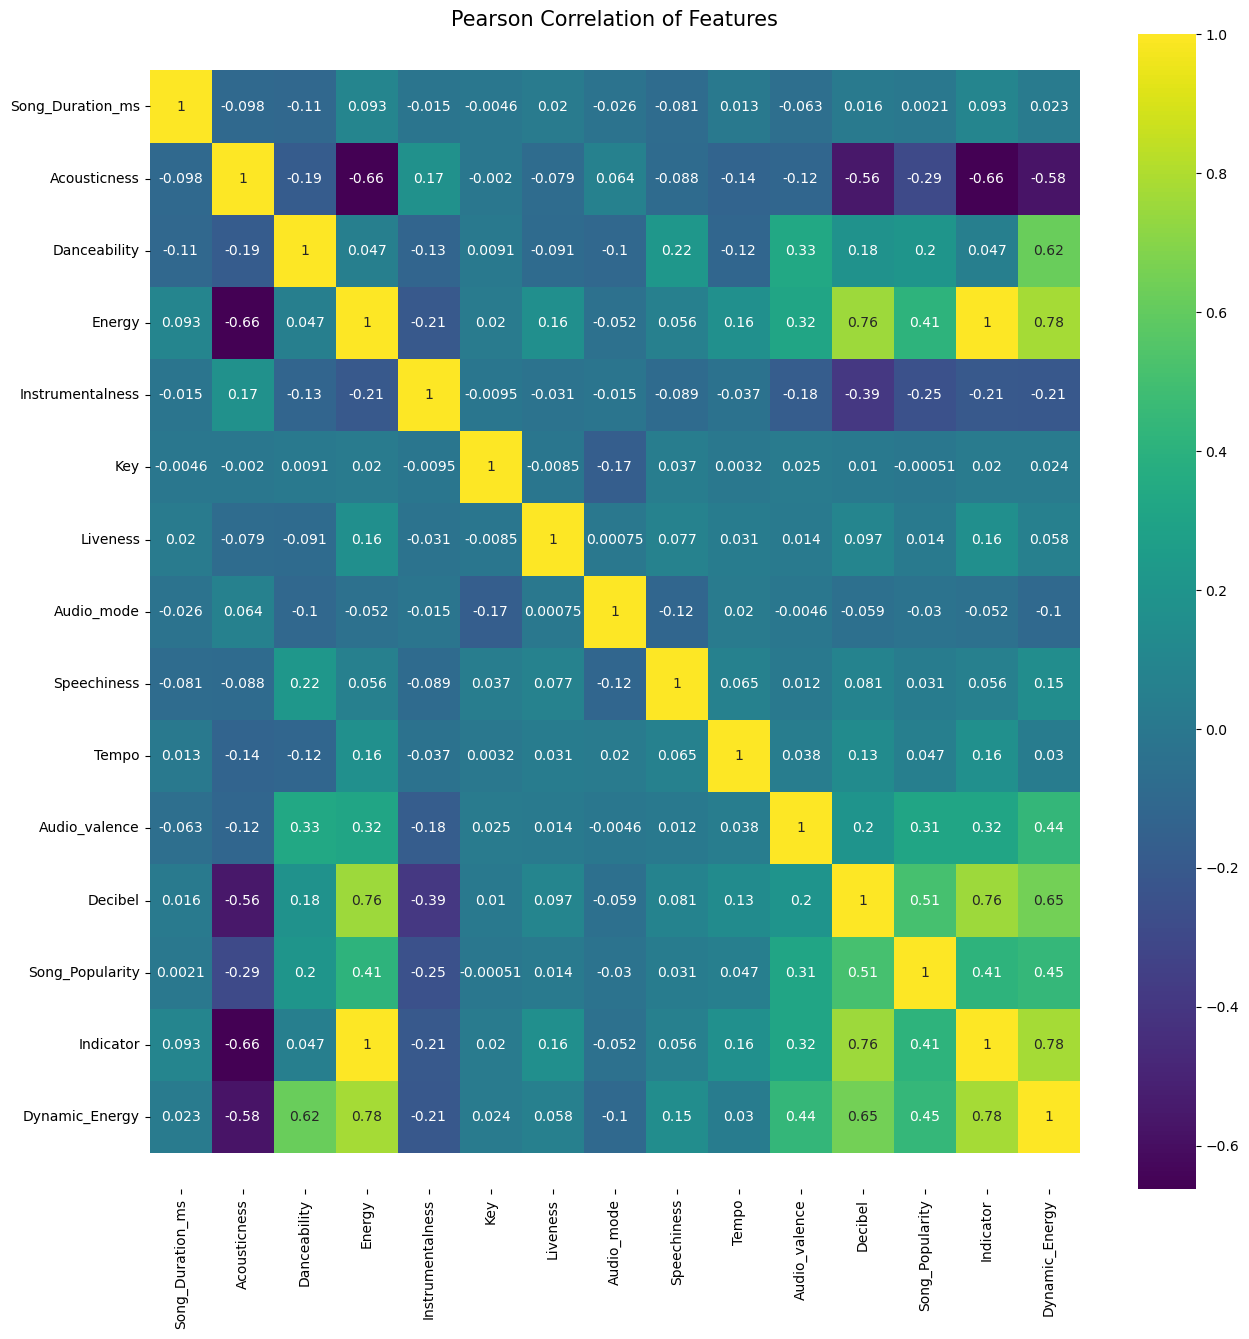

In [18]:
# Heatmap: visualize the correlation between any two features / variables

colormap = plt.cm.viridis
plt.figure(figsize=(15,15))
plt.title('Pearson Correlation of Features', size=15)
ax = sns.heatmap(data[num_cols].corr(), cmap=colormap, annot=True)
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)
plt.show()

In [19]:
data.dtypes

Code                 object
Song_Name            object
Song_Duration_ms      int64
Acousticness        float64
Danceability        float64
Energy              float64
Instrumentalness    float64
Key                   int64
Liveness            float64
Audio_mode            int64
Speechiness         float64
Tempo               float64
Audio_valence       float64
Dynamism             object
Decibel             float64
Loudness             object
Song_Popularity     float64
Indicator           float64
Dynamic_Energy      float64
dtype: object

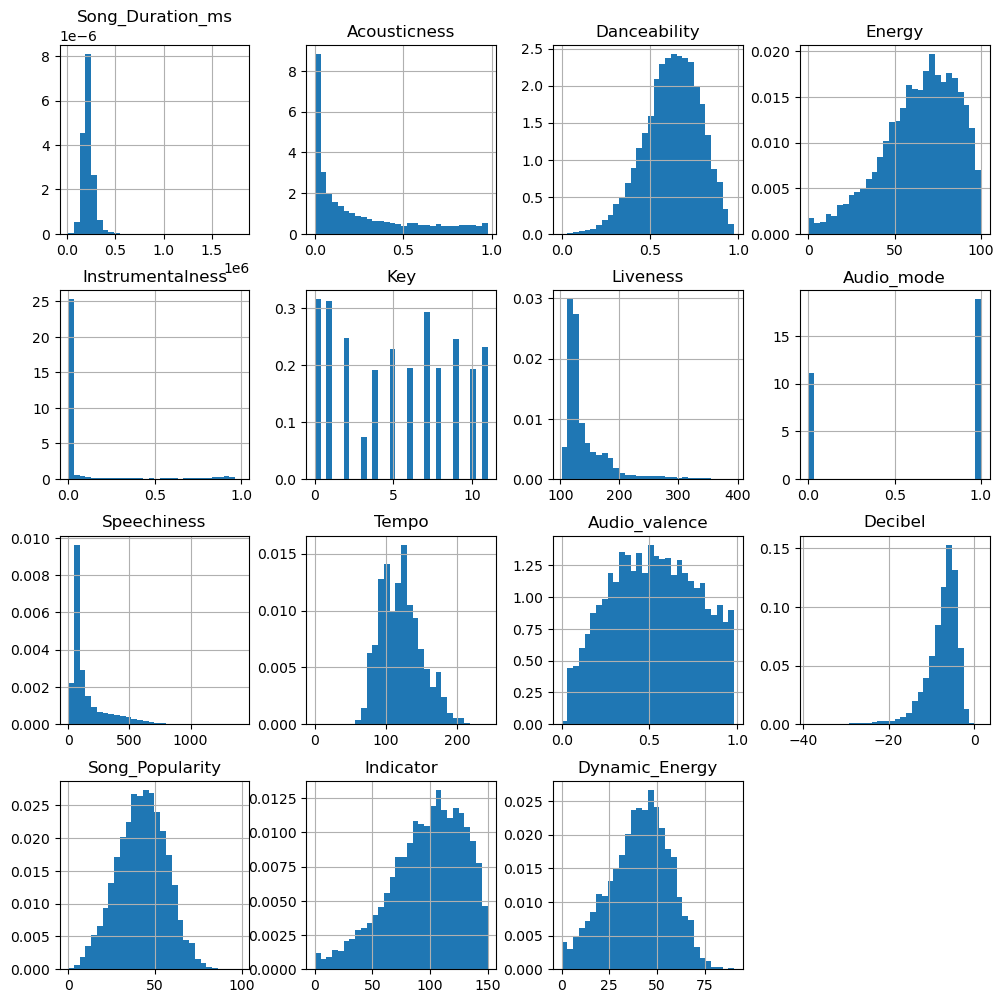

In [20]:
data.hist(bins=30, figsize=(12,12), density=True)
plt.show()

#### Univariate Analysis

##### Categorical Variables Analysis

In [21]:
# Dynamism
Dynamism_label_freq = data['Dynamism'].value_counts() / len(data)
print(Dynamism_label_freq)

Dynamism
Hi        0.201752
High      0.199947
Medium    0.135546
Med       0.134271
Extra     0.086806
Low       0.014547
Lo        0.014441
high      0.006743
m         0.005256
h         0.002655
l         0.001699
Name: count, dtype: float64


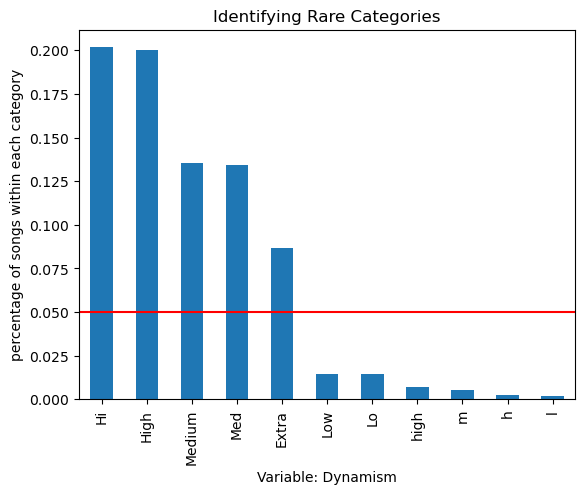

In [22]:
# let's make plot with the category frequencies
fig = Dynamism_label_freq.sort_values(ascending=False).plot.bar()

# add a line to signal 5 % frequency limit
# under which we will consider a category as rare
fig.axhline(y=0.05, color='red')

# add axis labels and title
fig.set_ylabel('percentage of songs within each category')
fig.set_xlabel('Variable: Dynamism')
fig.set_title('Identifying Rare Categories')
plt.show()

In [23]:
# Loudness
Loudness_label_freq = data['Loudness'].value_counts() / len(data)
print(Loudness_label_freq)

Loudness
Blare            0.264136
Roar             0.219432
Clang            0.132519
Boom             0.106026
Rumble           0.075285
Babble           0.065782
Chatter          0.009504
Blast            0.006955
Buzz             0.005787
Rustle           0.004778
Drone            0.003982
Hum              0.002336
Mutter           0.001115
Mumble           0.000743
Whisper          0.000265
Deafening        0.000212
Ear-splitting    0.000106
Murmur           0.000053
Name: count, dtype: float64


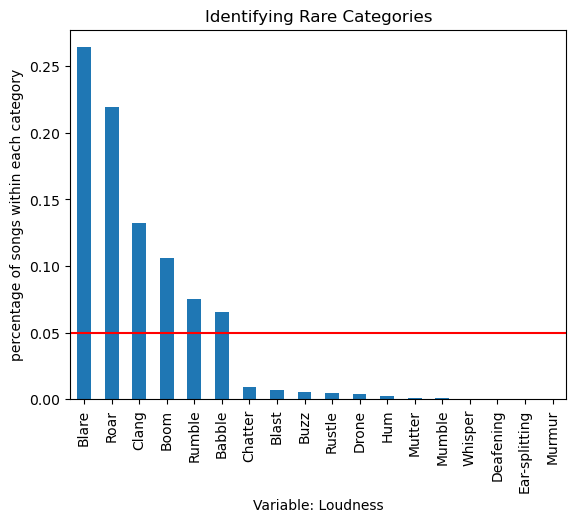

In [24]:
# let's make plot with the category frequencies
fig = Loudness_label_freq.sort_values(ascending=False).plot.bar()

# add a line to signal 5 % frequency limit
# under which we will consider a category as rare
fig.axhline(y=0.05, color='red')

# add axis labels and title
fig.set_ylabel('percentage of songs within each category')
fig.set_xlabel('Variable: Loudness')
fig.set_title('Identifying Rare Categories')
plt.show()

##### Numerical Variables Analysis

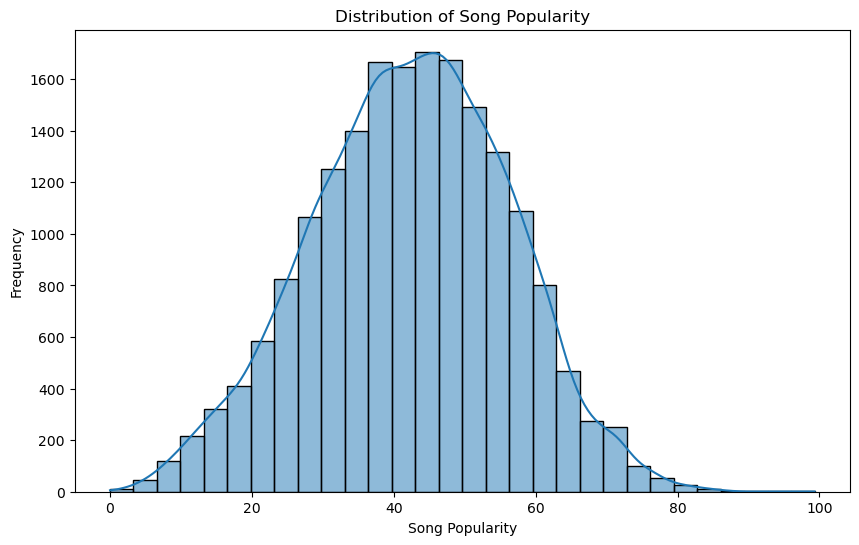

In [25]:
# 1. Distribution of Song Popularity
plt.figure(figsize=(10, 6))
sns.histplot(data['Song_Popularity'], bins=30, kde=True)
plt.title('Distribution of Song Popularity')
plt.xlabel('Song Popularity')
plt.ylabel('Frequency')
plt.show()

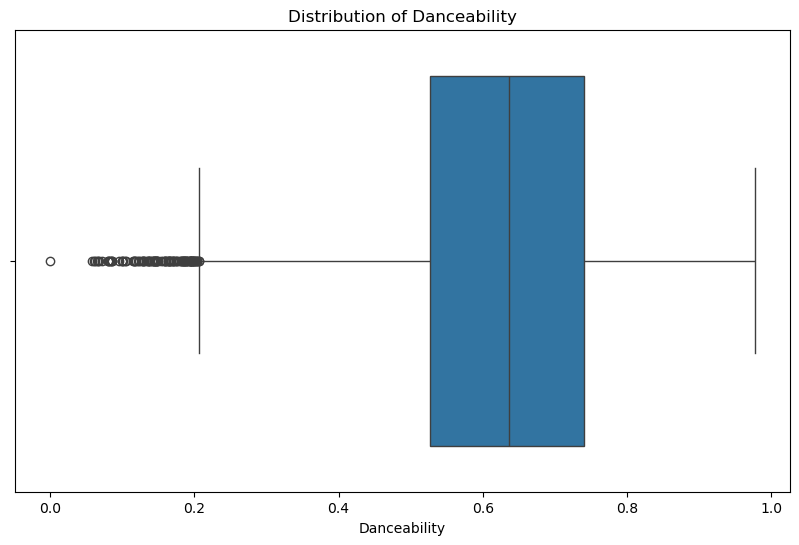

In [26]:
# 2. Danceability
plt.figure(figsize=(10, 6))
sns.boxplot(x=data['Danceability'])
plt.title('Distribution of Danceability')
plt.xlabel('Danceability')
plt.show()

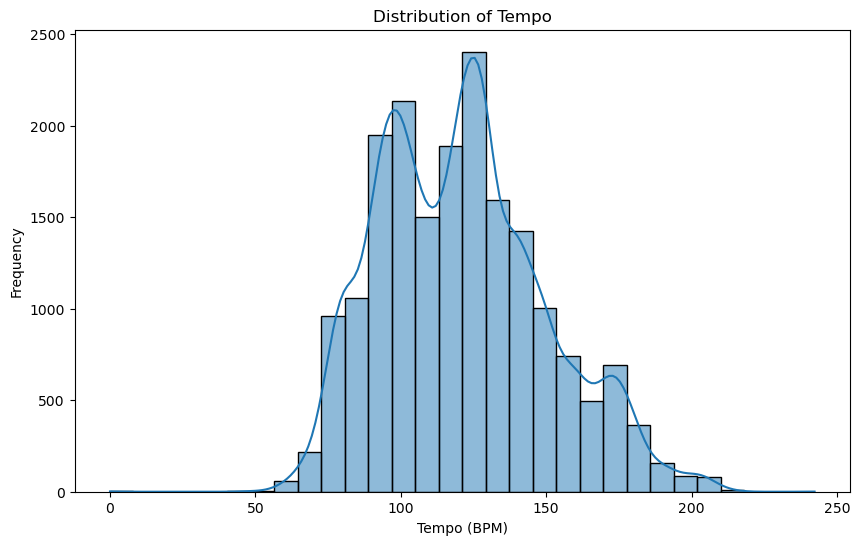

In [27]:
# 3. Tempo
plt.figure(figsize=(10, 6))
sns.histplot(data['Tempo'], bins=30, kde=True)
plt.title('Distribution of Tempo')
plt.xlabel('Tempo (BPM)')
plt.ylabel('Frequency')
plt.show()

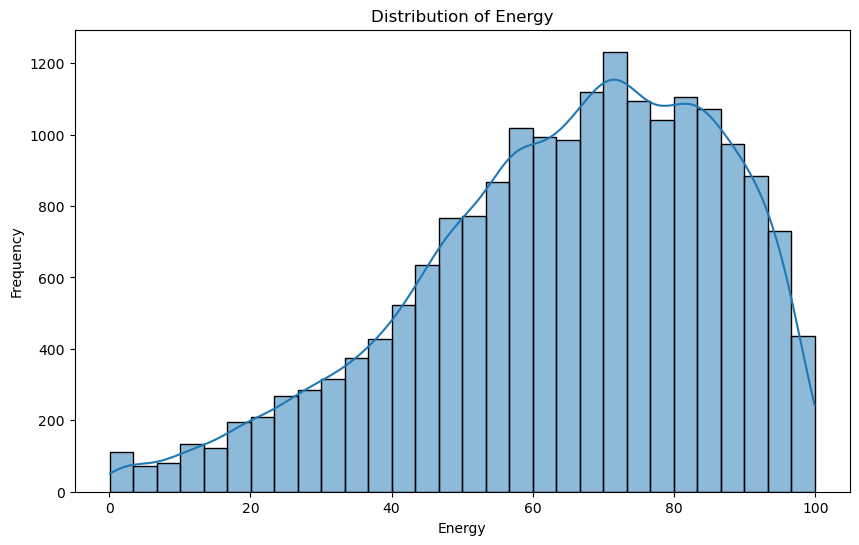

In [28]:
# 4. Energy
plt.figure(figsize=(10, 6))
sns.histplot(data['Energy'], bins=30, kde=True)
plt.title('Distribution of Energy')
plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.show()

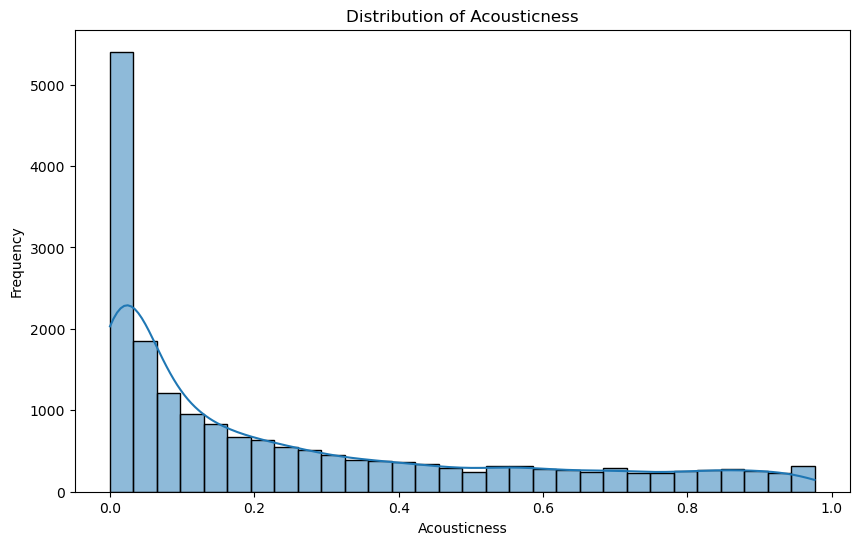

In [29]:
# 4. Acousticness
plt.figure(figsize=(10, 6))
sns.histplot(data['Acousticness'], bins=30, kde=True)
plt.title('Distribution of Acousticness')
plt.xlabel('Acousticness')
plt.ylabel('Frequency')
plt.show()

##### Bivariate Analysis

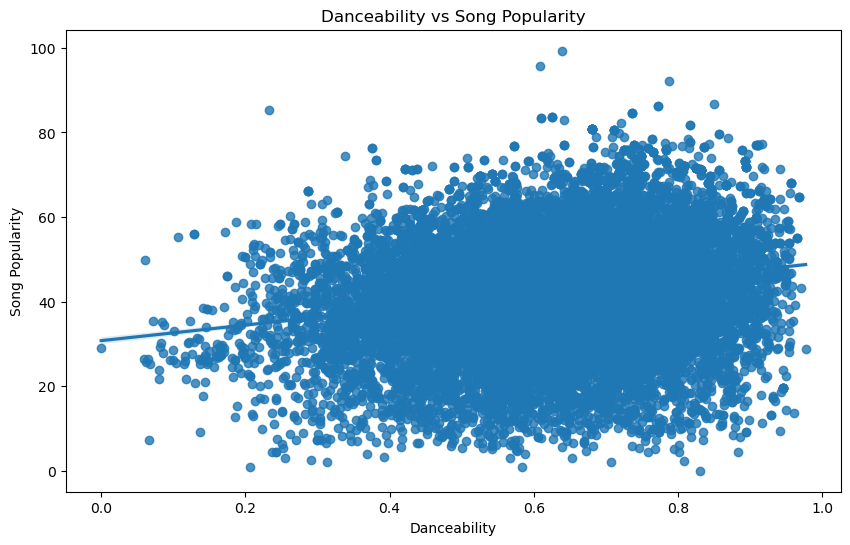

In [30]:
# 1. Danceability vs. Song Popularity
# Create a scatter plot with a regression line
plt.figure(figsize=(10, 6))
sns.regplot(x='Danceability', y='Song_Popularity', data=data)

plt.xlabel('Danceability')
plt.ylabel('Song Popularity')
plt.title('Danceability vs Song Popularity')
plt.show()

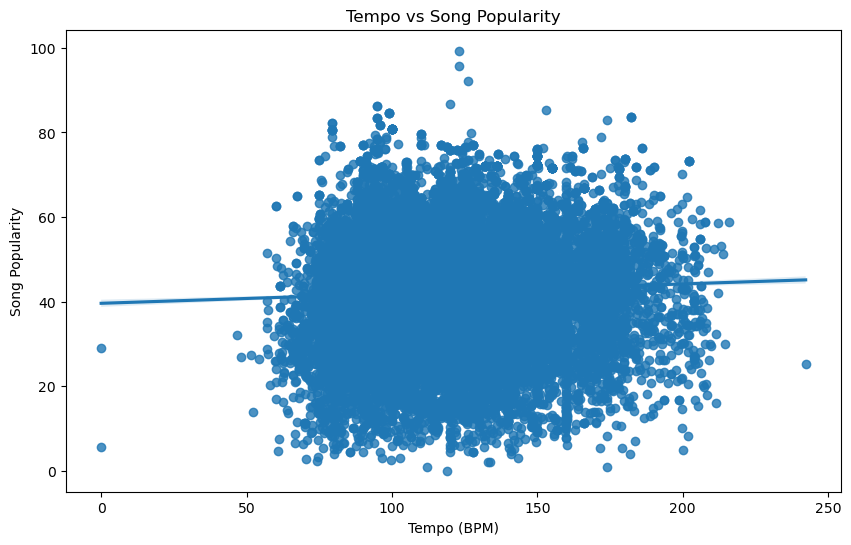

In [31]:
# 2. Tempo vs. Song Popularity
# Create a scatter plot with a regression line
plt.figure(figsize=(10, 6))
sns.regplot(x='Tempo', y='Song_Popularity', data=data)

plt.xlabel('Tempo (BPM)')
plt.ylabel('Song Popularity')
plt.title('Tempo vs Song Popularity')
plt.show()

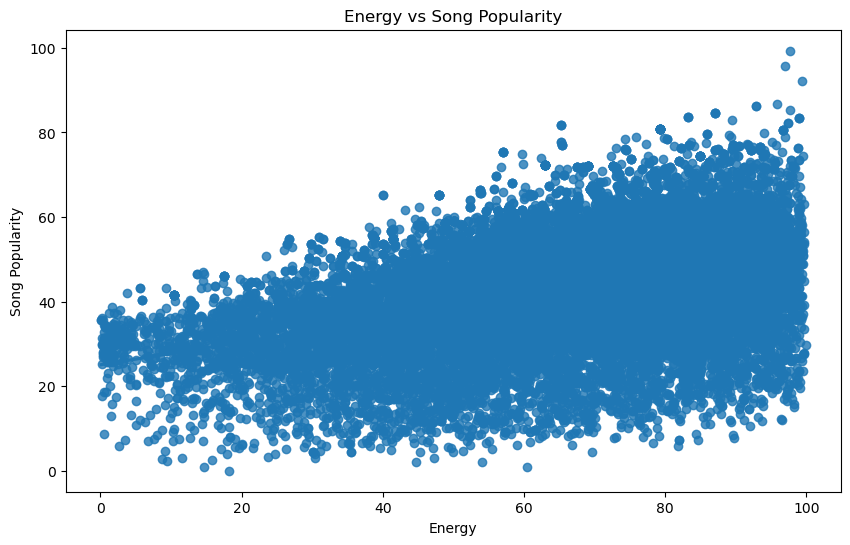

In [32]:
# 3. Energy vs. Song Popularity
# Create a scatter plot with a regression line
plt.figure(figsize=(10, 6))
sns.regplot(x='Energy', y='Song_Popularity', data=data)

plt.xlabel('Energy')
plt.ylabel('Song Popularity')
plt.title('Energy vs Song Popularity')
plt.show()

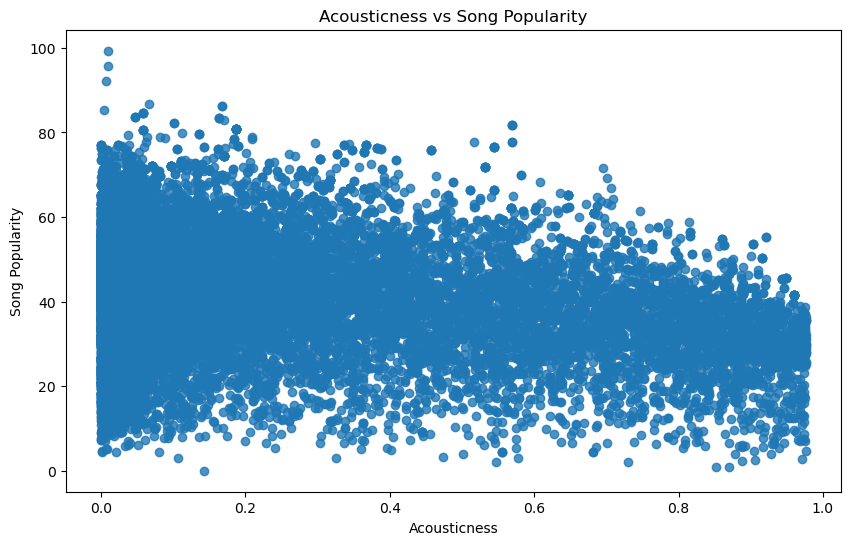

In [33]:
# 4. Acousticness vs. Song Popularity
# Create a scatter plot with a regression line
plt.figure(figsize=(10, 6))
sns.regplot(x='Acousticness', y='Song_Popularity', data=data)

plt.xlabel('Acousticness')
plt.ylabel('Song Popularity')
plt.title('Acousticness vs Song Popularity')
plt.show()

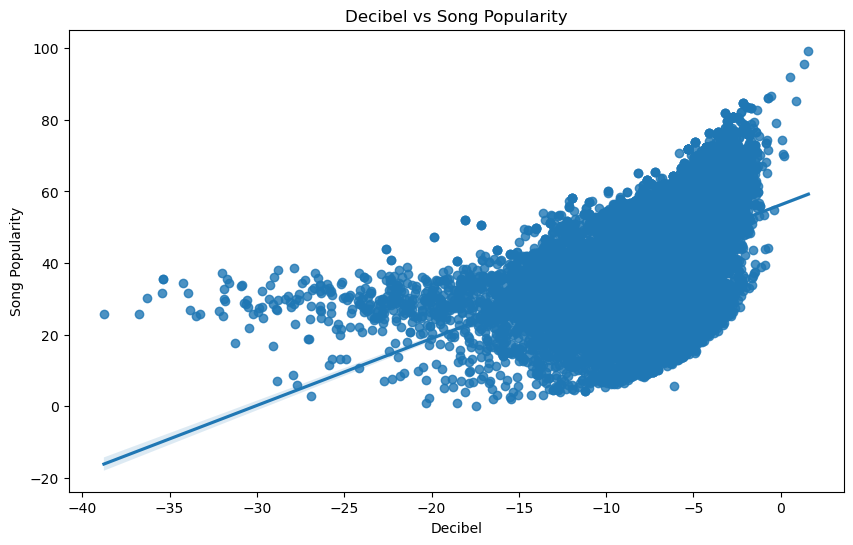

In [34]:
# 5. Decibel vs. Song Popularity
# Create a scatter plot with a regression line
plt.figure(figsize=(10, 6))
sns.regplot(x='Decibel', y='Song_Popularity', data=data)

plt.xlabel('Decibel')
plt.ylabel('Song Popularity')
plt.title('Decibel vs Song Popularity')
plt.show()

In [35]:
# Define popular and unpopular songs based on median popularity
median_popularity = data['Song_Popularity'].median()
popular_songs = data[data['Song_Popularity'] > median_popularity]
unpopular_songs = data[data['Song_Popularity'] <= median_popularity]

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\3969501750.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(popular_songs[char], label='Popular Songs', shade=True)
C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\3969501750.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(unpopular_songs[char], label='Unpopular Songs', shade=True)


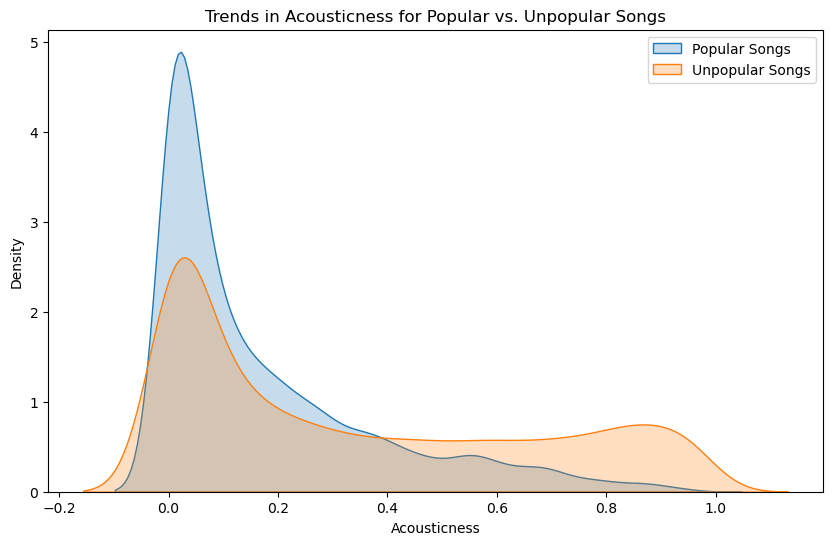

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\3969501750.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(popular_songs[char], label='Popular Songs', shade=True)
C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\3969501750.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(unpopular_songs[char], label='Unpopular Songs', shade=True)


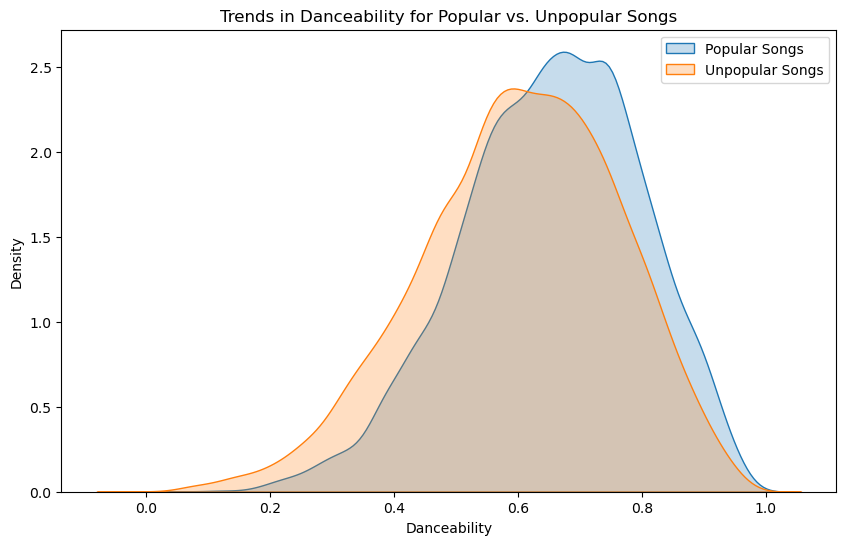

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\3969501750.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(popular_songs[char], label='Popular Songs', shade=True)
C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\3969501750.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(unpopular_songs[char], label='Unpopular Songs', shade=True)


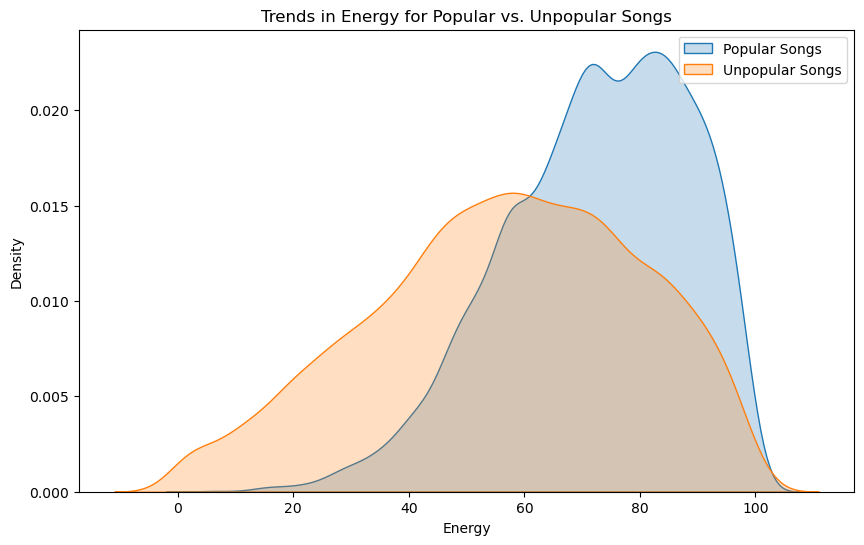

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\3969501750.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(popular_songs[char], label='Popular Songs', shade=True)
C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\3969501750.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(unpopular_songs[char], label='Unpopular Songs', shade=True)


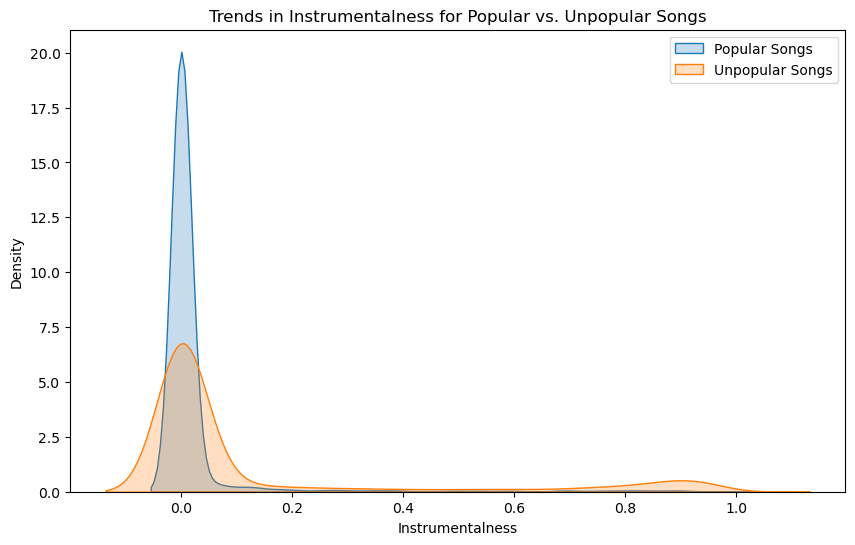

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\3969501750.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(popular_songs[char], label='Popular Songs', shade=True)
C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\3969501750.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(unpopular_songs[char], label='Unpopular Songs', shade=True)


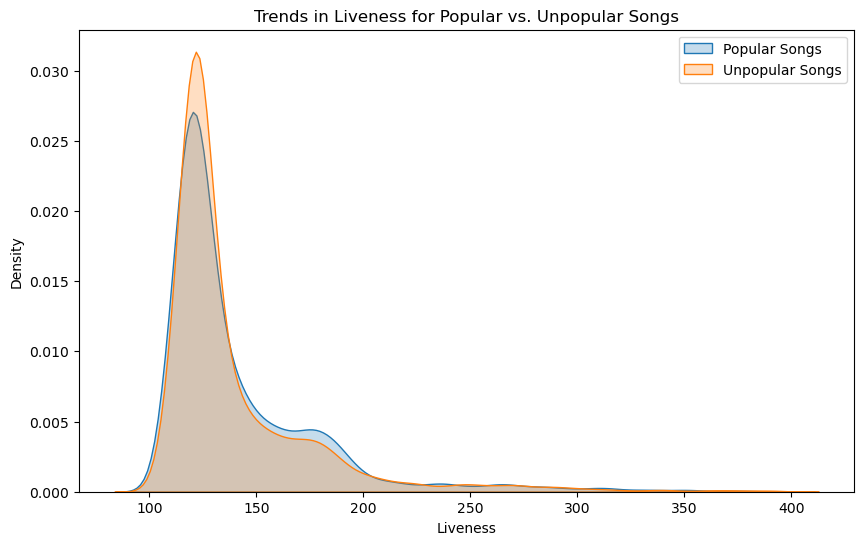

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\3969501750.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(popular_songs[char], label='Popular Songs', shade=True)
C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\3969501750.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(unpopular_songs[char], label='Unpopular Songs', shade=True)


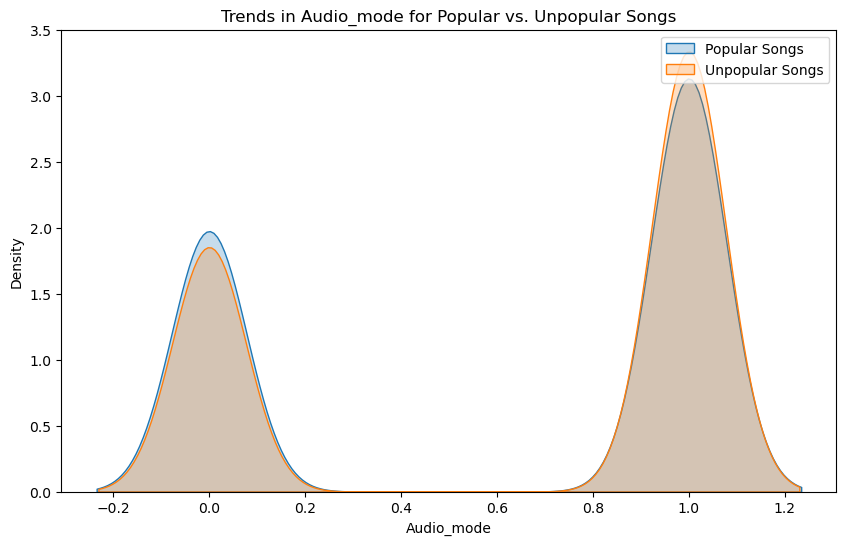

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\3969501750.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(popular_songs[char], label='Popular Songs', shade=True)
C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\3969501750.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(unpopular_songs[char], label='Unpopular Songs', shade=True)


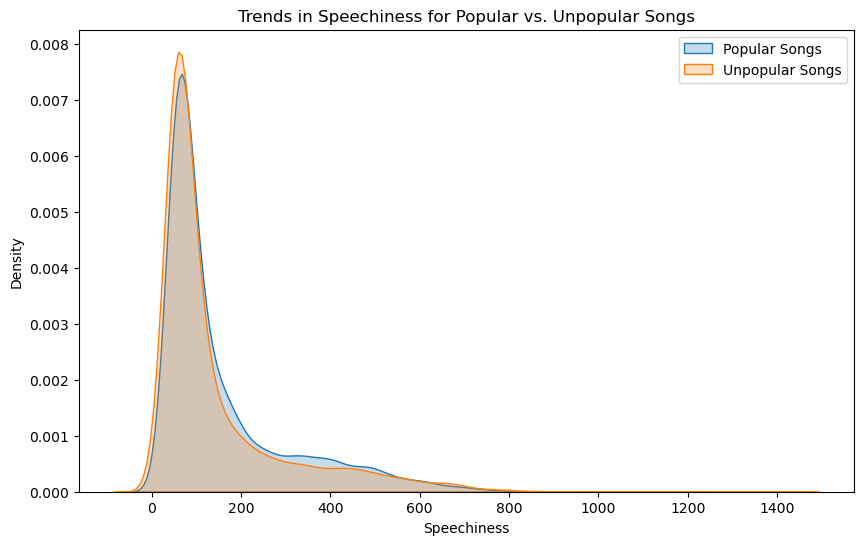

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\3969501750.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(popular_songs[char], label='Popular Songs', shade=True)
C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\3969501750.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(unpopular_songs[char], label='Unpopular Songs', shade=True)


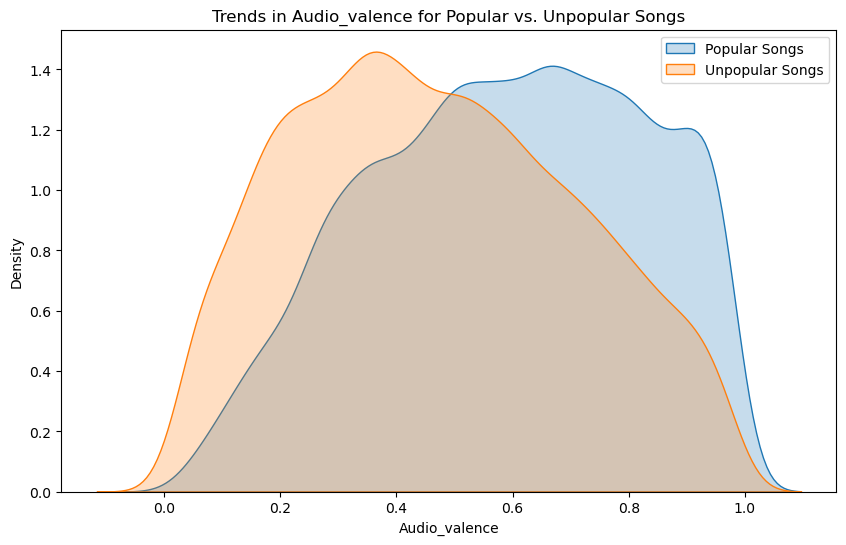

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\3969501750.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(popular_songs[char], label='Popular Songs', shade=True)
C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\3969501750.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(unpopular_songs[char], label='Unpopular Songs', shade=True)


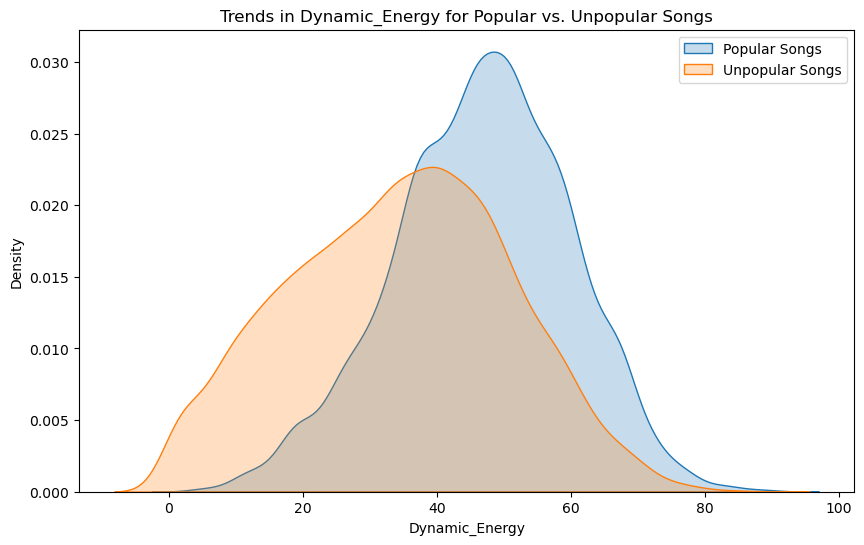

In [231]:
# Trends in Song Characteristics
characteristics = ['Acousticness', 'Danceability', 'Energy', 'Instrumentalness', 'Liveness', 'Audio_mode', 'Speechiness', 'Audio_valence','Dynamic_Energy']
for char in characteristics:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(popular_songs[char], label='Popular Songs', shade=True)
    sns.kdeplot(unpopular_songs[char], label='Unpopular Songs', shade=True)
    plt.title(f'Trends in {char} for Popular vs. Unpopular Songs')
    plt.xlabel(char)
    plt.ylabel('Density')
    plt.legend()
    plt.show()

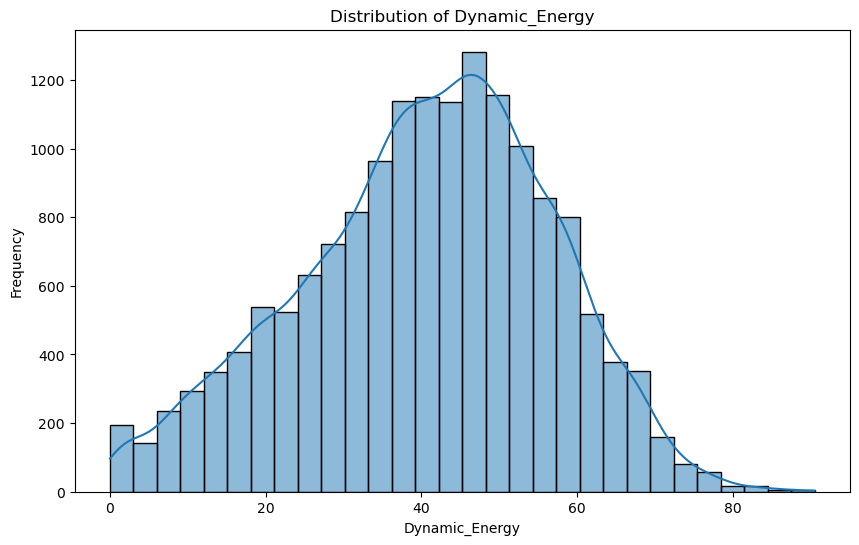

In [37]:
# Univariate Dynamic Energy Distribution
# 5. Dynamic_Energy
plt.figure(figsize=(10, 6))
sns.histplot(data['Dynamic_Energy'], bins=30, kde=True)
plt.title('Distribution of Dynamic_Energy')
plt.xlabel('Dynamic_Energy')
plt.ylabel('Frequency')
plt.show()

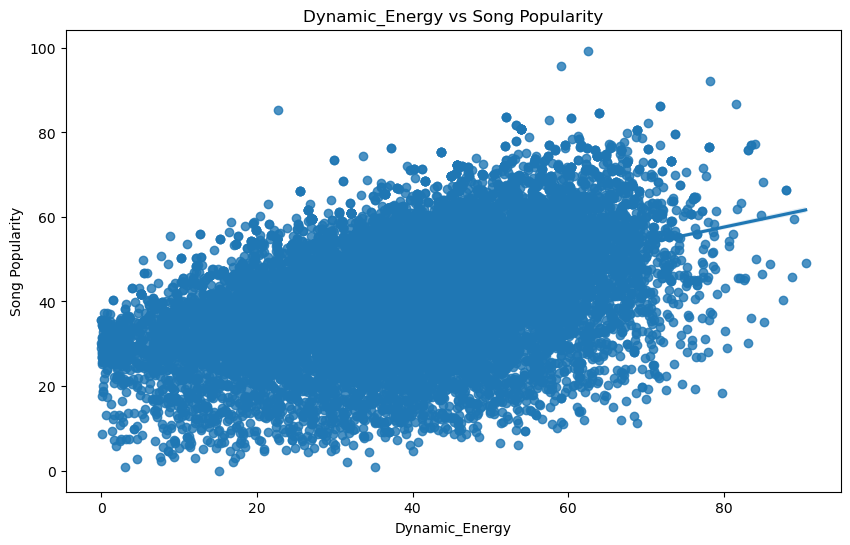

In [38]:
#Bivariate
# 6. Dynamic_Energy vs. Song Popularity
# Create a scatter plot with a regression line
plt.figure(figsize=(10, 6))
sns.regplot(x='Dynamic_Energy', y='Song_Popularity', data=data)

plt.xlabel('Dynamic_Energy')
plt.ylabel('Song Popularity')
plt.title('Dynamic_Energy vs Song Popularity')
plt.show()

### Step 3: Data Preprocessing

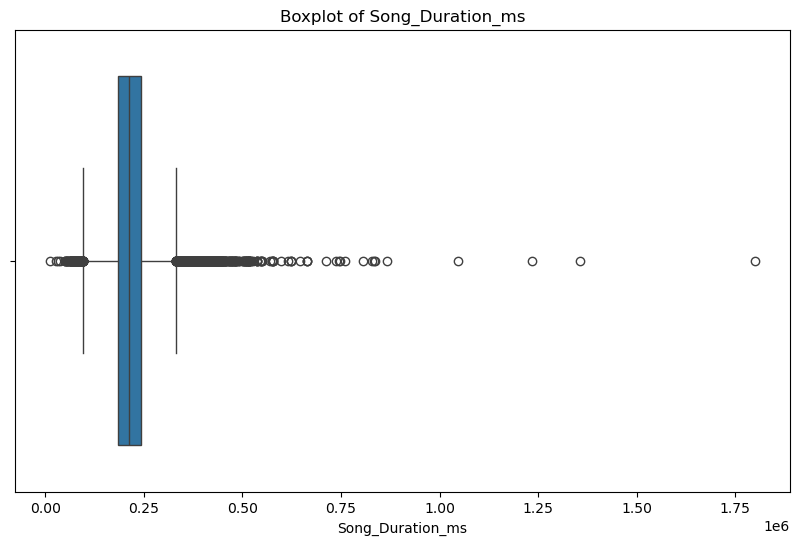

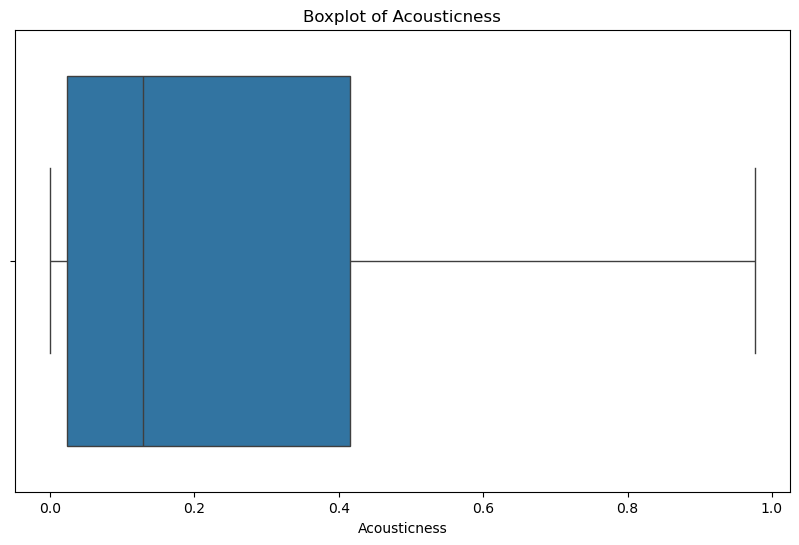

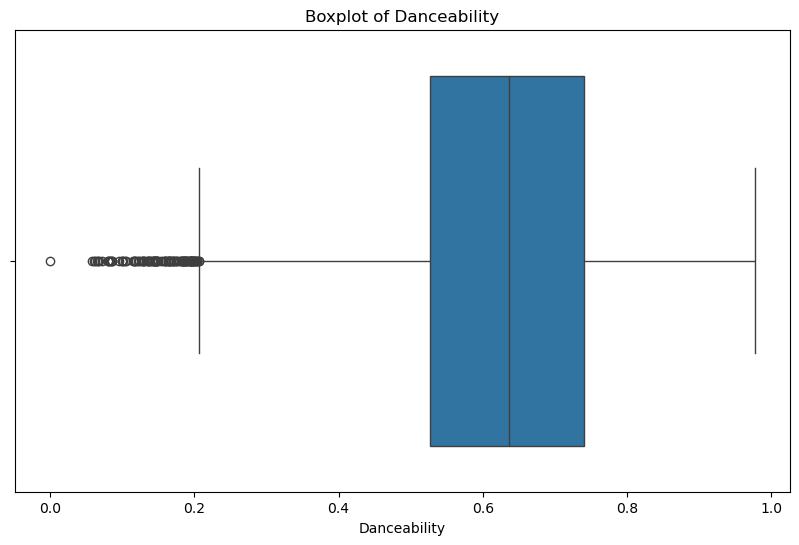

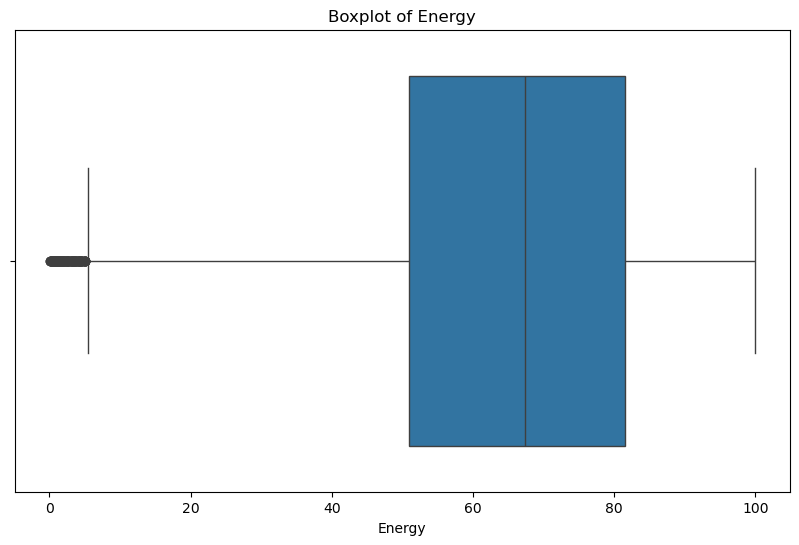

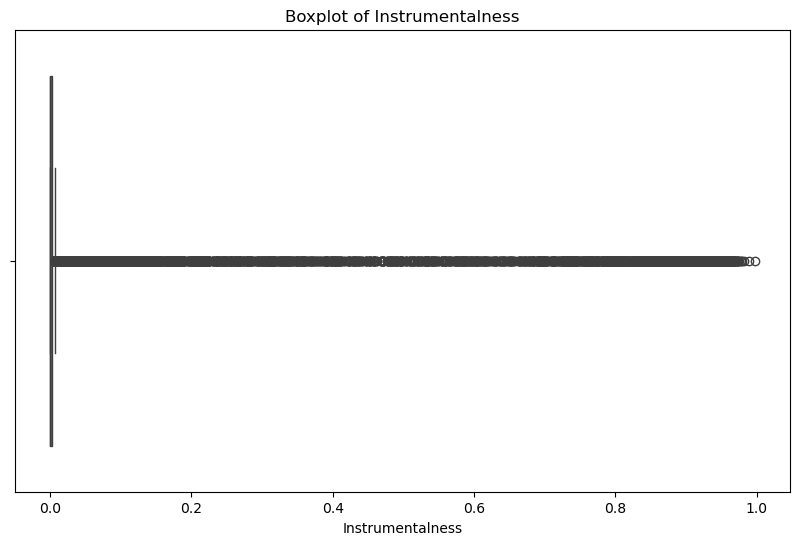

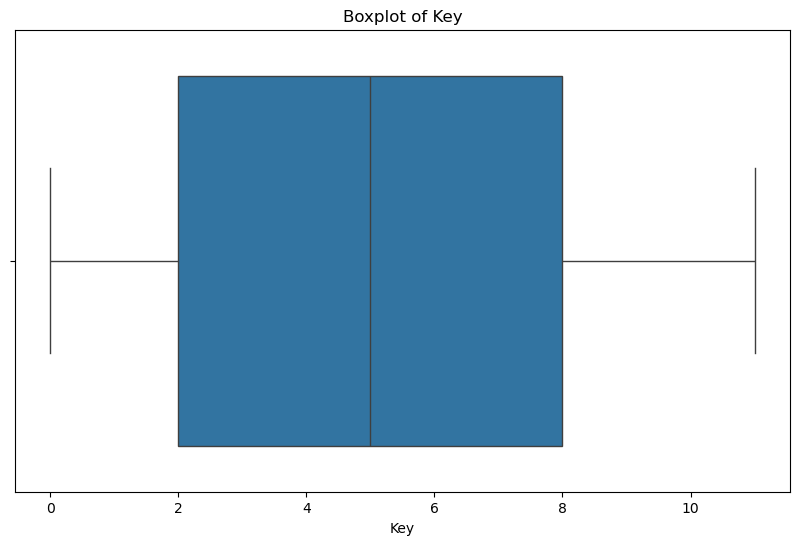

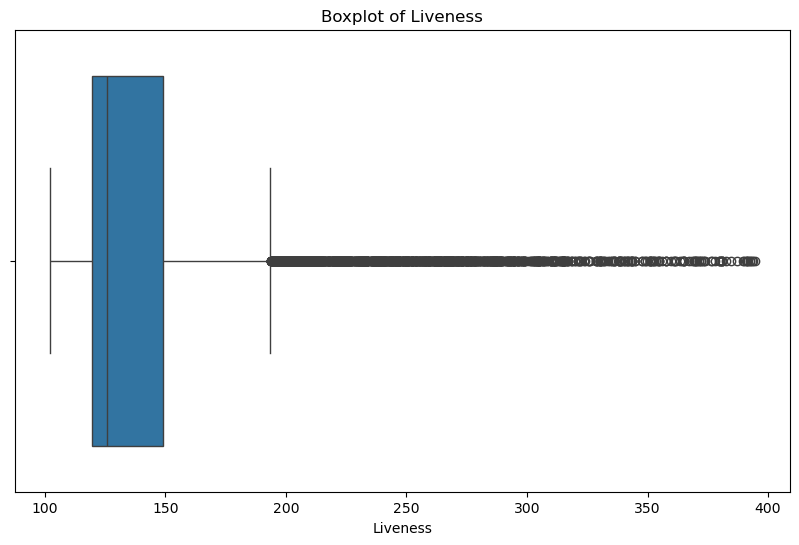

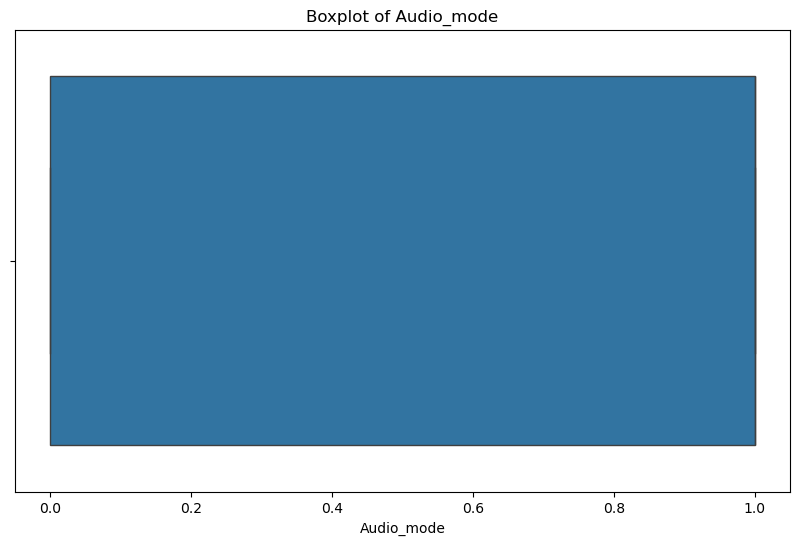

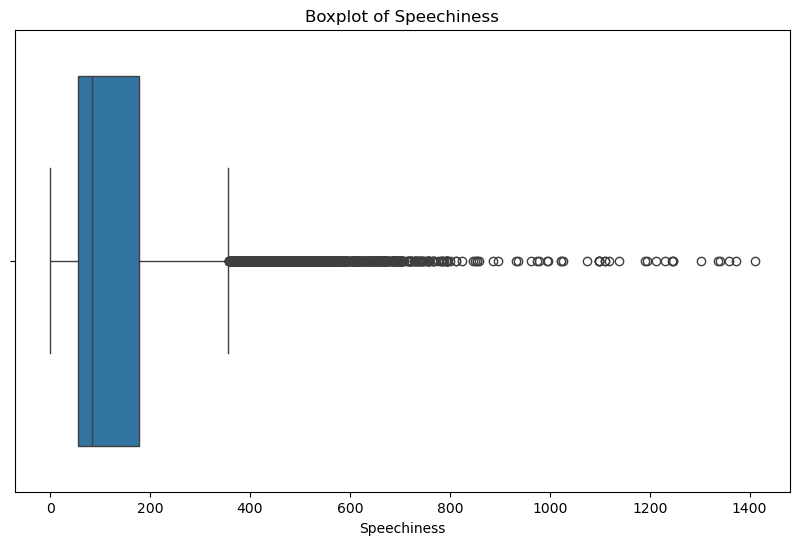

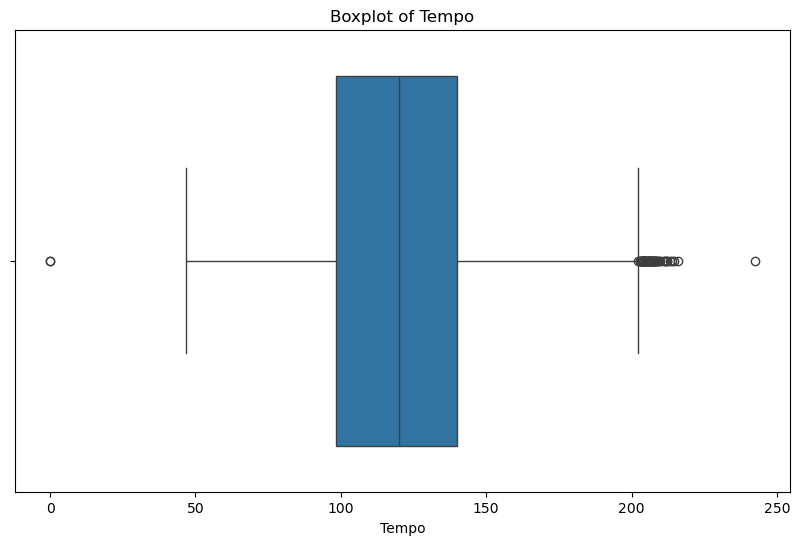

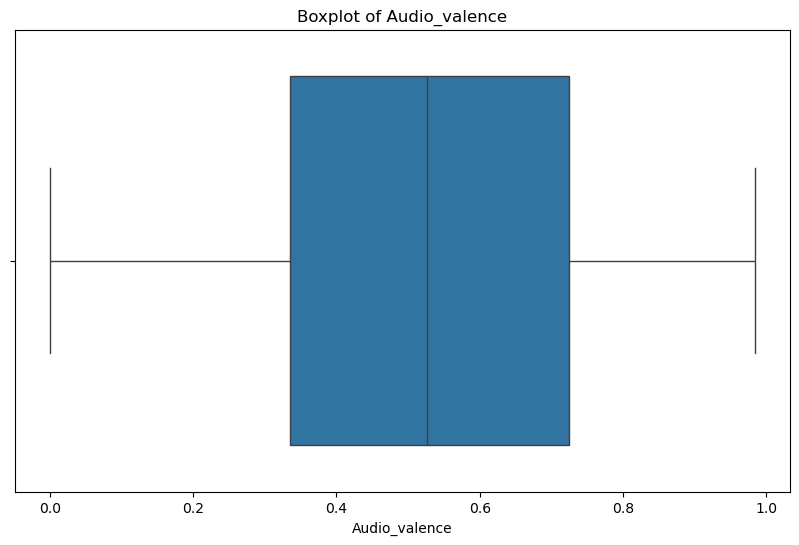

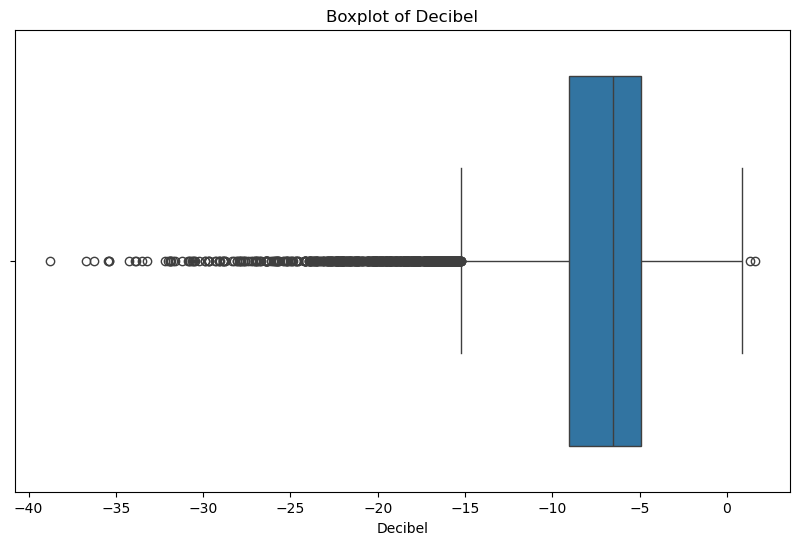

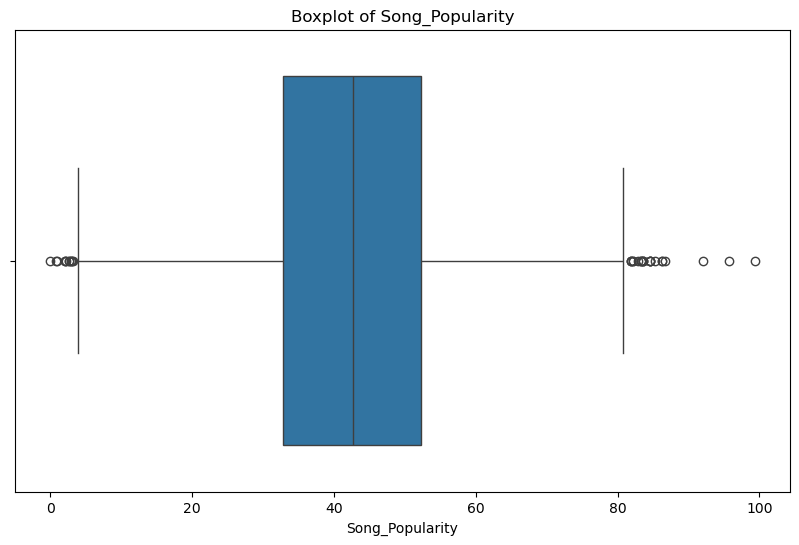

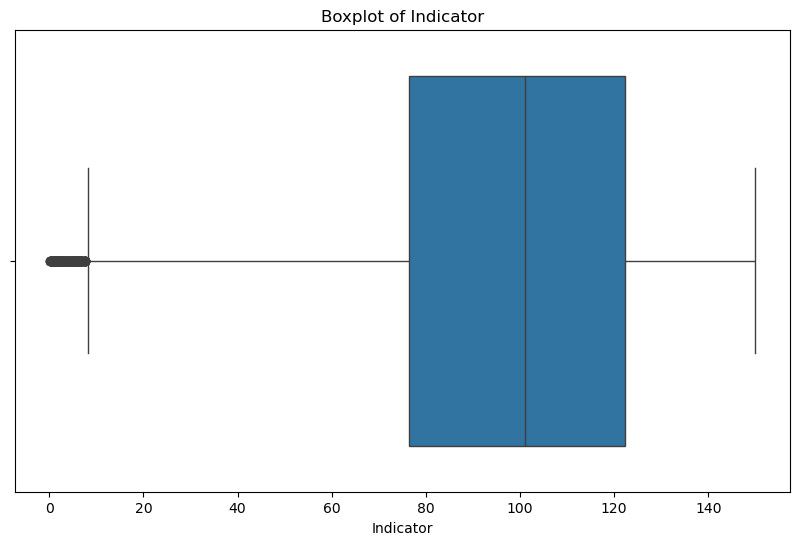

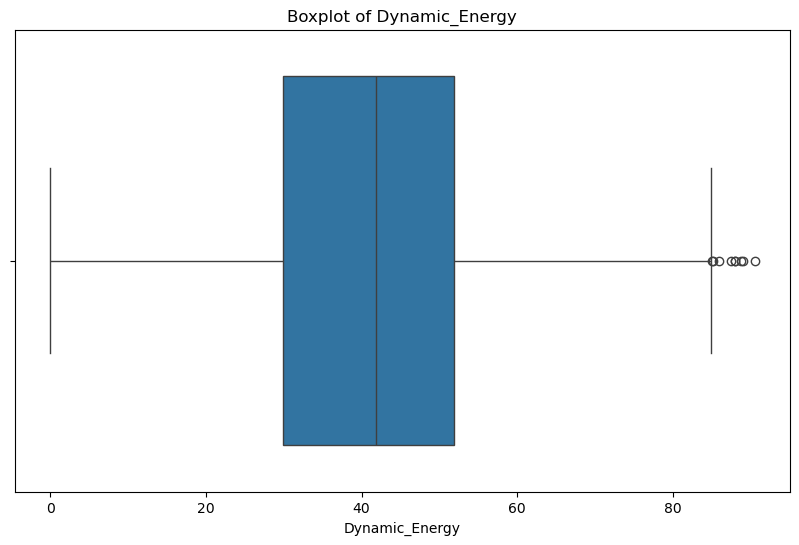

In [39]:
# Detecting outliers using boxplots
for column in data[num_cols]:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=data[column])
    plt.title(f'Boxplot of {column}')
    plt.show()

In [40]:
# Highlighting outliers
# now let's find in a dataframe those outliers:

# the function finds the upper and lower boundaries
# using the IQR proximity rule

def find_boundaries(df, variable):

    # distance passed as an argument, gives us the option to
    # estimate 1.5 times or 3 times the IQR to calculate
    # the boundaries.

    #distance between the 75th quartile and 25th quartile
    IQR = df[variable].quantile(0.75) - df[variable].quantile(0.25)

    lower_boundary = df[variable].quantile(0.25) - (IQR * 1.5)
    upper_boundary = df[variable].quantile(0.75) + (IQR * 1.5)

    return upper_boundary, lower_boundary

In [41]:
# we find the boudaries for the variable Song_Duration_ms

upper_boundary, lower_boundary = find_boundaries(data, 'Song_Duration_ms')
upper_boundary, lower_boundary

(330600.75, 96582.75)

In [42]:
# let's flag the outliers in the data set
outliers_Song_Duration_ms = np.where(data['Song_Duration_ms'] > upper_boundary, True,
                    np.where(data['Song_Duration_ms'] < lower_boundary, True, False))

In [43]:
# how many outliers did we find?
outliers_Song_Duration_ms.sum()

824

In [44]:
# we find the boudaries for the variable Danceability

upper_boundary, lower_boundary = find_boundaries(data, 'Danceability')
upper_boundary, lower_boundary

(1.0612799999999998, 0.20592000000000016)

In [45]:
# let's flag the outliers in the data set
outliers_Danceability = np.where(data['Danceability'] > upper_boundary, True,
                    np.where(data['Danceability'] < lower_boundary, True, False))

In [46]:
# how many outliers did we find?
outliers_Danceability.sum()

109

In [47]:
# we find the boudaries for the variable Energy

upper_boundary, lower_boundary = find_boundaries(data, 'Energy')
upper_boundary, lower_boundary

(127.25, 5.25)

In [48]:
# let's flag the outliers in the data set
outliers_Energy = np.where(data['Energy'] > upper_boundary, True,
                    np.where(data['Energy'] < lower_boundary, True, False))

In [49]:
# how many outliers did we find?
outliers_Energy.sum()

151

In [50]:
# we find the boudaries for the variable Instrumentalness

upper_boundary, lower_boundary = find_boundaries(data, 'Instrumentalness')
upper_boundary, lower_boundary

(0.006425, -0.003855)

In [51]:
# let's flag the outliers in the data set
outliers_Instrumentalness = np.where(data['Instrumentalness'] > upper_boundary, True,
                    np.where(data['Instrumentalness'] < lower_boundary, True, False))

In [52]:
# how many outliers did we find?
outliers_Instrumentalness.sum()

4070

In [53]:
# we find the boudaries for the variable Liveness

upper_boundary, lower_boundary = find_boundaries(data, 'Liveness')
upper_boundary, lower_boundary

(193.54568850000004, 74.98145249999997)

In [54]:
# let's flag the outliers in the data set
outliers_Liveness = np.where(data['Liveness'] > upper_boundary, True,
                    np.where(data['Liveness'] < lower_boundary, True, False))

In [55]:
# how many outliers did we find?
outliers_Liveness.sum()

1381

In [56]:
# we find the boudaries for the variable Speechiness

upper_boundary, lower_boundary = find_boundaries(data, 'Speechiness')
upper_boundary, lower_boundary

(357.45, -123.74999999999999)

In [57]:
# let's flag the outliers in the data set
outliers_Speechiness = np.where(data['Speechiness'] > upper_boundary, True,
                    np.where(data['Speechiness'] < lower_boundary, True, False))

In [58]:
# how many outliers did we find?
outliers_Speechiness.sum()

1534

In [59]:
# we find the boudaries for the variable Decibel

upper_boundary, lower_boundary = find_boundaries(data, 'Decibel')
upper_boundary, lower_boundary

(1.2960000000000003, -15.248000000000001)

In [60]:
# let's flag the outliers in the data set
outliers_Decibel = np.where(data['Decibel'] > upper_boundary, True,
                    np.where(data['Decibel'] < lower_boundary, True, False))

In [61]:
# how many outliers did we find?
outliers_Decibel.sum()

705

In [62]:
# we find the boudaries for the variable Song_Popularity

upper_boundary, lower_boundary = find_boundaries(data, 'Song_Popularity')
upper_boundary, lower_boundary

(81.53999999999999, 3.539999999999999)

In [63]:
# let's flag the outliers in the data set
outliers_Song_Popularity = np.where(data['Song_Popularity'] > upper_boundary, True,
                    np.where(data['Song_Popularity'] < lower_boundary, True, False))

In [64]:
# how many outliers did we find?
outliers_Song_Popularity.sum()

35

In [65]:
# we find the boudaries for the variable Indicator

upper_boundary, lower_boundary = find_boundaries(data, 'Indicator')
upper_boundary, lower_boundary

(190.875, 7.875)

In [66]:
# let's flag the outliers in the data set
outliers_Indicator = np.where(data['Indicator'] > upper_boundary, True,
                    np.where(data['Indicator'] < lower_boundary, True, False))

In [67]:
# how many outliers did we find?
outliers_Indicator.sum()

151

In [68]:
# we find the boudaries for the variable Tempo

upper_boundary, lower_boundary = find_boundaries(data, 'Tempo')
upper_boundary, lower_boundary

(202.27550000000002, 36.02349999999997)

In [69]:
# let's flag the outliers in the data set
outliers_Tempo = np.where(data['Tempo'] > upper_boundary, True,
                    np.where(data['Tempo'] < lower_boundary, True, False))

In [70]:
# how many outliers did we find?
outliers_Tempo.sum()

81

In [71]:
# we find the boudaries for the variable Dynamic_Energy

upper_boundary, lower_boundary = find_boundaries(data, 'Dynamic_Energy')
upper_boundary, lower_boundary

(84.91569075000001, -3.0745192500000087)

In [74]:
# let's flag the outliers in the data set
outliers_Dynamic_Energy = np.where(data['Dynamic_Energy'] > upper_boundary, True,
                    np.where(data['Dynamic_Energy'] < lower_boundary, True, False))

In [75]:
# how many outliers did we find?
outliers_Dynamic_Energy.sum()

9

In [76]:
# Summary display of outliers
print(f"Song_Duration_ms: {outliers_Song_Duration_ms.sum()}\n")
print(f"Danceability: {outliers_Danceability.sum()}\n")
print(f"Energy: {outliers_Energy.sum()}\n")
print(f"Instrumentalness: {outliers_Instrumentalness.sum()}\n")
print(f"Liveness: {outliers_Liveness.sum()}\n")
print(f"Speechiness: {outliers_Speechiness.sum()}\n")
print(f"Decibel: {outliers_Decibel.sum()}\n")
print(f"Song_Popularity: {outliers_Song_Popularity.sum()}\n")
print(f"Indicator: {outliers_Indicator.sum()}\n")
print(f"Tempo: {outliers_Tempo.sum()}\n")
print(f"Dynamic_Energy: {outliers_Dynamic_Energy.sum()}\n")
print('It is observed that the rest of the numerical variables have no outliers.')

Song_Duration_ms: 824

Danceability: 109

Energy: 151

Instrumentalness: 4070

Liveness: 1381

Speechiness: 1534

Decibel: 705

Song_Popularity: 35

Indicator: 151

Tempo: 9

Dynamic_Energy: 9

It is observed that the rest of the numerical variables have no outliers.


In [77]:
# plot histogram, Q-Q plots, and boxplot to have a look at the variable distribution

def diagnostic_plots(df, variable):
    # function takes a dataframe (df) and
    # the variable of interest as arguments

    # define figure size
    plt.figure(figsize=(16, 4))

    # histogram
    plt.subplot(1, 3, 1)
    sns.distplot(df[variable], bins=30)
    plt.title('Histogram')

    # Q-Q plot
    plt.subplot(1, 3, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.ylabel('quantiles')

    # boxplot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[variable])
    plt.title('Boxplot')

    plt.show()

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


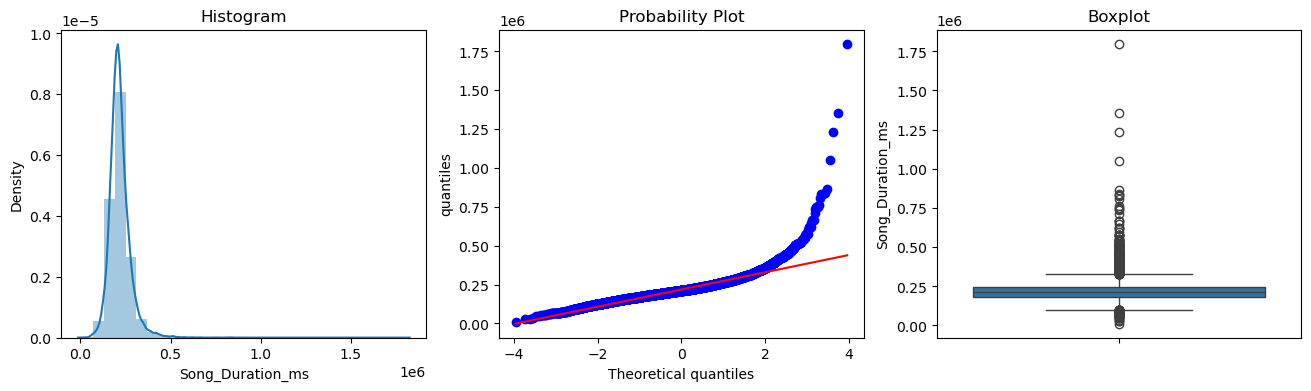

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


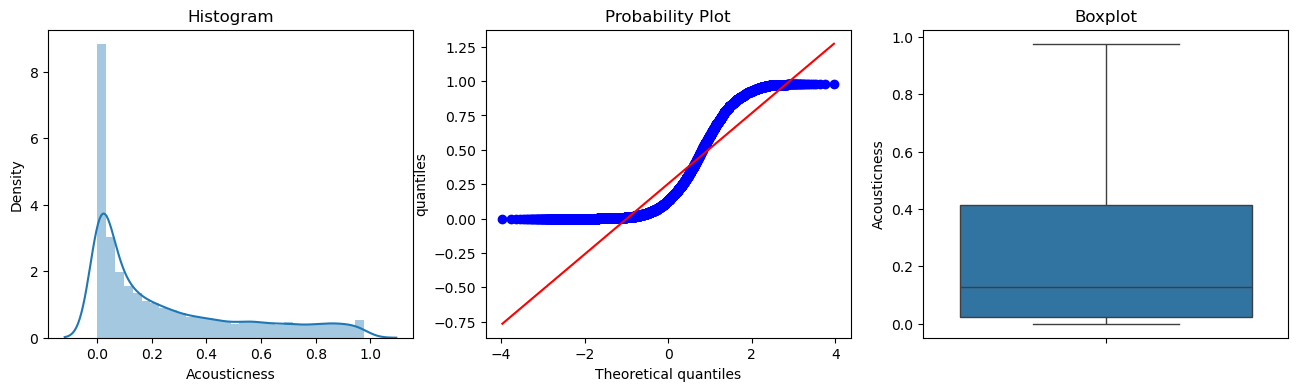

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


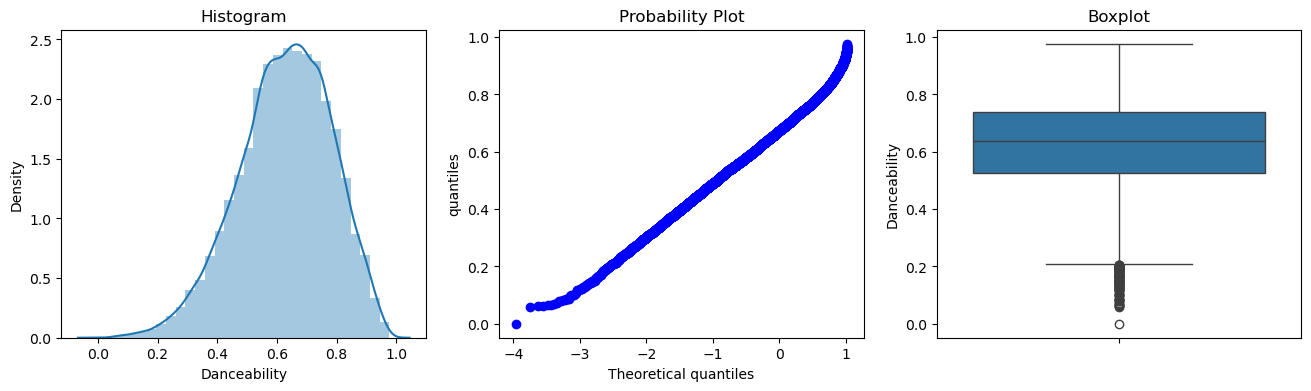

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


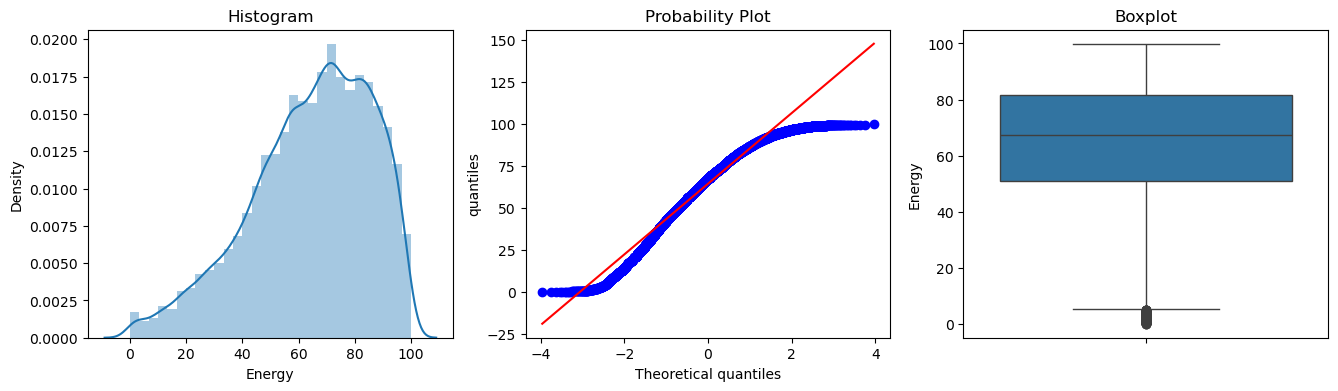

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


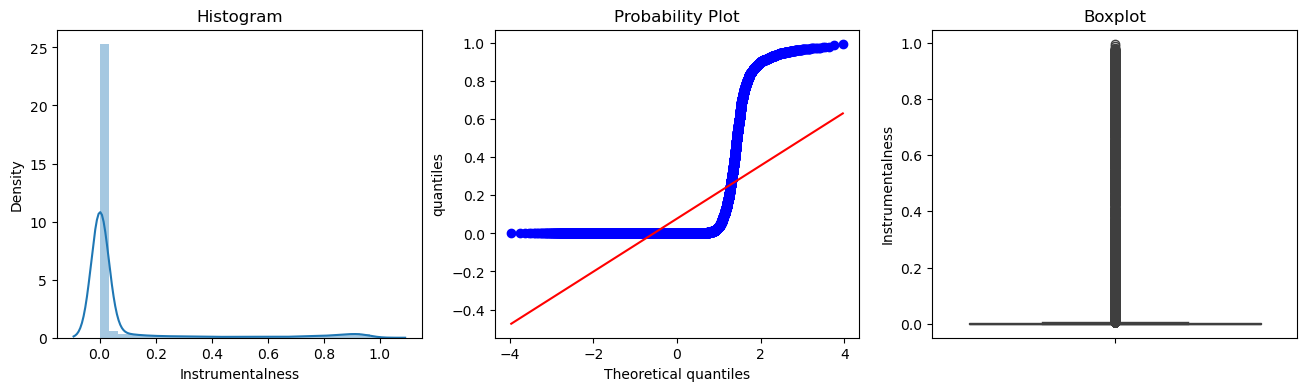

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


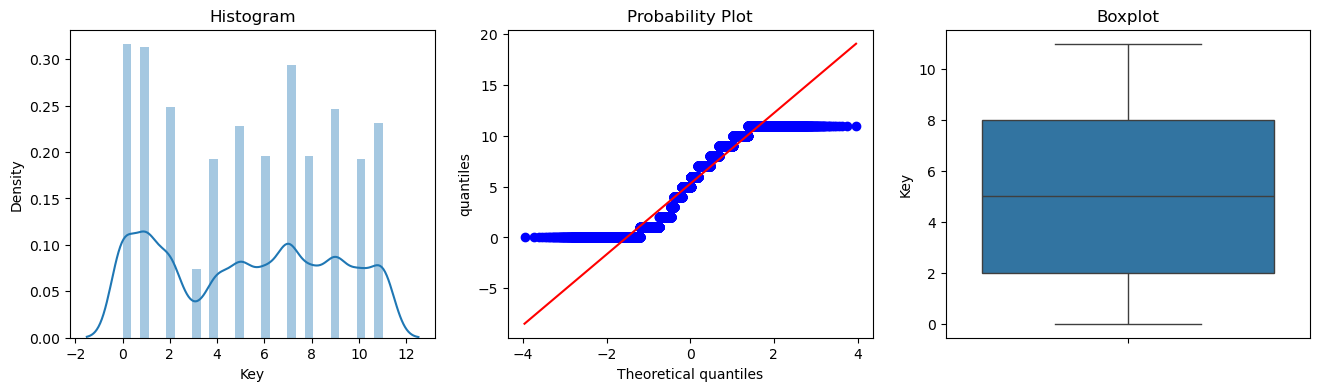

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


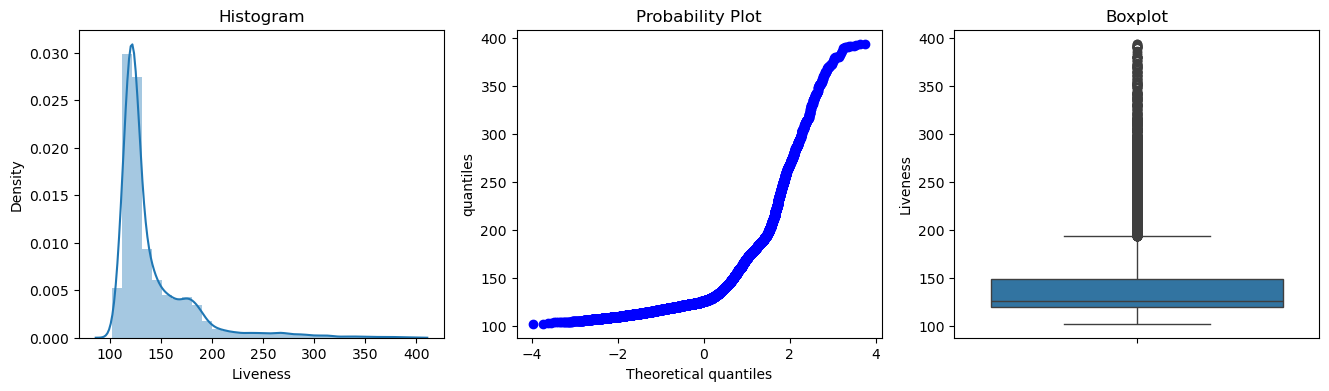

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


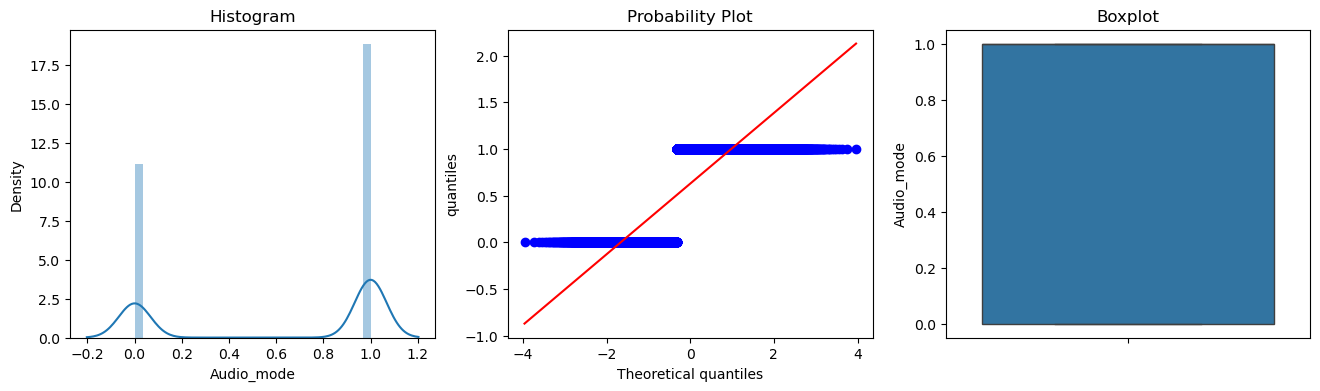

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


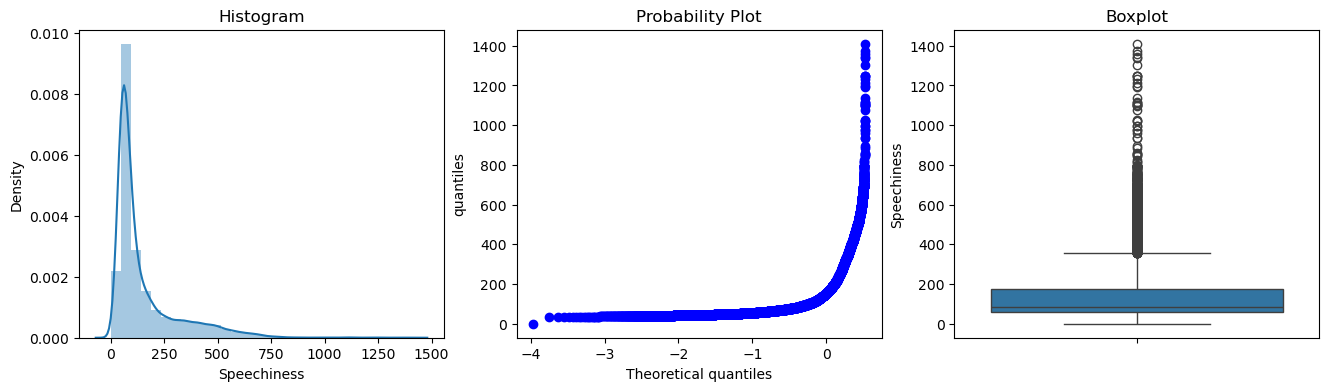

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


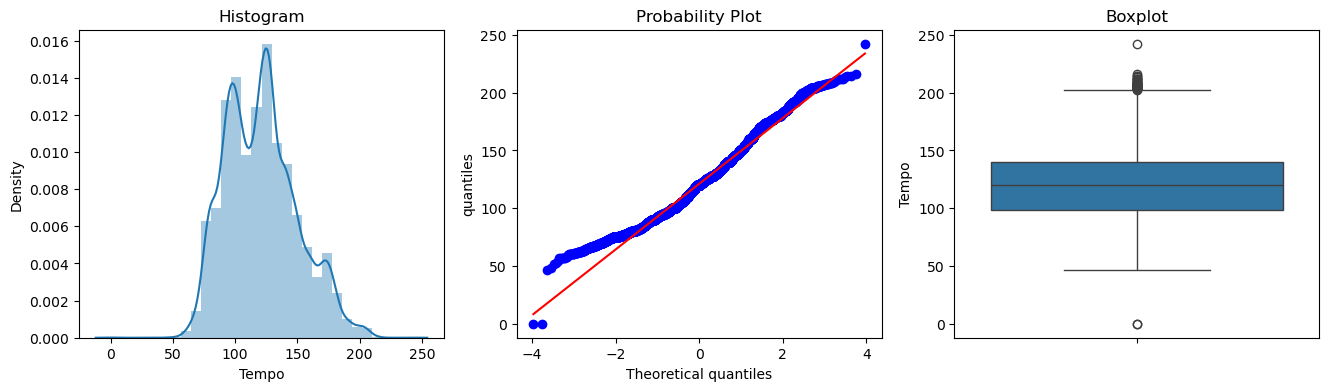

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


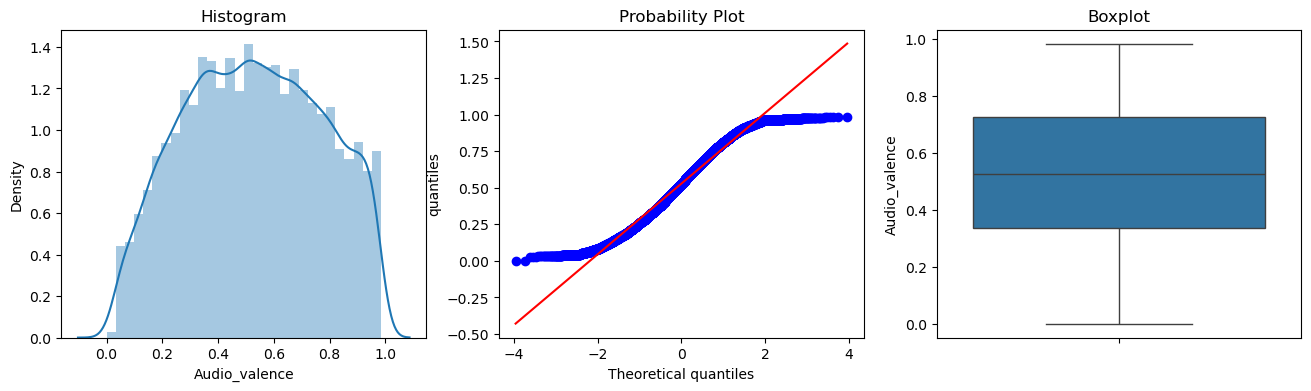

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


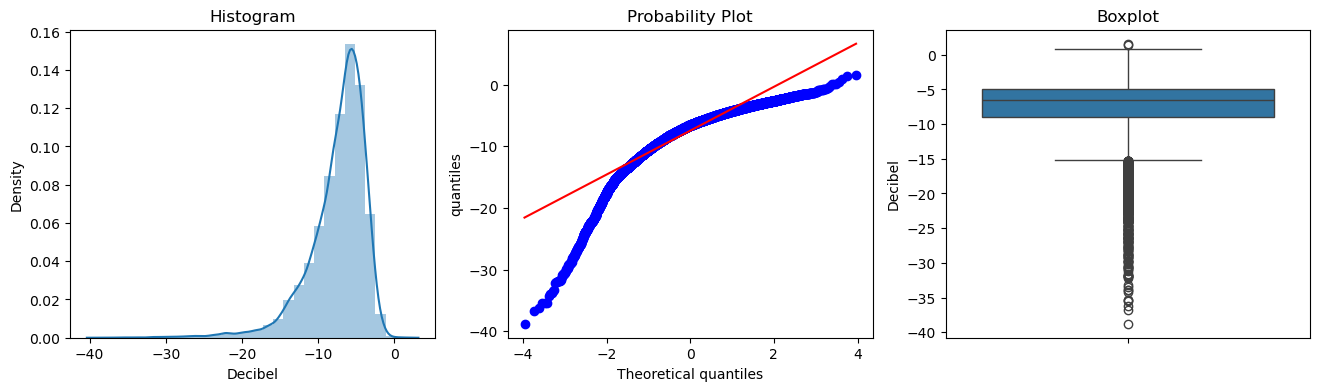

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


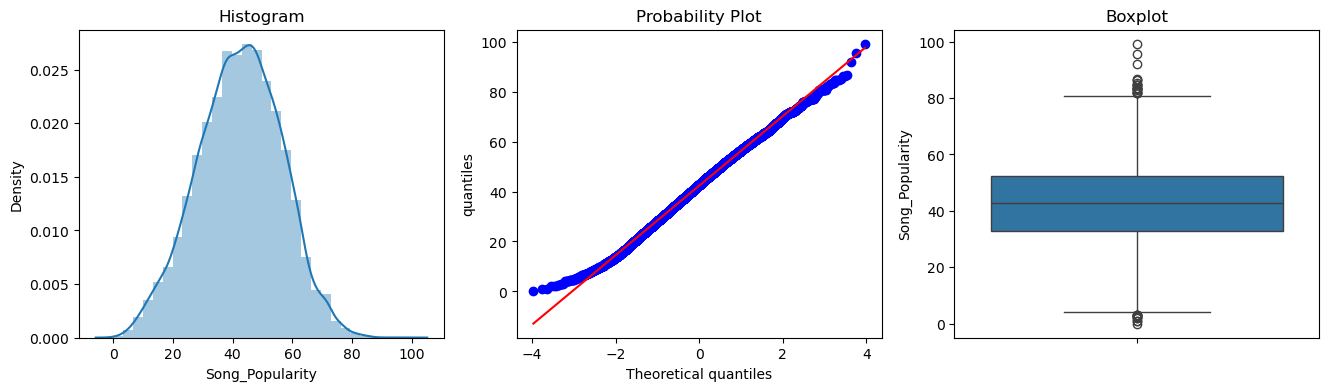

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


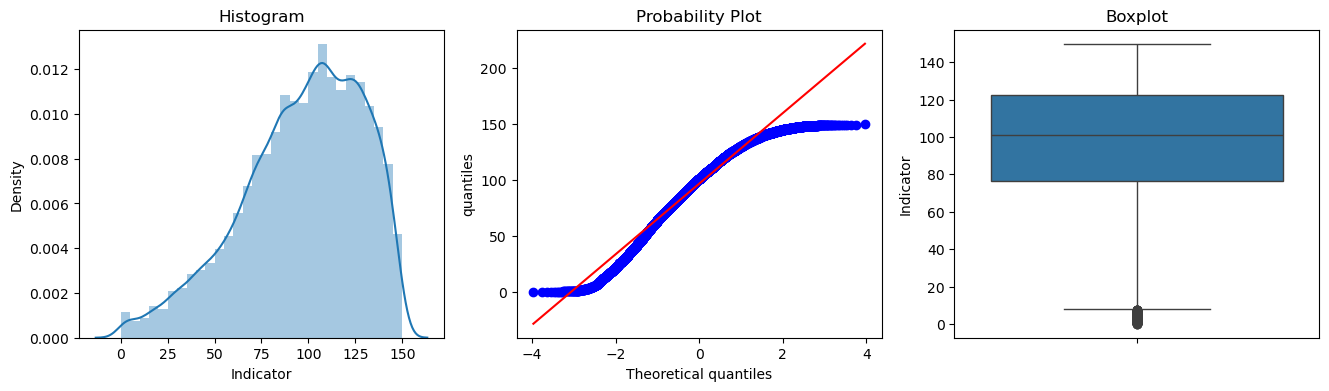

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


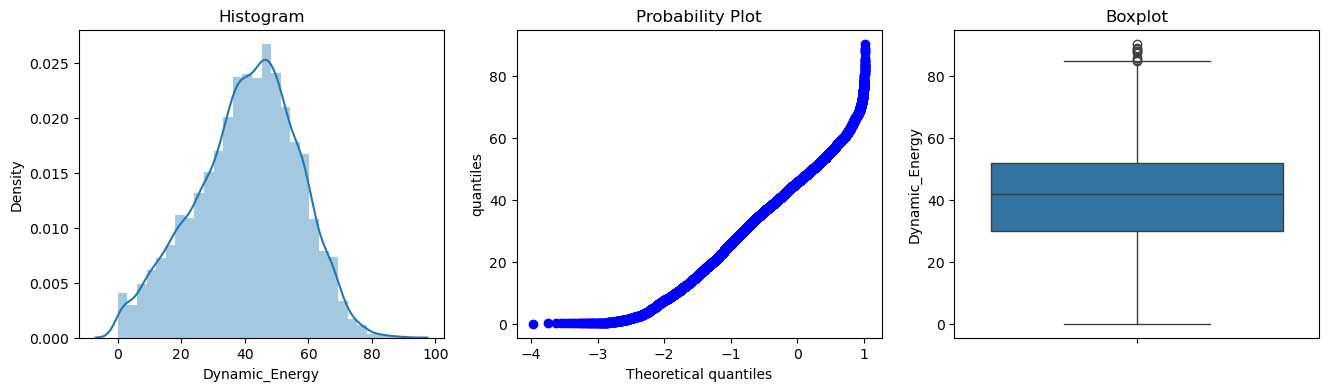

In [78]:
# check original distribution
# Detecting outliers using boxplots
for num_column in data[num_cols]:
    diagnostic_plots(data, num_column)

In [79]:
for column in data[num_cols]:
    skewness = data[column].skew()
    display(f"{column}:{skewness}")

'Song_Duration_ms:3.2574774267949547'

'Acousticness:1.0711641667143077'

'Danceability:-0.3859922081666196'

'Energy:-0.6207375069961603'

'Instrumentalness:2.9851763621291325'

...

'Audio_valence:-0.016423216940938023'

'Decibel:-1.929510613899225'

'Song_Popularity:-0.08230876504590458'

'Indicator:-0.6207368919451839'

'Dynamic_Energy:-0.2670797939824458'

In [80]:
data.isnull().sum()

Code                   0
Song_Name              0
Song_Duration_ms       0
Acousticness           0
Danceability        2897
Energy                 0
Instrumentalness       0
Key                    0
Liveness               1
Audio_mode             0
Speechiness         5651
Tempo                  0
Audio_valence          0
Dynamism            3698
Decibel                0
Loudness            1902
Song_Popularity        0
Indicator              0
Dynamic_Energy      2897
dtype: int64

### Step 4: Train and Test Split

In [81]:
display(data[cat_cols].isnull().sum().sort_values())
display(data[cat_cols].isnull().mean().sort_values())

Code            0
Song_Name       0
Loudness     1902
Dynamism     3698
dtype: int64

Code         0.000000
Song_Name    0.000000
Loudness     0.100982
Dynamism     0.196337
dtype: float64

In [82]:
display(data[num_cols].isnull().sum().sort_values())
display(data[num_cols].isnull().mean().sort_values())

Song_Duration_ms       0
Acousticness           0
Energy                 0
Instrumentalness       0
Key                    0
Audio_mode             0
Tempo                  0
Audio_valence          0
Decibel                0
Song_Popularity        0
Indicator              0
Liveness               1
Danceability        2897
Dynamic_Energy      2897
Speechiness         5651
dtype: int64

Song_Duration_ms    0.000000
Acousticness        0.000000
Energy              0.000000
Instrumentalness    0.000000
Key                 0.000000
Audio_mode          0.000000
Tempo               0.000000
Audio_valence       0.000000
Decibel             0.000000
Song_Popularity     0.000000
Indicator           0.000000
Liveness            0.000053
Danceability        0.153809
Dynamic_Energy      0.153809
Speechiness         0.300027
dtype: float64

In [83]:
data = data.drop(['Song_Name', 'Code'], axis=1)

In [84]:
# Separate the data into training (70%) and testing sets (30%)
# Target variable is Song_Popularity

#train_test_split has 6 parameters maximum
X_train, X_test, y_train, y_test = train_test_split(
    data.drop('Song_Popularity', axis=1), data['Song_Popularity'], test_size=0.3, random_state=0)

X_train.shape, X_test.shape

((13184, 16), (5651, 16))

### Step 5: Missing Value Imputation

In [85]:
# find the percentage of missing data within those variables
X_train.isnull().mean()

Song_Duration_ms    0.000000
Acousticness        0.000000
Danceability        0.154581
Energy              0.000000
Instrumentalness    0.000000
Key                 0.000000
Liveness            0.000076
Audio_mode          0.000000
Speechiness         0.298468
Tempo               0.000000
Audio_valence       0.000000
Dynamism            0.195009
Decibel             0.000000
Loudness            0.100880
Indicator           0.000000
Dynamic_Energy      0.154581
dtype: float64

In [86]:
data.dtypes

Song_Duration_ms      int64
Acousticness        float64
Danceability        float64
Energy              float64
Instrumentalness    float64
Key                   int64
Liveness            float64
Audio_mode            int64
Speechiness         float64
Tempo               float64
Audio_valence       float64
Dynamism             object
Decibel             float64
Loudness             object
Song_Popularity     float64
Indicator           float64
Dynamic_Energy      float64
dtype: object

In [87]:
X_train.dtypes

Song_Duration_ms      int64
Acousticness        float64
Danceability        float64
Energy              float64
Instrumentalness    float64
Key                   int64
Liveness            float64
Audio_mode            int64
Speechiness         float64
Tempo               float64
Audio_valence       float64
Dynamism             object
Decibel             float64
Loudness             object
Indicator           float64
Dynamic_Energy      float64
dtype: object

In [88]:
# Find categorical variables after train and test split
X_train_cat_cols = [c for c in X_train.columns if X_train[c].dtypes=='O'] # what is this approach of populating cat_cols called?
# for loop will retrieve everything as long as they fulfill the dtypes condition
X_train[X_train_cat_cols].isnull().mean().sort_values()

Loudness    0.100880
Dynamism    0.195009
dtype: float64

In [89]:
# Find numerical variables after train and test split
X_train_num_cols = [n for n in X_train.columns if X_train[n].dtypes!='O']
X_train[X_train_num_cols].isnull().mean().sort_values()

Song_Duration_ms    0.000000
Acousticness        0.000000
Energy              0.000000
Instrumentalness    0.000000
Key                 0.000000
Audio_mode          0.000000
Tempo               0.000000
Audio_valence       0.000000
Decibel             0.000000
Indicator           0.000000
Liveness            0.000076
Danceability        0.154581
Dynamic_Energy      0.154581
Speechiness         0.298468
dtype: float64

In [90]:
# Make a list with numerical varibles (arbitrary & median) and categorical variables (frequent & missing). 
# we make a list with the numerical vars
features_num_arbitrary = ['Liveness', 'Danceability','Speechiness','Dynamic_Energy']
features_num_median = ['Song_Duration_ms','Acousticness','Energy','Instrumentalness','Key','Audio_mode','Tempo',
                       'Audio_valence','Decibel','Indicator','Liveness','Danceability','Speechiness']

# we make a list with the categorical vars
# features_cat_frequent = ['Code','Song_Name']
features_cat_missing = ['Loudness','Dynamism']

In [91]:
print(X_train)

       Song_Duration_ms  Acousticness  Danceability  Energy  Instrumentalness  \
4659             200133      0.296940       0.71874   70.80          0.000000   
4389             243306      0.048706           NaN   58.90          0.000000   
10549            145411      0.629160       0.65637   53.10          0.004120   
11105            153600      0.886900       0.76230    1.61          0.914000   
3183             206946      0.223440       0.56430   57.60          0.000000   
...                 ...           ...           ...     ...               ...   
9225             246173      0.114660       0.84546   58.00          0.004710   
13123            220000      0.264600           NaN   78.20          0.000001   
9845             193868      0.272440       0.84645   58.20          0.000000   
10799            244185      0.035574       0.71181   70.30          0.867000   
2732             248946      0.493920       0.24651   66.00          0.002600   

       Key    Liveness  Aud

In [92]:
# Assembling an imputation pipeline using Feature Engine

pipe = Pipeline(steps=[
    ('imp_num_arbitrary', mdi.ArbitraryNumberImputer(variables = features_num_arbitrary)),
    ('imp_num_median', mdi.MeanMedianImputer(imputation_method = 'median', variables=features_num_median)),
#     ('imp_cat_frequent', mdi.CategoricalImputer(variables = features_cat_frequent, imputation_method='frequent')),
    ('imp_cat_missing', mdi.CategoricalImputer(variables=features_cat_missing, imputation_method='missing'))
])

# now we fit the preprocessor
pipe.fit(X_train)

Pipeline(steps=[('imp_num_arbitrary',
                 ArbitraryNumberImputer(variables=['Liveness', 'Danceability',
                                                   'Speechiness',
                                                   'Dynamic_Energy'])),
                ('imp_num_median',
                 MeanMedianImputer(variables=['Song_Duration_ms',
                                              'Acousticness', 'Energy',
                                              'Instrumentalness', 'Key',
                                              'Audio_mode', 'Tempo',
                                              'Audio_valence', 'Decibel',
                                              'Indicator', 'Liveness',
                                              'Danceability', 'Speechiness'])),
                ('imp_cat_missing',
                 CategoricalImputer(variables=['Loudness', 'Dynamism']))])

In [93]:
# and now we impute the data
X_train_imputed = pipe.transform(X_train)
X_test_imputed = pipe.transform(X_test)

X_train_imputed

,Song_Duration_ms,Acousticness,Danceability,Energy,Instrumentalness,Key,Liveness,Audio_mode,Speechiness,Tempo,Audio_valence,Dynamism,Decibel,Loudness,Indicator,Dynamic_Energy
4659,200133,0.296940,0.71874,70.80,0.000000,7,181.710400,0,534.00,105.084,0.417,Hi,-6.908,Roar,106.20,50.886792
4389,243306,0.048706,999.00000,58.90,0.000000,1,112.296409,1,204.00,95.029,0.159,Med,-4.665,Blare,88.35,999.000000
10549,145411,0.629160,0.65637,53.10,0.004120,9,120.165444,1,67.80,140.657,0.531,Medium,-8.452,Clang,79.65,34.853247
11105,153600,0.886900,0.76230,1.61,0.914000,4,123.876900,1,999.00,75.047,0.700,Lo,-14.233,Babble,2.42,1.227303
3183,206946,0.223440,0.56430,57.60,0.000000,1,176.890000,1,94.65,143.943,0.438,Med,-6.792,Roar,86.40,32.503680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9225,246173,0.114660,0.84546,58.00,0.004710,1,119.268241,1,325.50,162.116,0.700,Med,-10.008,Rumble,87.00,49.036680
13123,220000,0.264600,999.00000,78.20,0.000001,3,117.288900,1,999.00,200.066,0.440,High,-5.709,Blare,117.30,999.000000
9845,193868,0.272440,0.84645,58.20,0.000000,0,110.145025,1,153.00,75.010,0.907,Med,-4.933,Blare,87.30,49.263390
10799,244185,0.035574,0.71181,70.30,0.867000,4,123.432100,0,86.55,119.995,0.171,Missing,-8.963,Clang,105.45,50.040243


In [94]:
print(X_train)

       Song_Duration_ms  Acousticness  Danceability  Energy  Instrumentalness  \
4659             200133      0.296940       0.71874   70.80          0.000000   
4389             243306      0.048706           NaN   58.90          0.000000   
10549            145411      0.629160       0.65637   53.10          0.004120   
11105            153600      0.886900       0.76230    1.61          0.914000   
3183             206946      0.223440       0.56430   57.60          0.000000   
...                 ...           ...           ...     ...               ...   
9225             246173      0.114660       0.84546   58.00          0.004710   
13123            220000      0.264600           NaN   78.20          0.000001   
9845             193868      0.272440       0.84645   58.20          0.000000   
10799            244185      0.035574       0.71181   70.30          0.867000   
2732             248946      0.493920       0.24651   66.00          0.002600   

       Key    Liveness  Aud

In [95]:
X_train.isnull().sum()

Song_Duration_ms       0
Acousticness           0
Danceability        2038
Energy                 0
Instrumentalness       0
Key                    0
Liveness               1
Audio_mode             0
Speechiness         3935
Tempo                  0
Audio_valence          0
Dynamism            2571
Decibel                0
Loudness            1330
Indicator              0
Dynamic_Energy      2038
dtype: int64

In [96]:
X_train_imputed.isnull().sum()

Song_Duration_ms    0
Acousticness        0
Danceability        0
Energy              0
Instrumentalness    0
Key                 0
Liveness            0
Audio_mode          0
Speechiness         0
Tempo               0
Audio_valence       0
Dynamism            0
Decibel             0
Loudness            0
Indicator           0
Dynamic_Energy      0
dtype: int64

In [97]:
# find categorical variables after imputation
X_train_imputed_cat_cols = [c for c in X_train_imputed.columns if X_train_imputed[c].dtypes=='O'] # what is this approach of populating cat_cols called?
# for loop will retrieve everything as long as they fulfill the dtypes condition

In [98]:
# Find numerical variables after imputation
X_train_imputed_num_cols = [n for n in X_train_imputed.columns if X_train_imputed[n].dtypes!='O']# what is this approach of populating cat_cols called?
# for loop will retrieve everything as long as they fulfill the dtypes condition

In [99]:
X_train[X_train_cat_cols].isnull().sum().sort_values()

Loudness    1330
Dynamism    2571
dtype: int64

In [100]:
X_train_imputed[X_train_imputed_cat_cols].isnull().sum().sort_values()

Dynamism    0
Loudness    0
dtype: int64

In [101]:
X_train[X_train_num_cols].isnull().sum().sort_values()

Song_Duration_ms       0
Acousticness           0
Energy                 0
Instrumentalness       0
Key                    0
Audio_mode             0
Tempo                  0
Audio_valence          0
Decibel                0
Indicator              0
Liveness               1
Danceability        2038
Dynamic_Energy      2038
Speechiness         3935
dtype: int64

In [102]:
X_train_imputed[X_train_imputed_num_cols].isnull().sum().sort_values()

Song_Duration_ms    0
Acousticness        0
Danceability        0
Energy              0
Instrumentalness    0
Key                 0
Liveness            0
Audio_mode          0
Speechiness         0
Tempo               0
Audio_valence       0
Decibel             0
Indicator           0
Dynamic_Energy      0
dtype: int64

### Step 6: Variance Stabilizing Transformations

In [104]:
#####Since both negative and positive values are present in the range, Yeo-Johnson transformation will be implemented.

In [105]:
# initialize the transformer with a subset of variables to transform
yjt = YeoJohnsonTransformer(variables = ['Song_Duration_ms', 'Acousticness', 'Energy', 'Instrumentalness',
                                        'Key','Audio_mode','Tempo','Audio_valence','Decibel','Indicator',
                                         'Liveness','Danceability','Speechiness','Dynamic_Energy'])

# fit transformer to the dataframe
yjt.fit(X_train_imputed)

YeoJohnsonTransformer(variables=['Song_Duration_ms', 'Acousticness', 'Energy',
                                 'Instrumentalness', 'Key', 'Audio_mode',
                                 'Tempo', 'Audio_valence', 'Decibel',
                                 'Indicator', 'Liveness', 'Danceability',
                                 'Speechiness', 'Dynamic_Energy'])

In [106]:
# transform indicated variables

X_train_transformed = yjt.transform(X_train_imputed)
X_test_transformed = yjt.transform(X_test_imputed)

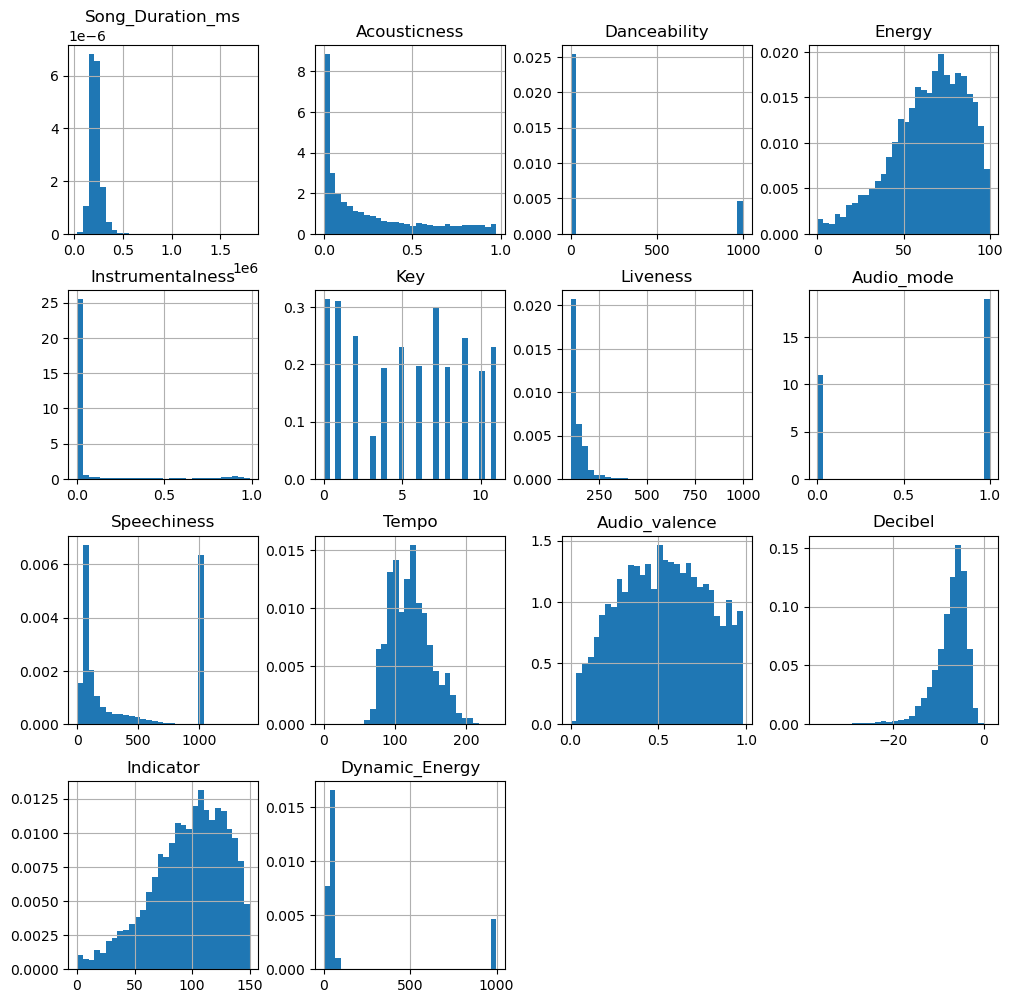

In [107]:
# un-transformed variables (before transformation)
X_train_imputed.hist(bins=30, figsize=(12,12), density=True)
plt.show()

In [108]:
# Find numerical variables after imputation
X_train_transformed_num_cols = [n for n in X_train_transformed.columns if X_train_transformed[n].dtypes!='O']
# for loop will retrieve everything as long as they fulfill the dtypes condition

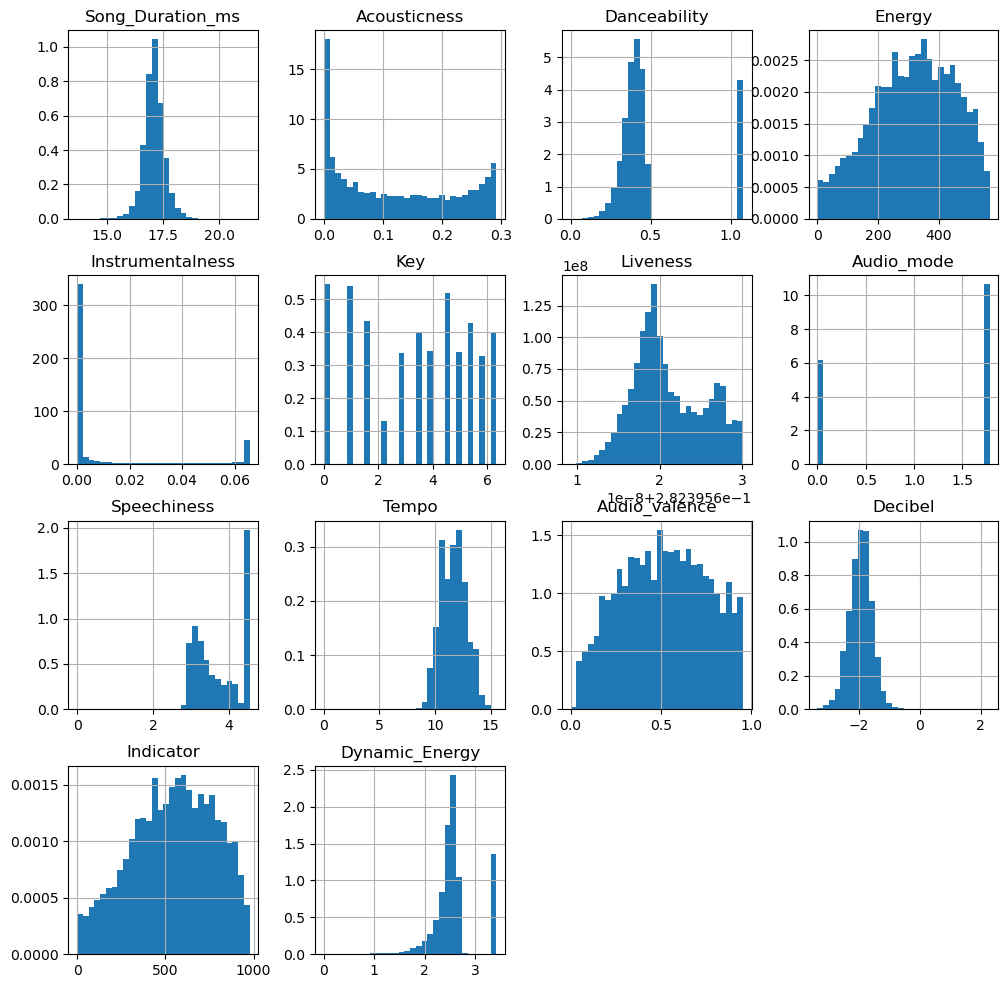

In [109]:
# transformed variables (after transformation)
X_train_transformed.hist(bins=30, figsize=(12,12), density=True)
plt.show()

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


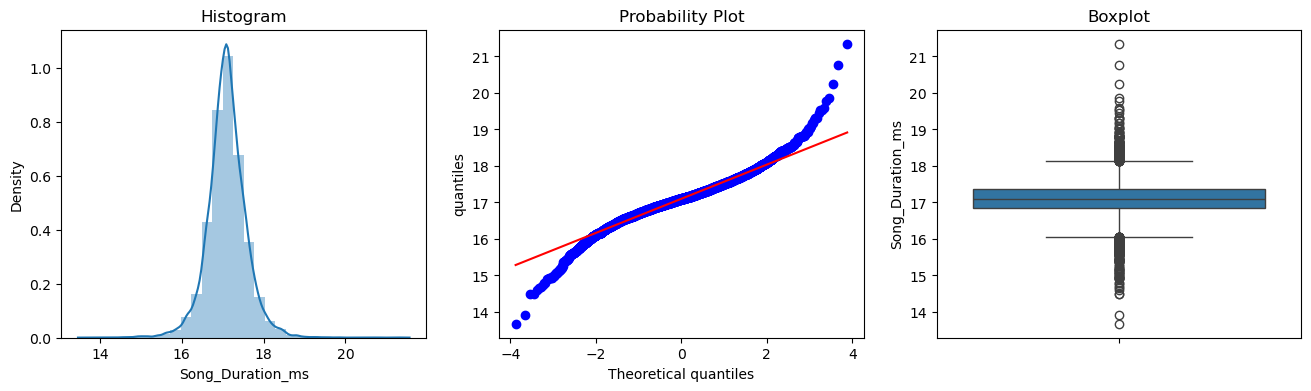

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


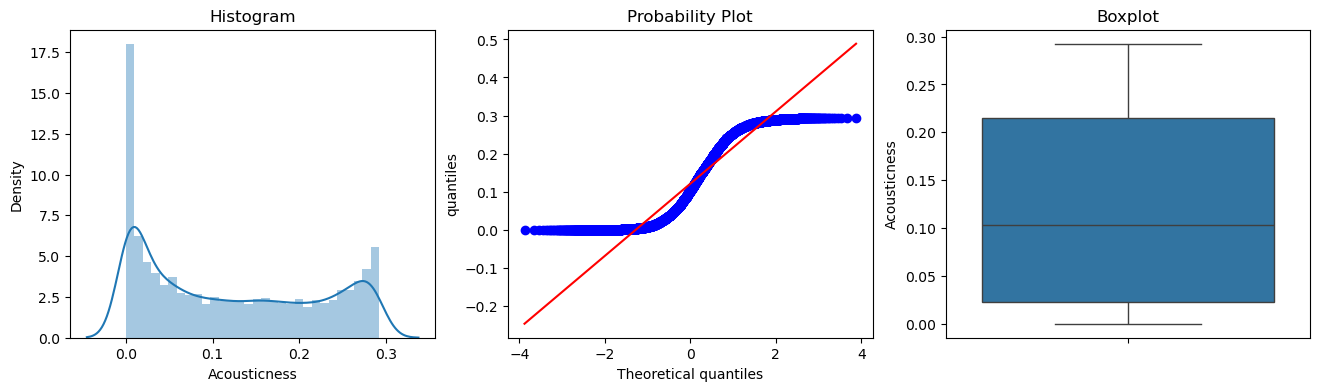

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


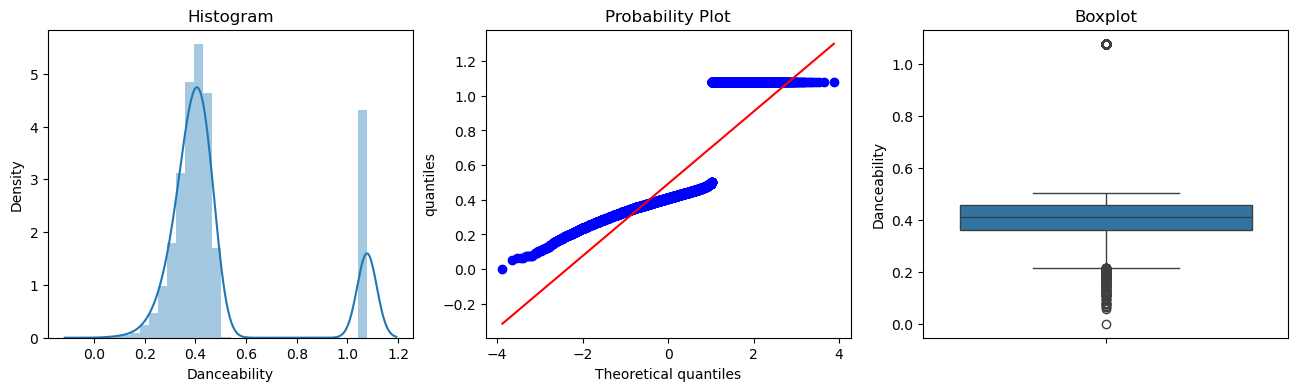

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


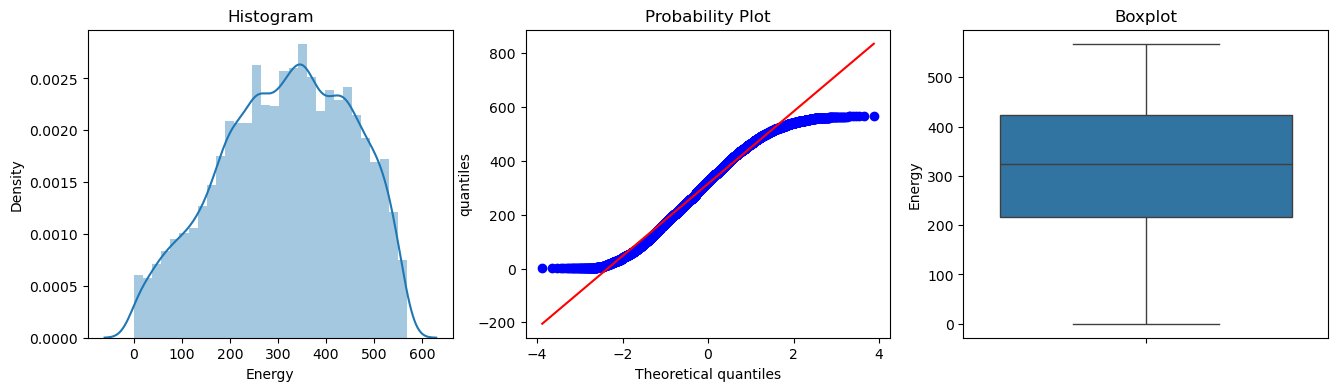

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


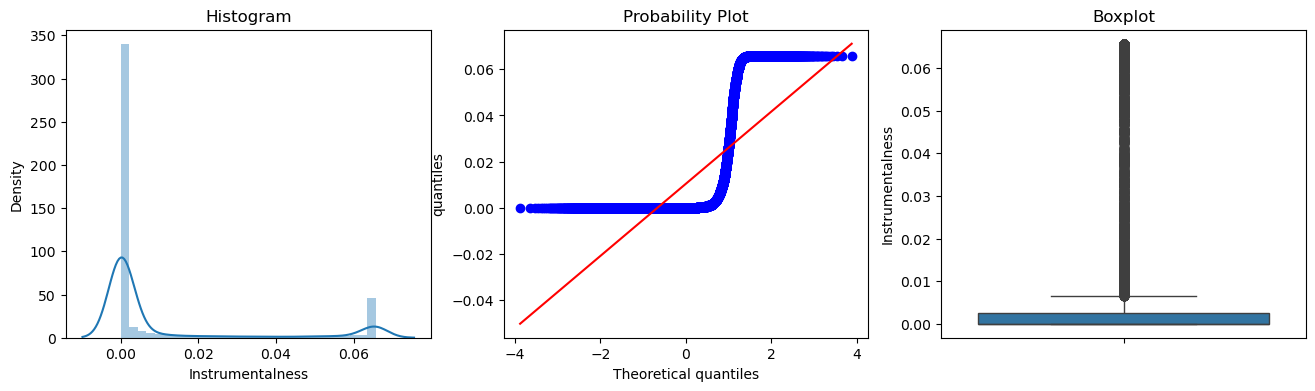

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


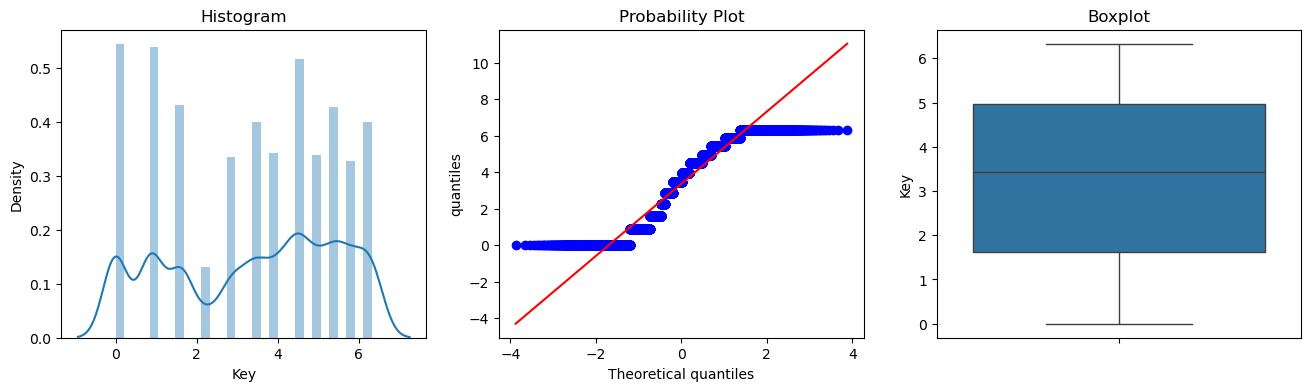

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


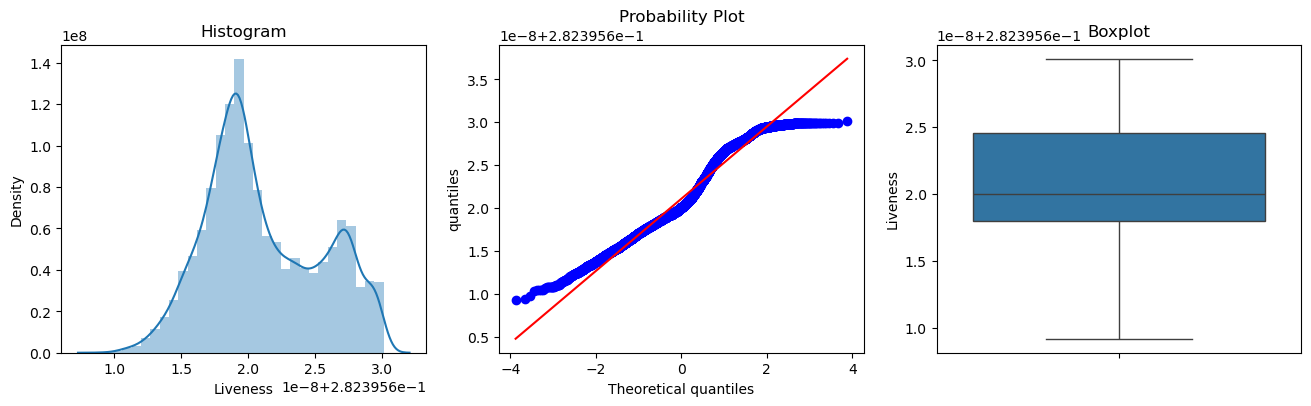

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


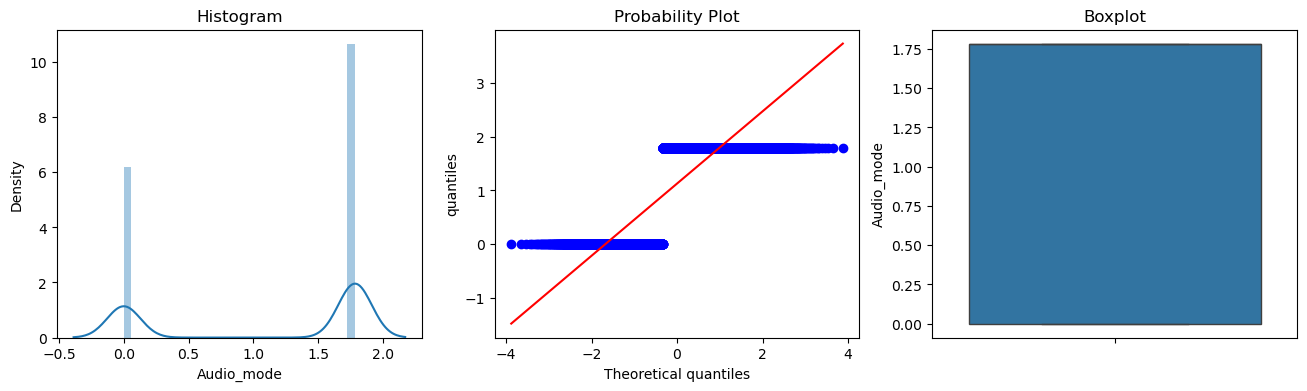

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


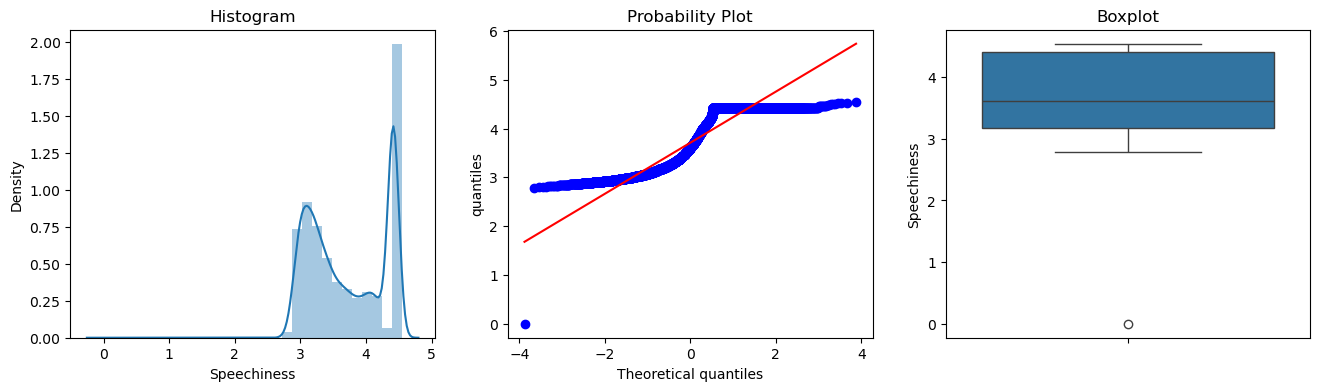

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


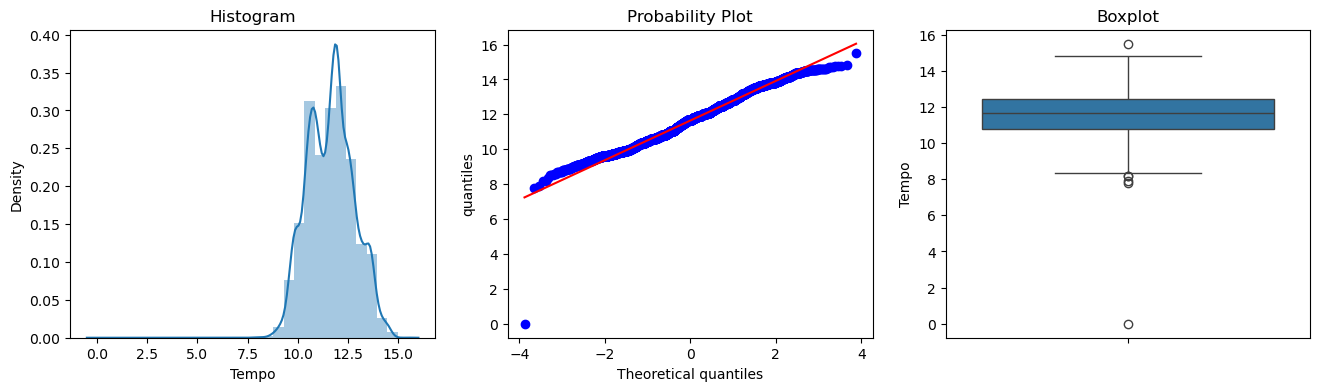

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


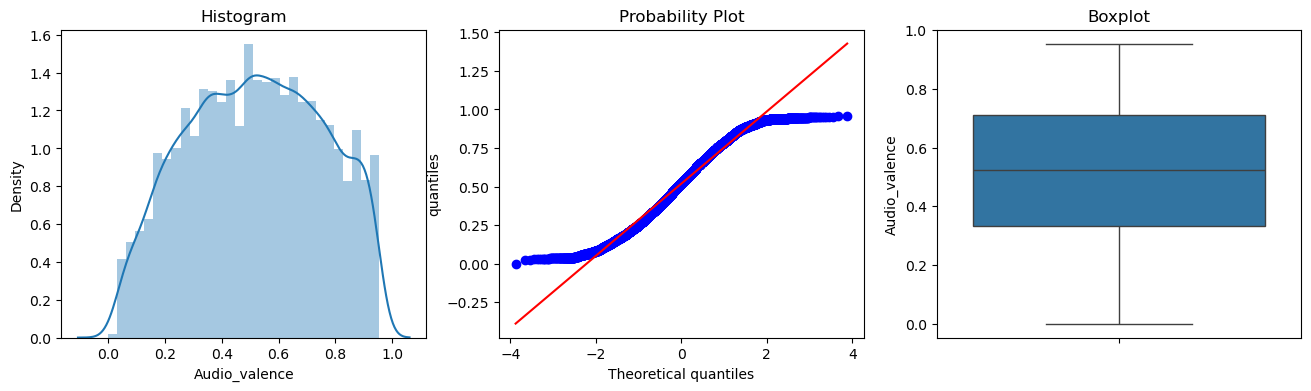

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


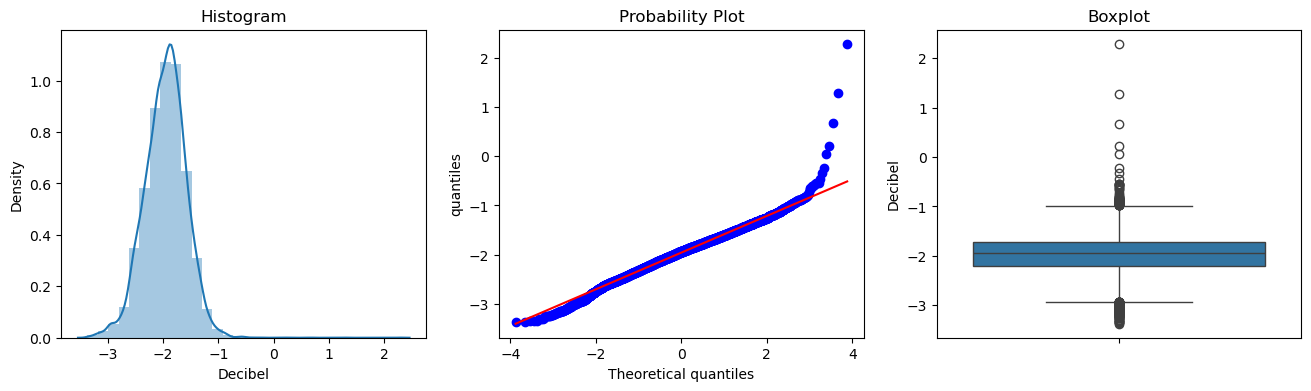

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


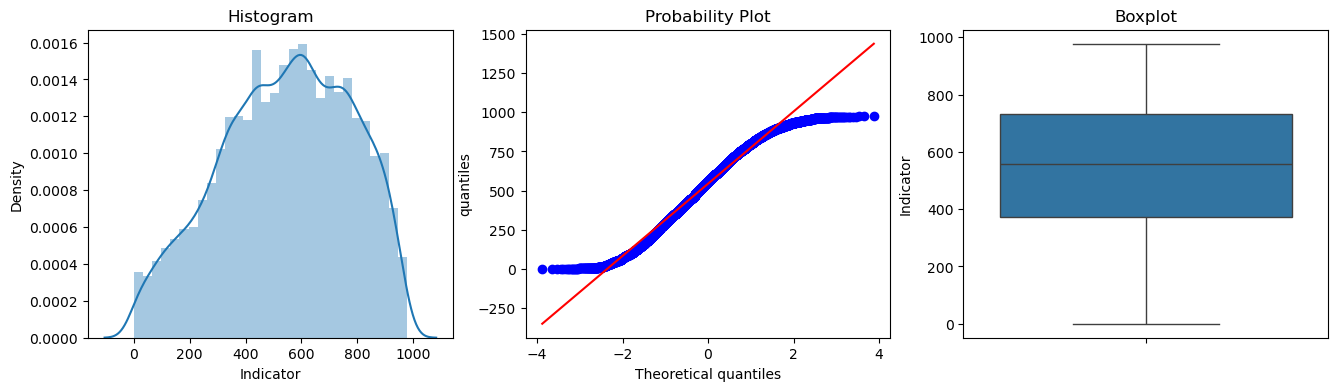

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


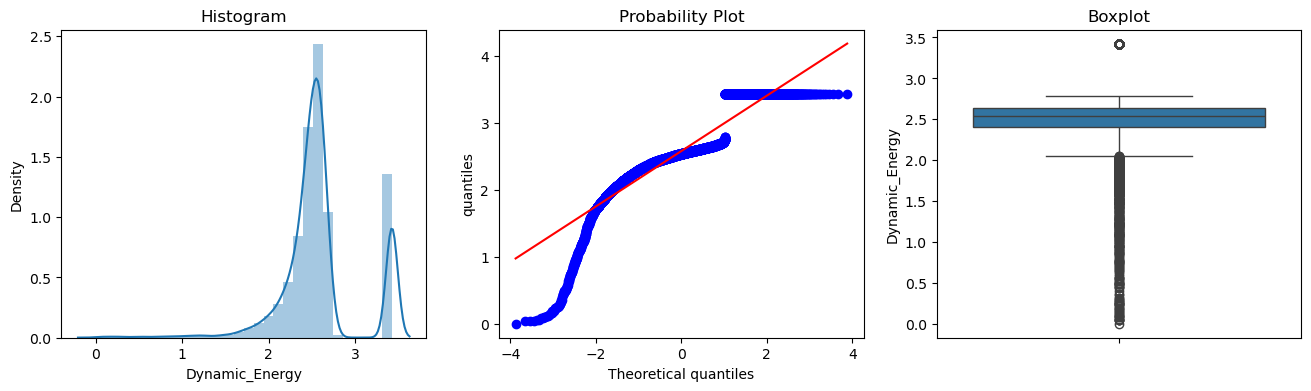

In [110]:
# check transformed distribution
# Detecting outliers using boxplots
for transformed_num_cols in X_train_imputed[X_train_transformed_num_cols]:
    diagnostic_plots(X_train_transformed, transformed_num_cols)

In [111]:
for before_transformation_column in X_train_imputed[X_train_imputed_num_cols]:
    skewness_before_transformation = X_train_transformed[before_transformation_column].skew()
    display(f"{before_transformation_column}:{skewness_before_transformation}")

'Song_Duration_ms:0.014827360572485954'

'Acousticness:0.31560195750978615'

'Danceability:1.6767124194047056'

'Energy:-0.24416295953543488'

'Instrumentalness:1.9053417157544164'

...

'Tempo:0.02389087052899695'

'Audio_valence:-0.049223645483324606'

'Decibel:0.0289082324159647'

'Indicator:-0.2487490454297881'

'Dynamic_Energy:-0.18151196113245968'

In [112]:
for after_transformation_column in X_train_transformed[X_train_transformed_num_cols]:
    skewness_after_transformation = X_train_transformed[after_transformation_column].skew()
    display(f"{after_transformation_column}:{skewness_after_transformation}")

'Song_Duration_ms:0.014827360572485954'

'Acousticness:0.31560195750978615'

'Danceability:1.6767124194047056'

'Energy:-0.24416295953543488'

'Instrumentalness:1.9053417157544164'

...

'Tempo:0.02389087052899695'

'Audio_valence:-0.049223645483324606'

'Decibel:0.0289082324159647'

'Indicator:-0.2487490454297881'

'Dynamic_Energy:-0.18151196113245968'

In [113]:
X_train_transformed[X_train_transformed_num_cols].isnull().sum().sort_values()

Song_Duration_ms    0
Acousticness        0
Danceability        0
Energy              0
Instrumentalness    0
Key                 0
Liveness            0
Audio_mode          0
Speechiness         0
Tempo               0
Audio_valence       0
Decibel             0
Indicator           0
Dynamic_Energy      0
dtype: int64

### Step 7: Variable Discretization /Binning

In [114]:
X_train_transformed.dtypes

Song_Duration_ms    float64
Acousticness        float64
Danceability        float64
Energy              float64
Instrumentalness    float64
Key                 float64
Liveness            float64
Audio_mode          float64
Speechiness         float64
Tempo               float64
Audio_valence       float64
Dynamism             object
Decibel             float64
Loudness             object
Indicator           float64
Dynamic_Energy      float64
dtype: object

In [115]:
# with feature engine we can automate the process for many variables
# in one line of code

disc = EqualFrequencyDiscretiser(
    q=10, variables=['Song_Duration_ms', 'Acousticness', 'Energy', 'Instrumentalness',
                                        'Key','Audio_mode','Tempo','Audio_valence','Decibel','Indicator',
                                         'Liveness','Danceability','Speechiness','Dynamic_Energy'], return_object=True)

disc.fit(X_train_transformed)

EqualFrequencyDiscretiser(return_object=True,
                          variables=['Song_Duration_ms', 'Acousticness',
                                     'Energy', 'Instrumentalness', 'Key',
                                     'Audio_mode', 'Tempo', 'Audio_valence',
                                     'Decibel', 'Indicator', 'Liveness',
                                     'Danceability', 'Speechiness',
                                     'Dynamic_Energy'])

In [116]:
X_train_transformed.dtypes

Song_Duration_ms    float64
Acousticness        float64
Danceability        float64
Energy              float64
Instrumentalness    float64
Key                 float64
Liveness            float64
Audio_mode          float64
Speechiness         float64
Tempo               float64
Audio_valence       float64
Dynamism             object
Decibel             float64
Loudness             object
Indicator           float64
Dynamic_Energy      float64
dtype: object

In [117]:
# transform train and test

X_train_binned = disc.transform(X_train_transformed)
X_test_binned = disc.transform(X_test_transformed)

In [118]:
X_train_binned.dtypes

Song_Duration_ms    object
Acousticness        object
Danceability        object
Energy              object
Instrumentalness    object
Key                 object
Liveness            object
Audio_mode          object
Speechiness         object
Tempo               object
Audio_valence       object
Dynamism            object
Decibel             object
Loudness            object
Indicator           object
Dynamic_Energy      object
dtype: object

In [119]:
# Find numerical variables after binning
X_train_binned_num_cols = [n for n in X_train_binned.columns if X_train_binned[n].dtypes!='O']

In [120]:
# let's explore if the bins have a linear relationship
# with the target: we see they don't

for var in X_train_binned[X_train_binned_num_cols]:
    pd.concat([X_train_binned, y_train], axis=1).groupby('var')['Song_Popularity'].mean().plot()
    plt.ylabel('mean of {var}')

Text(0, 0.5, 'Number of observations per bin')

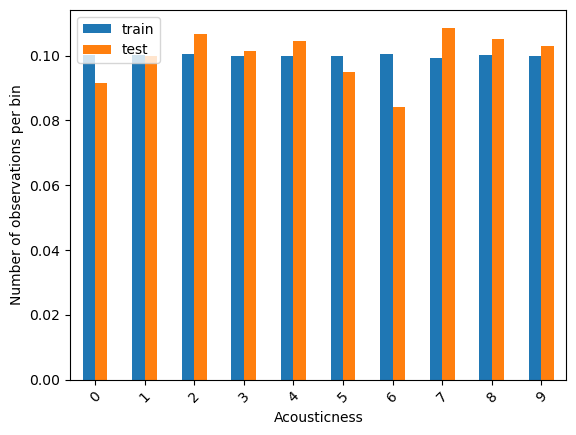

In [121]:
# if the distributions in train and test set are similar, we should expect similar propotion of
# observations in the different intervals in the train and test set

# Acousticness

t1 = X_train_binned.groupby(['Acousticness'])['Acousticness'].count() / len(X_train_binned)
t2 = X_test_binned.groupby(['Acousticness'])['Acousticness'].count() / len(X_test_binned)

tmp = pd.concat([t1, t2], axis=1)
tmp.columns = ['train', 'test']
tmp.plot.bar()
plt.xticks(rotation=45)
plt.ylabel('Number of observations per bin')

Text(0, 0.5, 'Number of observations per bin')

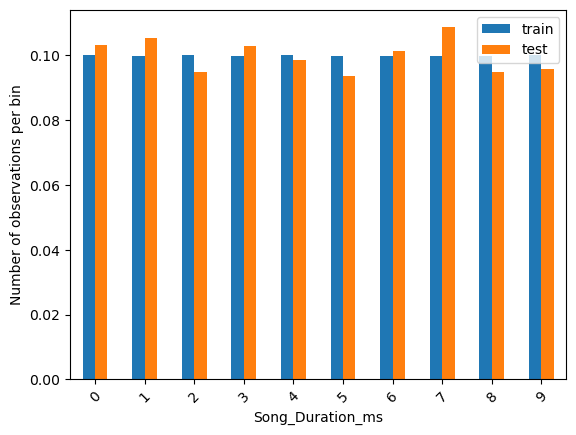

In [122]:
# if the distributions in train and test set are similar, we should expect similar propotion of
# observations in the different intervals in the train and test set

# Song_Duration_ms

t1 = X_train_binned.groupby(['Song_Duration_ms'])['Song_Duration_ms'].count() / len(X_train_binned)
t2 = X_test_binned.groupby(['Song_Duration_ms'])['Song_Duration_ms'].count() / len(X_test_binned)

tmp = pd.concat([t1, t2], axis=1)
tmp.columns = ['train', 'test']
tmp.plot.bar()
plt.xticks(rotation=45)
plt.ylabel('Number of observations per bin')

Text(0, 0.5, 'Number of observations per bin')

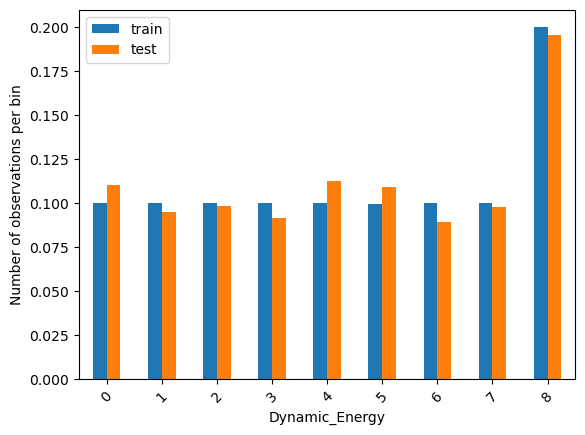

In [123]:
# if the distributions in train and test set are similar, we should expect similar propotion of
# observations in the different intervals in the train and test set

# Dynamic_Energy

t1 = X_train_binned.groupby(['Dynamic_Energy'])['Dynamic_Energy'].count() / len(X_train_binned)
t2 = X_test_binned.groupby(['Dynamic_Energy'])['Dynamic_Energy'].count() / len(X_test_binned)

tmp = pd.concat([t1, t2], axis=1)
tmp.columns = ['train', 'test']
tmp.plot.bar()
plt.xticks(rotation=45)
plt.ylabel('Number of observations per bin')

Text(0, 0.5, 'Number of observations per bin')

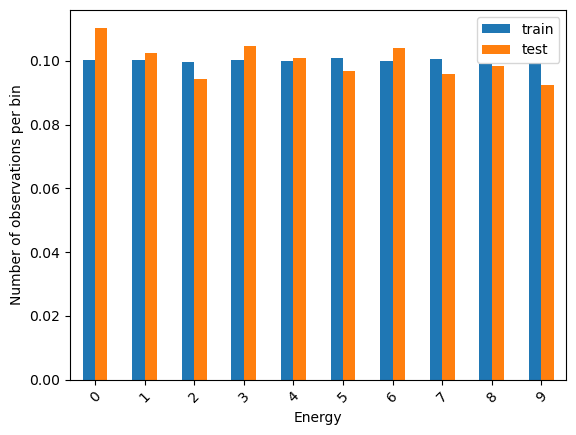

In [124]:
# if the distributions in train and test set are similar, we should expect similar propotion of
# observations in the different intervals in the train and test set

# Energy

t1 = X_train_binned.groupby(['Energy'])['Energy'].count() / len(X_train_binned)
t2 = X_test_binned.groupby(['Energy'])['Energy'].count() / len(X_test_binned)

tmp = pd.concat([t1, t2], axis=1)
tmp.columns = ['train', 'test']
tmp.plot.bar()
plt.xticks(rotation=45)
plt.ylabel('Number of observations per bin')

Text(0, 0.5, 'Number of observations per bin')

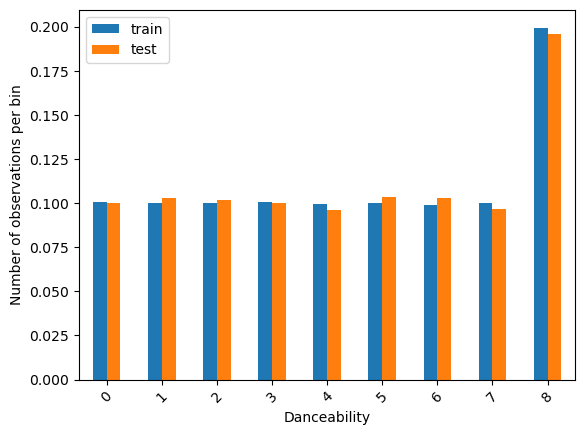

In [125]:
# if the distributions in train and test set are similar, we should expect similar propotion of
# observations in the different intervals in the train and test set

# Danceability

t1 = X_train_binned.groupby(['Danceability'])['Danceability'].count() / len(X_train_binned)
t2 = X_test_binned.groupby(['Danceability'])['Danceability'].count() / len(X_test_binned)

tmp = pd.concat([t1, t2], axis=1)
tmp.columns = ['train', 'test']
tmp.plot.bar()
plt.xticks(rotation=45)
plt.ylabel('Number of observations per bin')

Text(0, 0.5, 'Number of observations per bin')

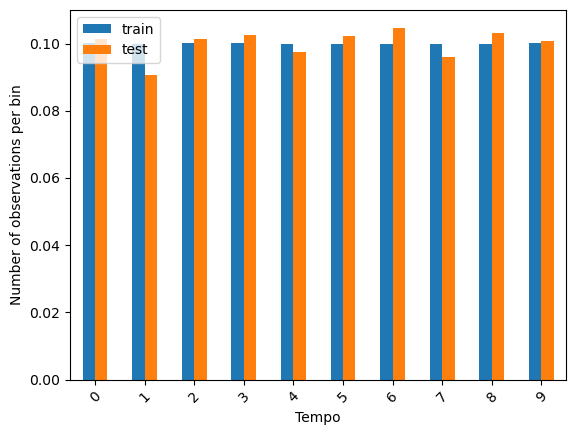

In [126]:
# if the distributions in train and test set are similar, we should expect similar propotion of
# observations in the different intervals in the train and test set

# Tempo

t1 = X_train_binned.groupby(['Tempo'])['Tempo'].count() / len(X_train_binned)
t2 = X_test_binned.groupby(['Tempo'])['Tempo'].count() / len(X_test_binned)

tmp = pd.concat([t1, t2], axis=1)
tmp.columns = ['train', 'test']
tmp.plot.bar()
plt.xticks(rotation=45)
plt.ylabel('Number of observations per bin')

Text(0, 0.5, 'Number of observations per bin')

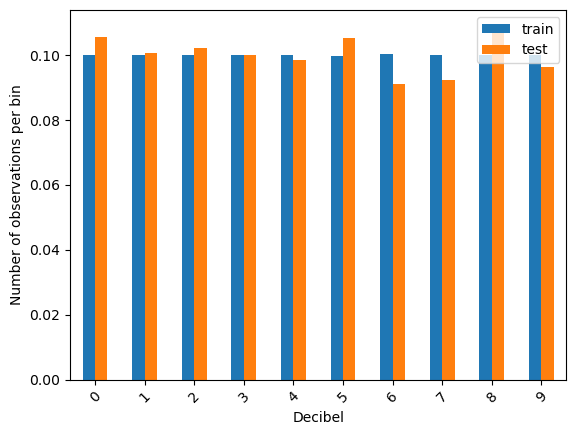

In [127]:
# if the distributions in train and test set are similar, we should expect similar propotion of
# observations in the different intervals in the train and test set

# Decibel

t1 = X_train_binned.groupby(['Decibel'])['Decibel'].count() / len(X_train_binned)
t2 = X_test_binned.groupby(['Decibel'])['Decibel'].count() / len(X_test_binned)

tmp = pd.concat([t1, t2], axis=1)
tmp.columns = ['train', 'test']
tmp.plot.bar()
plt.xticks(rotation=45)
plt.ylabel('Number of observations per bin')

### Step 8: Categorical Data Encoding

This dataset has 2 categorical variables, Dynamism and Loudness.¶ Dynamism has a clear and meaningful order between the categories (e.g., Hi > High > Medium > ...) Hence, ordered ordinal encoding is implemented for Dynamism. But unlike Dynamism, Loudness doesn't display any distinct rank or order between the categories. Hence, target mean encoding is implemented for 'Dynamism', 'Song_Duration_ms', 'Acousticness', 'Energy', 'Instrumentalness','Key','A

#### Ordered Ordinal Encoding

In [128]:
# Task 5: Encode X_train & X_test using ordinal / label encoding

# let's create the encoder
ordinal_enc = OrdinalEncoder(
    encoding_method='ordered', variables = ['Dynamism', 'Song_Duration_ms', 'Acousticness', 'Energy', 'Instrumentalness',
                                        'Key','Audio_mode','Tempo','Audio_valence','Decibel','Indicator',
                                         'Liveness','Danceability','Speechiness','Dynamic_Energy'])

I chose to use a ordered ordinal encoding method which means the encoder will assign numbers following the mean of the target value for that label.

In [129]:
# when fitting the transformer, we need to pass the target as well
# just like with any Scikit-learn predictor class

ordinal_enc.fit(X_train_binned, y_train)

OrdinalEncoder(variables=['Dynamism', 'Song_Duration_ms', 'Acousticness',
                          'Energy', 'Instrumentalness', 'Key', 'Audio_mode',
                          'Tempo', 'Audio_valence', 'Decibel', 'Indicator',
                          'Liveness', 'Danceability', 'Speechiness',
                          'Dynamic_Energy'])

In [130]:
# the encoder stores the variables that it will encode

ordinal_enc.variables_

['Dynamism',
 'Song_Duration_ms',
 'Acousticness',
 'Energy',
 'Instrumentalness',
 'Key',
 'Audio_mode',
 'Tempo',
 'Audio_valence',
 'Decibel',
 'Indicator',
 'Liveness',
 'Danceability',
 'Speechiness',
 'Dynamic_Energy']

In [131]:
# in the encoder dict we can observe the numbers that will
#replace each category in each variable

ordinal_enc.encoder_dict_

{'Dynamism': {'Low': 0,
  'Lo': 1,
  'l': 2,
  'Medium': 3,
  'Med': 4,
  'Missing': 5,
  'm': 6,
  'High': 7,
  'Hi': 8,
  'high': 9,
  'Extra': 10,
  'h': 11},
 'Song_Duration_ms': {0: 0,
  9: 1,
  1: 2,
  8: 3,
  6: 4,
  7: 5,
  2: 6,
  4: 7,
  5: 8,
  3: 9},
 'Acousticness': {9: 0, 8: 1, 7: 2, 0: 3, 6: 4, 1: 5, 4: 6, 2: 7, 3: 8, 5: 9},
 'Energy': {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 9: 8, 8: 9},
 'Instrumentalness': {6: 0, 5: 1, 4: 2, 3: 3, 2: 4, 1: 5, 0: 6},
 'Key': {2: 0, 1: 1, 6: 2, 7: 3, 4: 4, 3: 5, 0: 6, 5: 7, 8: 8},
 'Audio_mode': {0: 0},
 'Tempo': {0: 0, 7: 1, 4: 2, 6: 3, 3: 4, 1: 5, 9: 6, 8: 7, 5: 8, 2: 9},
 'Audio_valence': {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9},
 'Decibel': {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9},
 'Indicator': {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 9: 8, 8: 9},
 'Liveness': {4: 0, 3: 1, 5: 2, 2: 3, 1: 4, 9: 5, 6: 6, 7: 7, 8: 8, 0: 9},
 'Danceability': {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 8: 5, 5:

In [132]:
# let's transform train and test sets

X_train_ord = ordinal_enc.transform(X_train_binned)
X_test_ord = ordinal_enc.transform(X_test_binned)

pd.DataFrame(X_train_ord, columns=['Dynamism', 'Song_Duration_ms', 'Acousticness', 'Energy', 'Instrumentalness',
                                        'Key','Audio_mode','Tempo','Audio_valence','Decibel','Indicator',
                                         'Liveness','Danceability','Speechiness','Dynamic_Energy']).head()

,Dynamism,Song_Duration_ms,Acousticness,Energy,Instrumentalness,Key,Audio_mode,Tempo,Audio_valence,Decibel,Indicator,Liveness,Danceability,Speechiness,Dynamic_Energy
4659,8,9,4,5,6,4,0,4,3,4,5,8,6,6,7
4389,4,5,8,3,6,6,0,9,0,7,3,9,5,8,5
10549,3,0,1,2,2,2,0,1,4,2,2,3,4,7,2
11105,1,0,0,0,0,0,0,0,7,0,0,0,8,3,0
3183,4,7,4,3,6,6,0,1,3,4,3,8,2,4,2


In [133]:
X_train_ord

,Song_Duration_ms,Acousticness,Danceability,Energy,Instrumentalness,Key,Liveness,Audio_mode,Speechiness,Tempo,Audio_valence,Dynamism,Decibel,Loudness,Indicator,Dynamic_Energy
4659,9,4,6,5,6,4,8,0,6,4,3,8,4,Roar,5,7
4389,5,8,5,3,6,6,9,0,8,9,0,4,7,Blare,3,5
10549,0,1,4,2,2,2,3,0,7,1,4,3,2,Clang,2,2
11105,0,0,8,0,0,0,0,0,3,0,7,1,0,Babble,0,0
3183,7,4,2,3,6,6,8,0,4,1,3,4,4,Roar,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9225,5,6,7,3,2,6,3,0,6,6,7,4,1,Rumble,3,6
13123,8,4,5,6,6,0,4,0,3,6,3,7,6,Blare,6,5
9845,9,4,7,3,6,6,9,0,5,0,9,4,7,Blare,3,6
10799,5,7,6,5,0,0,0,0,4,2,0,5,2,Clang,5,6


In [134]:
X_train_ord.isnull().sum()

Song_Duration_ms    0
Acousticness        0
Danceability        0
Energy              0
Instrumentalness    0
Key                 0
Liveness            0
Audio_mode          0
Speechiness         0
Tempo               0
Audio_valence       0
Dynamism            0
Decibel             0
Loudness            0
Indicator           0
Dynamic_Energy      0
dtype: int64

#### One Hot Encoding with Top 5 categories

In [135]:
ohe_enc = OneHotEncoder(
    
    # to indicate how many top categories
    top_categories=5,  
    
    # we can select which variables to encode
    variables=['Loudness'],
    
    # to indicate if we drop one of the binaries
    drop_last=False)

ohe_enc.fit(X_train_ord)

OneHotEncoder(top_categories=5, variables=['Loudness'])

In [136]:
# we can see which variables the encoder will encode

ohe_enc.variables_

['Loudness']

In [137]:
# in the encoder dict we can observe the target mean per category
# per variable

ohe_enc.encoder_dict_

{'Loudness': ['Blare', 'Roar', 'Clang', 'Boom', 'Missing']}

In [138]:
# let's transform train and test set

X_train_enc = ohe_enc.transform(X_train_ord)
X_test_enc = ohe_enc.transform(X_test_ord)

In [139]:
X_train_enc

,Song_Duration_ms,Acousticness,Danceability,Energy,Instrumentalness,Key,Liveness,Audio_mode,Speechiness,Tempo,Audio_valence,Dynamism,Decibel,Indicator,Dynamic_Energy,Loudness_Blare,Loudness_Roar,Loudness_Clang,Loudness_Boom,Loudness_Missing
4659,9,4,6,5,6,4,8,0,6,4,3,8,4,5,7,0,1,0,0,0
4389,5,8,5,3,6,6,9,0,8,9,0,4,7,3,5,1,0,0,0,0
10549,0,1,4,2,2,2,3,0,7,1,4,3,2,2,2,0,0,1,0,0
11105,0,0,8,0,0,0,0,0,3,0,7,1,0,0,0,0,0,0,0,0
3183,7,4,2,3,6,6,8,0,4,1,3,4,4,3,2,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9225,5,6,7,3,2,6,3,0,6,6,7,4,1,3,6,0,0,0,0,0
13123,8,4,5,6,6,0,4,0,3,6,3,7,6,6,5,1,0,0,0,0
9845,9,4,7,3,6,6,9,0,5,0,9,4,7,3,6,1,0,0,0,0
10799,5,7,6,5,0,0,0,0,4,2,0,5,2,5,6,0,0,1,0,0


In [140]:
X_train_enc.isnull().sum()

Song_Duration_ms    0
Acousticness        0
Danceability        0
Energy              0
Instrumentalness    0
Key                 0
Liveness            0
Audio_mode          0
Speechiness         0
Tempo               0
Audio_valence       0
Dynamism            0
Decibel             0
Indicator           0
Dynamic_Energy      0
Loudness_Blare      0
Loudness_Roar       0
Loudness_Clang      0
Loudness_Boom       0
Loudness_Missing    0
dtype: int64

In [141]:
print((X_train_enc['Loudness_Missing']==1).sum())

1330


### Step 9: Outlier Handling

In [142]:
# Find numerical variables after one-hot encoding
X_train_enc_num_cols = [n for n in X_train_enc.columns if X_train_enc[n].dtypes!='O']

In [143]:
print(X_train_enc_num_cols)

['Song_Duration_ms', 'Acousticness', 'Danceability', 'Energy', 'Instrumentalness', 'Key', 'Liveness', 'Audio_mode', 'Speechiness', 'Tempo', 'Audio_valence', 'Dynamism', 'Decibel', 'Indicator', 'Dynamic_Energy', 'Loudness_Blare', 'Loudness_Roar', 'Loudness_Clang', 'Loudness_Boom', 'Loudness_Missing']


C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


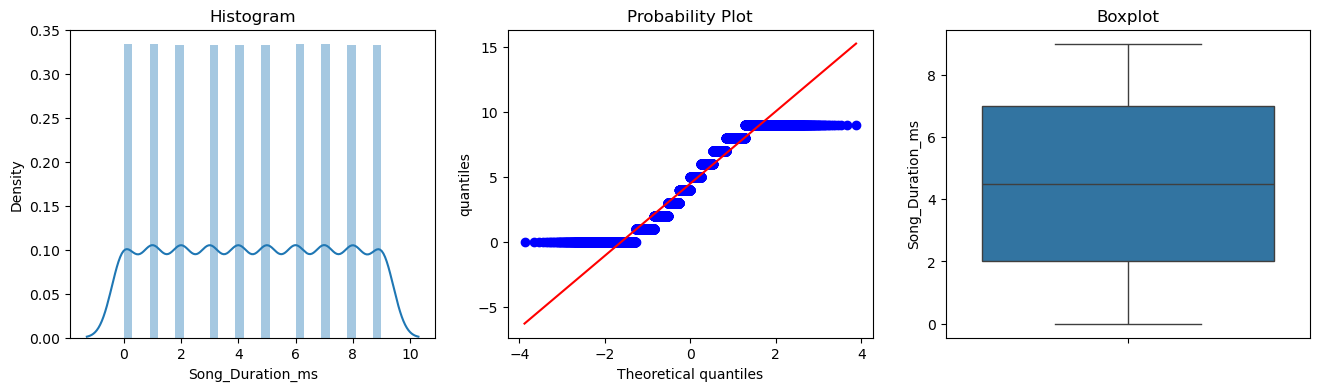

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


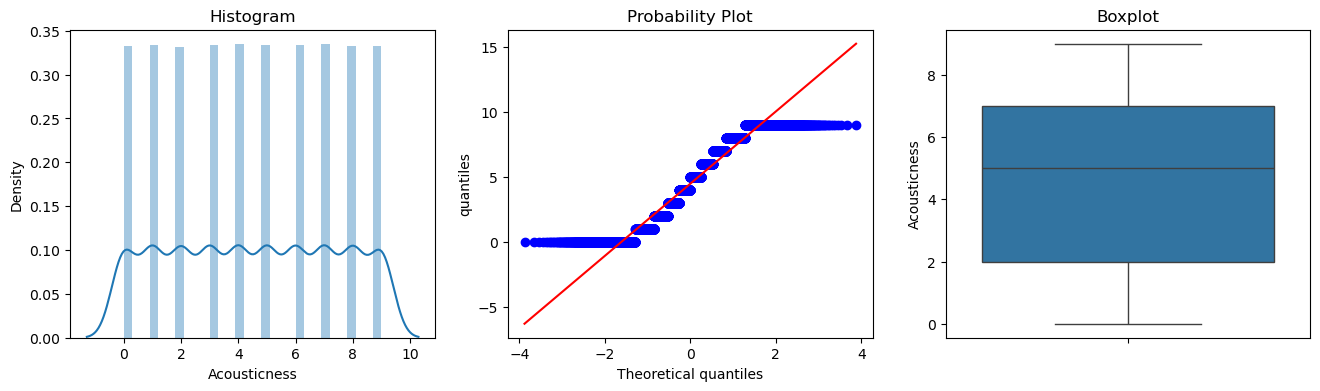

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


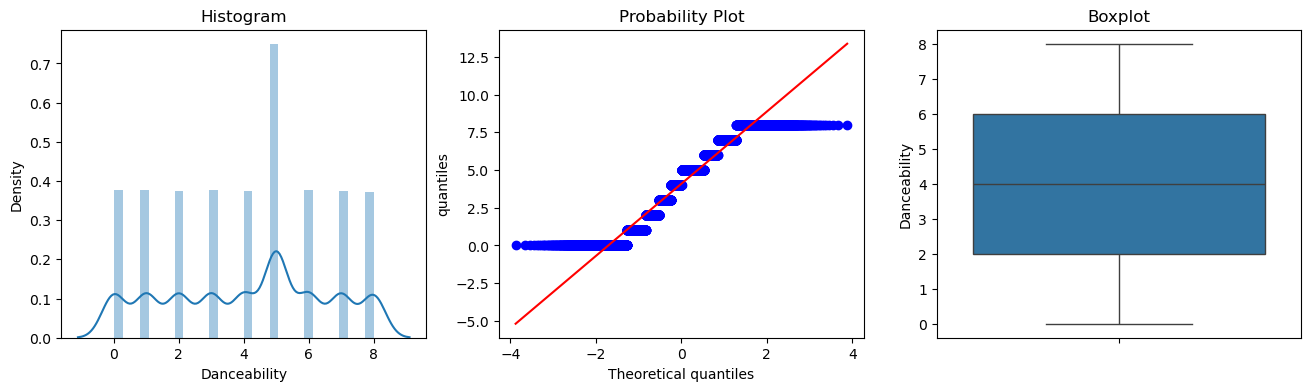

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


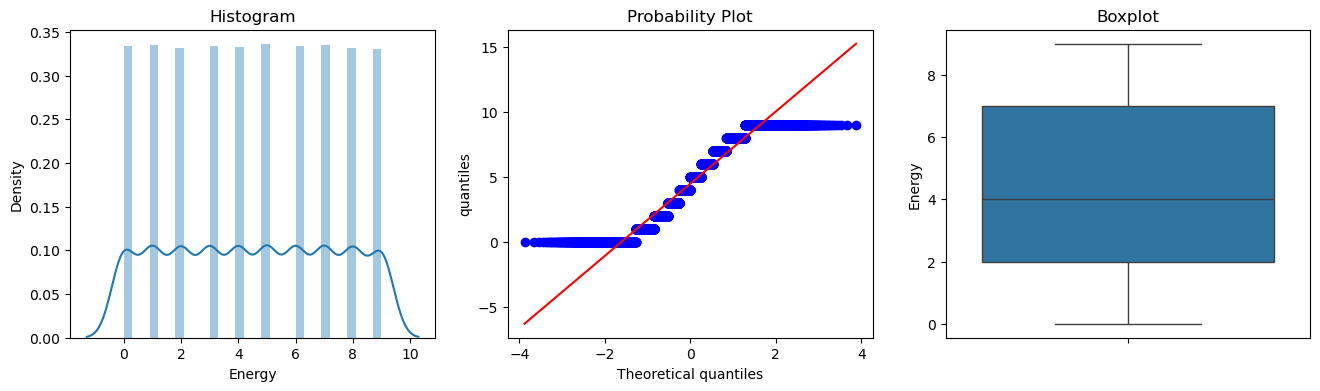

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


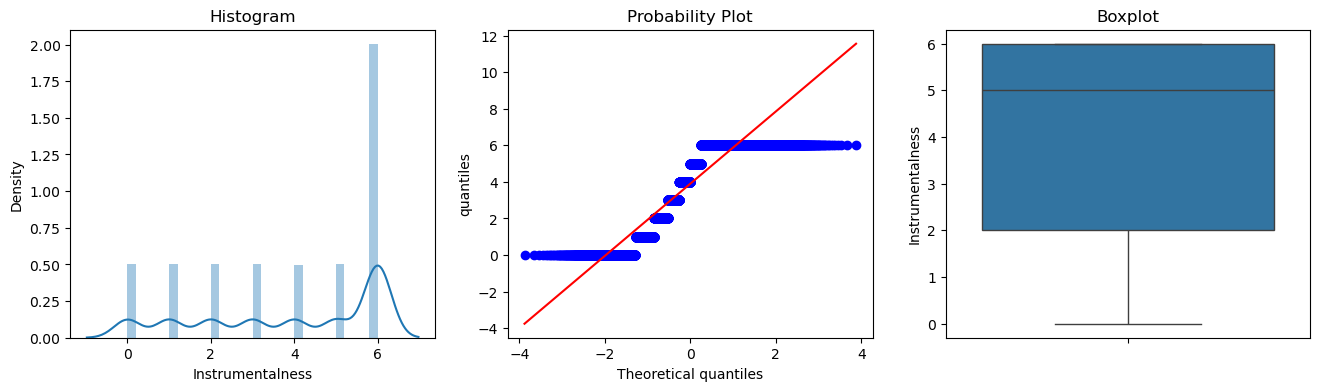

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


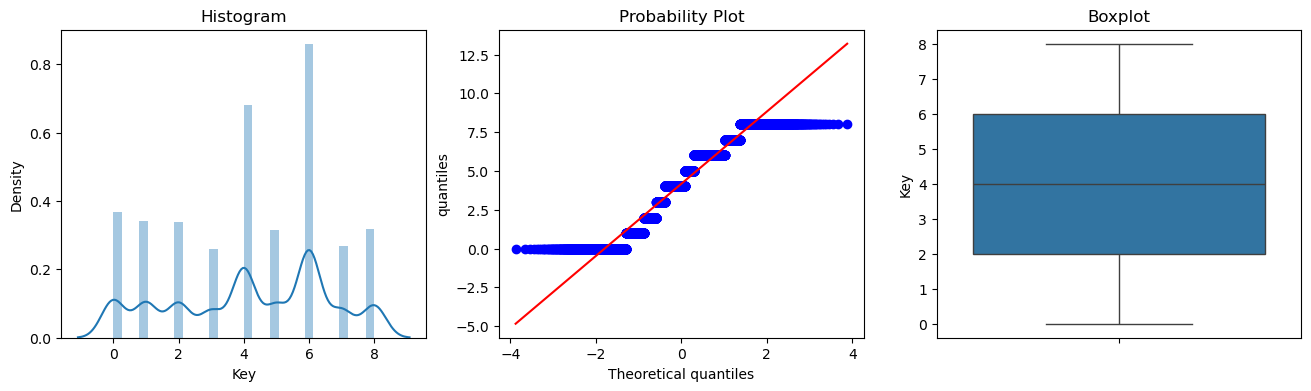

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


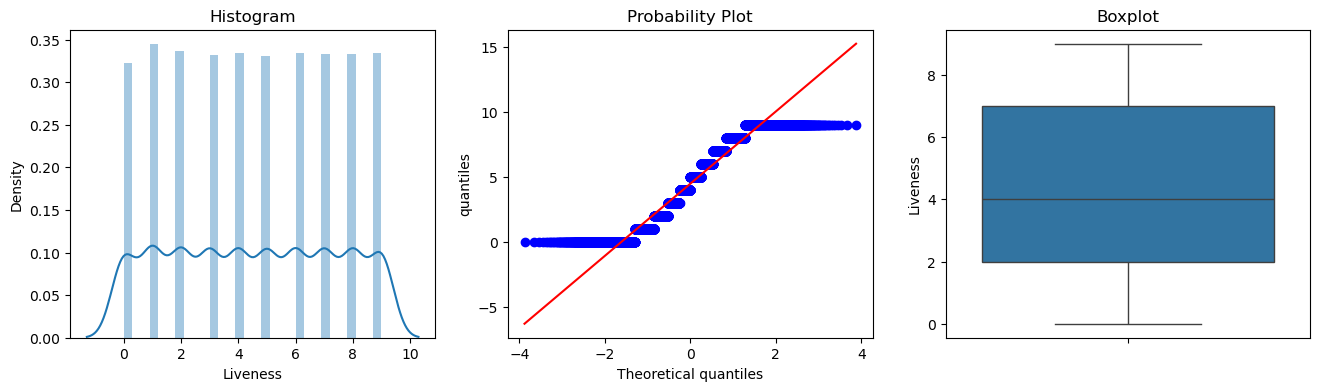

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)
C:\Users\tswr1\anaconda3\Lib\site-packages\seaborn\distributions.py:2496: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  kdeplot(**{axis: a}, ax=ax, color=kde_color, **kde_kws)


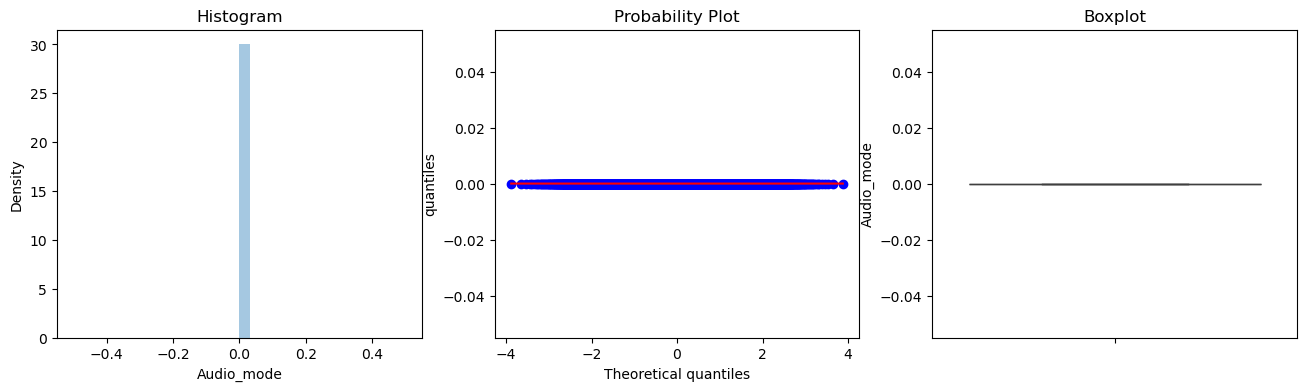

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


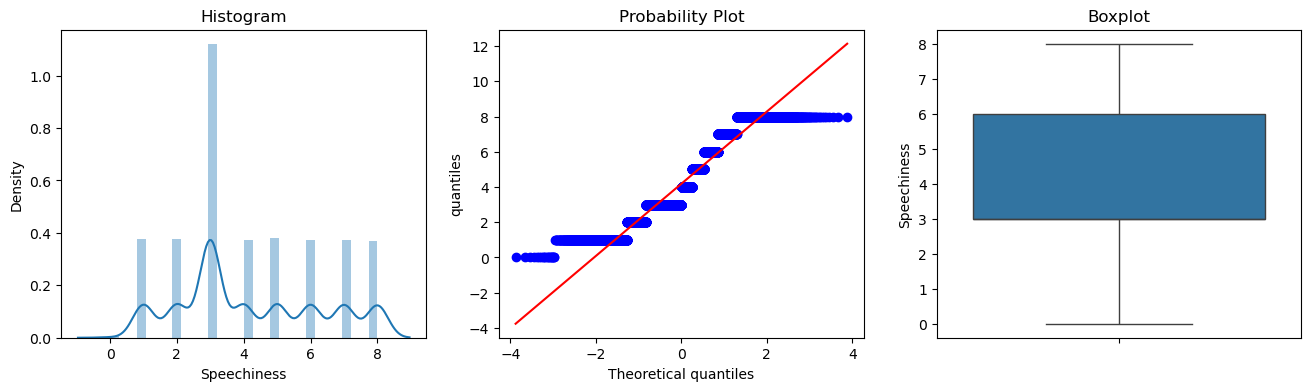

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


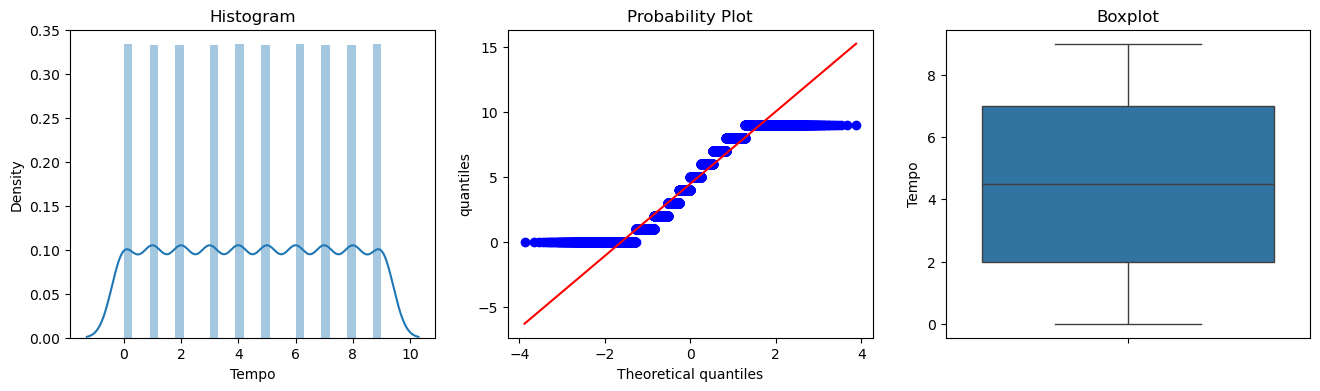

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


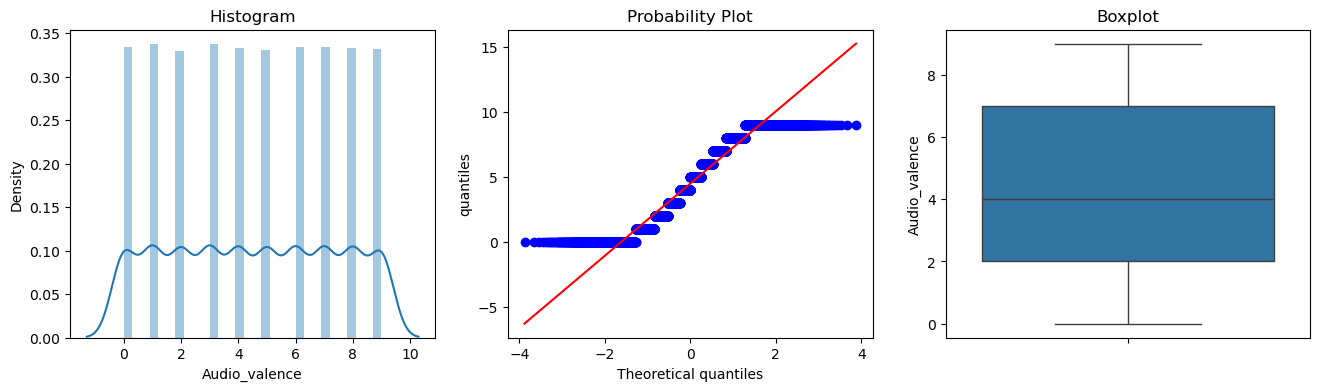

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


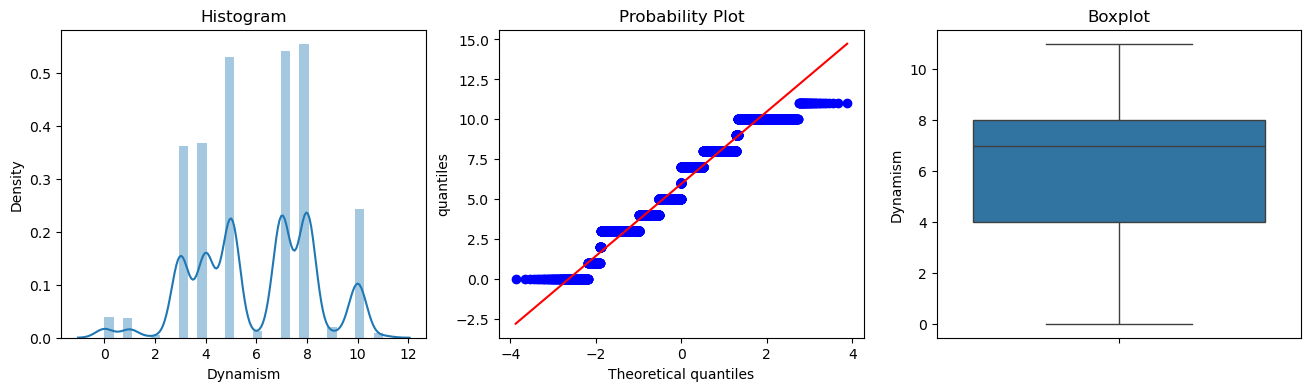

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


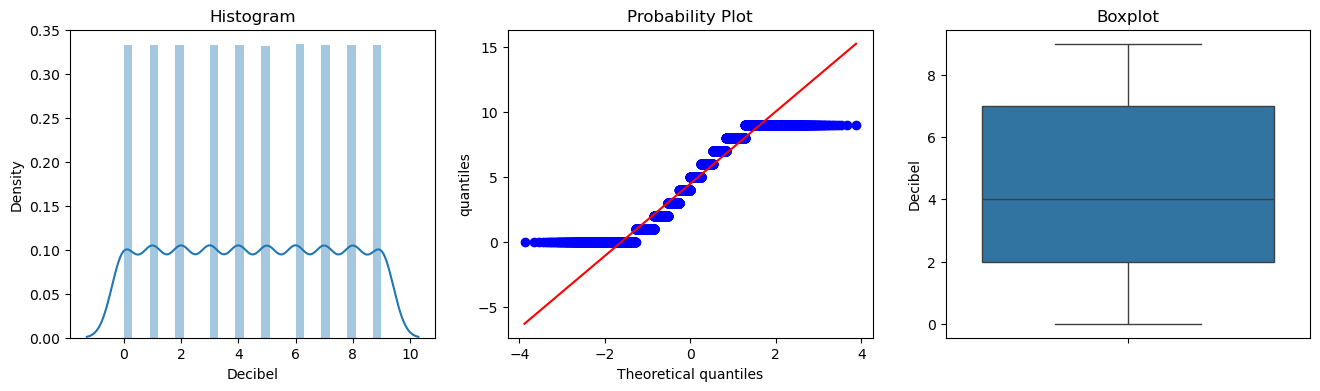

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


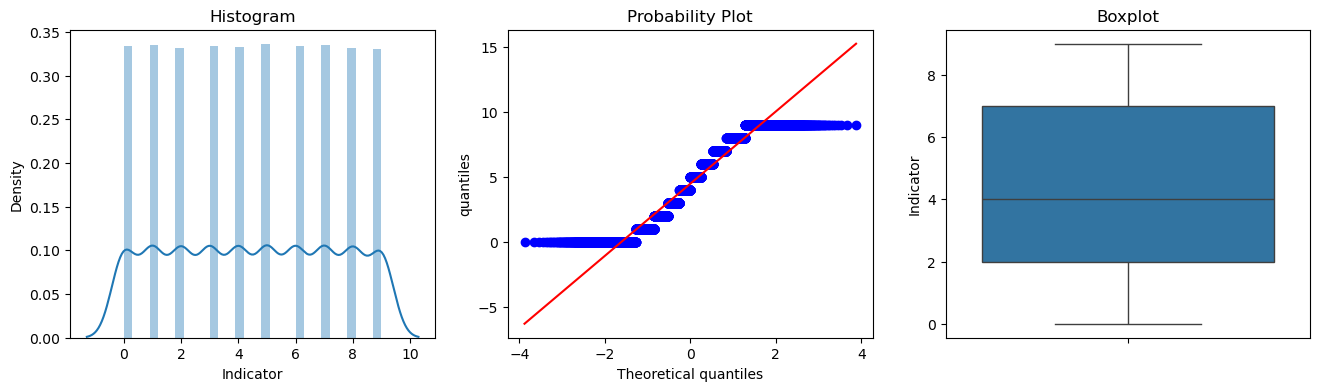

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


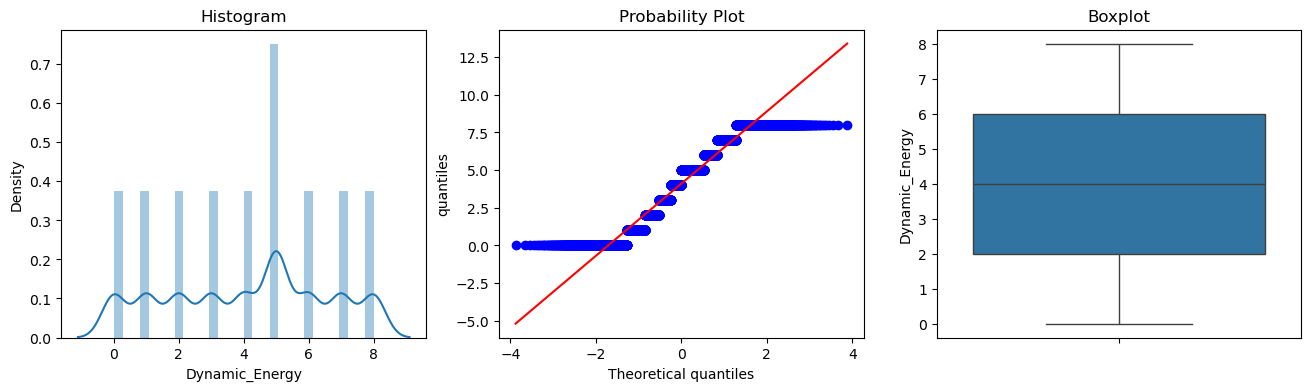

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


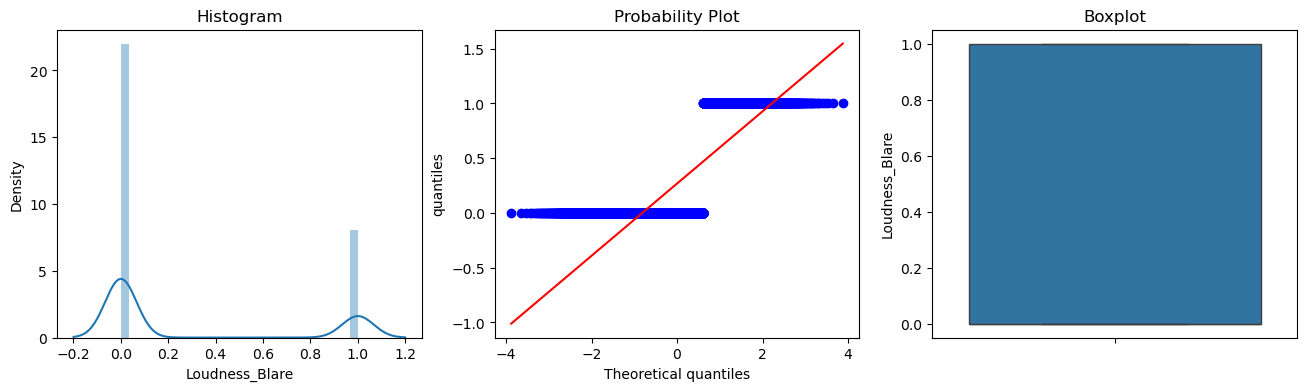

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


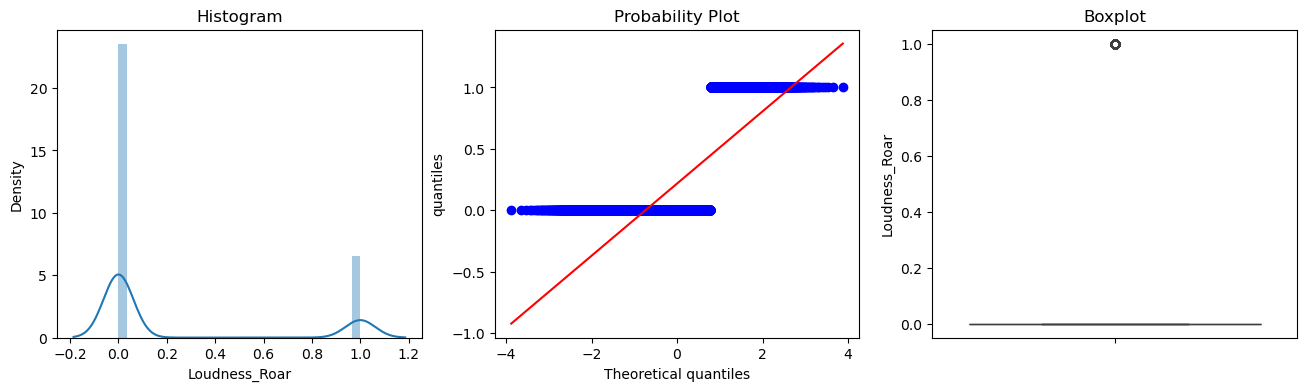

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


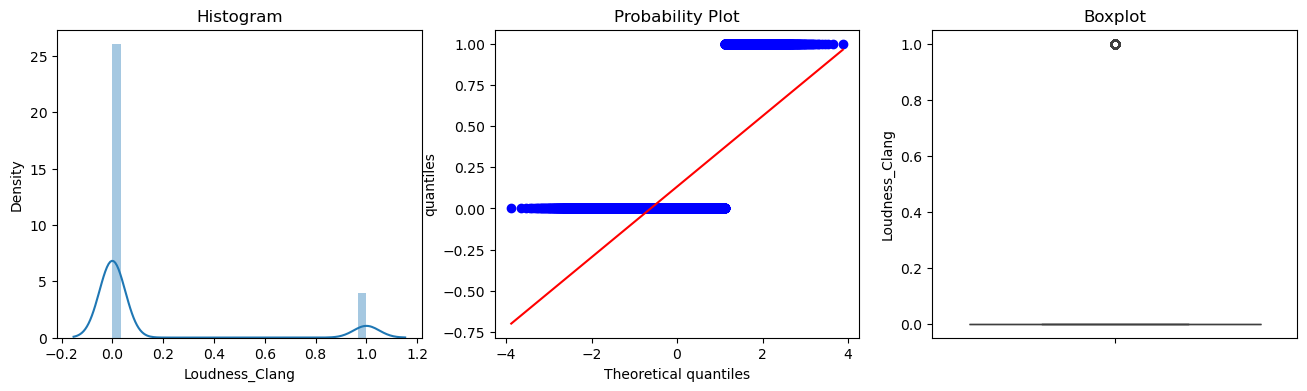

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


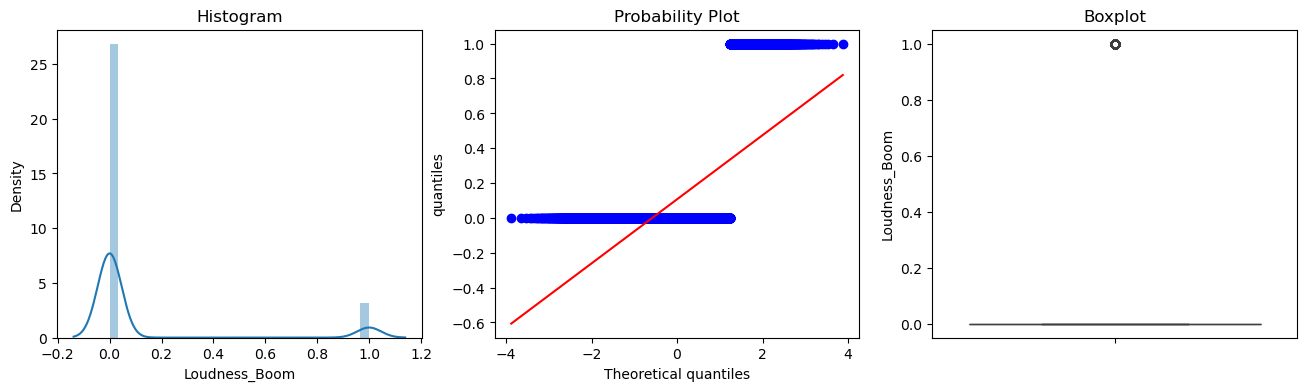

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\190374432.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[variable], bins=30)


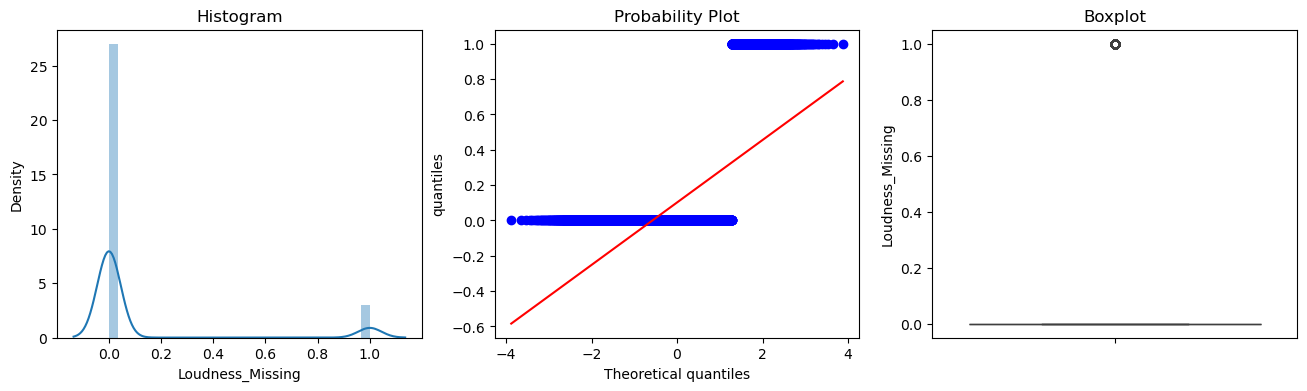

In [144]:
# check original distribution
# Detecting outliers using boxplots
for enc_num_column in X_train_enc[X_train_enc_num_cols]:
    diagnostic_plots(X_train_enc, enc_num_column)

In [145]:
def find_skewed_boundaries(df, variable, distance):

    # Let's calculate the boundaries outside which sit the outliers
    # for skewed distributions

    # distance passed as an argument, gives us the option to
    # estimate 1.5 times or 3 times the IQR to calculate
    # the boundaries.

    IQR = df[variable].quantile(0.75) - df[variable].quantile(0.25)

    lower_boundary = df[variable].quantile(0.25) - (IQR * distance)
    upper_boundary = df[variable].quantile(0.75) + (IQR * distance)

    return upper_boundary, lower_boundary

In [146]:
def find_normal_boundaries(df, variable, distance):

    # calculate the boundaries outside which sit the outliers
    # for a Gaussian distribution

    upper_boundary = df[variable].mean() + df[variable].std() * distance
    lower_boundary = df[variable].mean() - df[variable].std() * distance

    return upper_boundary, lower_boundary

In [147]:
# we find the boudaries for the variable Song_Duration_ms

upper_boundary, lower_boundary = find_boundaries(X_train_enc, 'Song_Duration_ms')
upper_boundary, lower_boundary

(14.5, -5.5)

In [148]:
# let's flag the outliers in the data set
enc_outliers_Song_Duration_ms = np.where(X_train_enc['Song_Duration_ms'] > upper_boundary, True,
                    np.where(X_train_enc['Song_Duration_ms'] < lower_boundary, True, False))
# how many outliers did we find?
enc_outliers_Song_Duration_ms.sum()

0

In [149]:
# we find the boudaries for the variable Danceability

upper_boundary, lower_boundary = find_boundaries(X_train_enc, 'Danceability')
upper_boundary, lower_boundary

(12.0, -4.0)

In [150]:
# let's flag the outliers in the data set
enc_outliers_Danceability = np.where(X_train_enc['Danceability'] > upper_boundary, True,
                    np.where(X_train_enc['Danceability'] < lower_boundary, True, False))
# how many outliers did we find?
enc_outliers_Danceability.sum()

0

In [151]:
# we find the boudaries for the variable Energy

upper_boundary, lower_boundary = find_boundaries(X_train_enc, 'Energy')
upper_boundary, lower_boundary

(14.5, -5.5)

In [152]:
# let's flag the outliers in the data set
enc_outliers_Energy = np.where(X_train_enc['Energy'] > upper_boundary, True,
                    np.where(X_train_enc['Energy'] < lower_boundary, True, False))
# how many outliers did we find?
enc_outliers_Energy.sum()

0

In [153]:
# we find the boudaries for the variable Instrumentalness

upper_boundary, lower_boundary = find_boundaries(X_train_enc, 'Instrumentalness')
upper_boundary, lower_boundary

(12.0, -4.0)

In [154]:
# let's flag the outliers in the data set
enc_outliers_Instrumentalness = np.where(X_train_enc['Instrumentalness'] > upper_boundary, True,
                    np.where(X_train_enc['Instrumentalness'] < lower_boundary, True, False))
# how many outliers did we find?
enc_outliers_Instrumentalness.sum()

0

In [155]:
# we find the boudaries for the variable Liveness

upper_boundary, lower_boundary = find_boundaries(X_train_enc, 'Liveness')
upper_boundary, lower_boundary

(14.5, -5.5)

In [156]:
# let's flag the outliers in the data set
enc_outliers_Liveness = np.where(X_train_enc['Liveness'] > upper_boundary, True,
                    np.where(X_train_enc['Liveness'] < lower_boundary, True, False))
# how many outliers did we find?
enc_outliers_Liveness.sum()

0

In [157]:
# we find the boudaries for the variable Speechiness

upper_boundary, lower_boundary = find_boundaries(X_train_enc, 'Speechiness')
upper_boundary, lower_boundary

(10.5, -1.5)

In [158]:
# let's flag the outliers in the data set
enc_outliers_Speechiness = np.where(X_train_enc['Speechiness'] > upper_boundary, True,
                    np.where(X_train_enc['Speechiness'] < lower_boundary, True, False))
# how many outliers did we find?
enc_outliers_Speechiness.sum()

0

In [159]:
# we find the boudaries for the variable Decibel

upper_boundary, lower_boundary = find_boundaries(X_train_enc, 'Decibel')
upper_boundary, lower_boundary

(14.5, -5.5)

In [160]:
# let's flag the outliers in the data set
enc_outliers_Decibel = np.where(X_train_enc['Decibel'] > upper_boundary, True,
                    np.where(X_train_enc['Decibel'] < lower_boundary, True, False))
# how many outliers did we find?
enc_outliers_Decibel.sum()

0

In [161]:
# we find the boudaries for the variable Indicator

upper_boundary, lower_boundary = find_boundaries(X_train_enc, 'Indicator')
upper_boundary, lower_boundary

(14.5, -5.5)

In [162]:
# let's flag the outliers in the data set
enc_outliers_Indicator = np.where(X_train_enc['Indicator'] > upper_boundary, True,
                    np.where(X_train_enc['Indicator'] < lower_boundary, True, False))
# how many outliers did we find?
enc_outliers_Indicator.sum()

0

In [163]:
# we find the boudaries for the variable Tempo

upper_boundary, lower_boundary = find_boundaries(X_train_enc, 'Tempo')
upper_boundary, lower_boundary

(14.5, -5.5)

In [164]:
# let's flag the outliers in the data set
enc_outliers_Tempo = np.where(X_train_enc['Tempo'] > upper_boundary, True,
                    np.where(X_train_enc['Tempo'] < lower_boundary, True, False))
# how many outliers did we find?
enc_outliers_Tempo.sum()

0

In [165]:
# we find the boudaries for the variable Dynamic_Energy

upper_boundary, lower_boundary = find_boundaries(X_train_enc, 'Dynamic_Energy')
upper_boundary, lower_boundary

(12.0, -4.0)

In [166]:
# let's flag the outliers in the data set
enc_outliers_Dynamic_Energy = np.where(X_train_enc['Dynamic_Energy'] > upper_boundary, True,
                    np.where(X_train_enc['Dynamic_Energy'] < lower_boundary, True, False))
# how many outliers did we find?
enc_outliers_Dynamic_Energy.sum()

0

In [167]:
# we find the boudaries for the variable Loudness_Blare

upper_boundary, lower_boundary = find_boundaries(X_train_enc, 'Loudness_Blare')
upper_boundary, lower_boundary

(2.5, -1.5)

In [168]:
# let's flag the outliers in the data set
enc_outliers_Loudness_Blare = np.where(X_train_enc['Loudness_Blare'] > upper_boundary, True,
                    np.where(X_train_enc['Loudness_Blare'] < lower_boundary, True, False))
# how many outliers did we find?
enc_outliers_Loudness_Blare.sum()

0

In [169]:
# we find the boudaries for the variable Loudness_Roar

upper_boundary, lower_boundary = find_boundaries(X_train_enc, 'Loudness_Roar')
upper_boundary, lower_boundary

(0.0, 0.0)

In [170]:
# let's flag the outliers in the data set
enc_outliers_Loudness_Roar = np.where(X_train_enc['Loudness_Roar'] > upper_boundary, True,
                    np.where(X_train_enc['Loudness_Roar'] < lower_boundary, True, False))
# how many outliers did we find?
enc_outliers_Loudness_Roar.sum()

2858

In [171]:
# we find the boudaries for the variable Loudness_Clang

upper_boundary, lower_boundary = find_boundaries(X_train_enc, 'Loudness_Clang')
upper_boundary, lower_boundary

(0.0, 0.0)

In [172]:
# let's flag the outliers in the data set
enc_outliers_Loudness_Clang = np.where(X_train_enc['Loudness_Clang'] > upper_boundary, True,
                    np.where(X_train_enc['Loudness_Clang'] < lower_boundary, True, False))
# how many outliers did we find?
enc_outliers_Loudness_Clang.sum()

1743

In [173]:
# we find the boudaries for the variable Loudness_Boom

upper_boundary, lower_boundary = find_boundaries(X_train_enc, 'Loudness_Boom')
upper_boundary, lower_boundary

(0.0, 0.0)

In [174]:
# let's flag the outliers in the data set
enc_outliers_Loudness_Boom = np.where(X_train_enc['Loudness_Boom'] > upper_boundary, True,
                    np.where(X_train_enc['Loudness_Boom'] < lower_boundary, True, False))
# how many outliers did we find?
enc_outliers_Loudness_Boom.sum()

1405

In [175]:
# we find the boudaries for the variable Loudness_Missing

upper_boundary, lower_boundary = find_boundaries(X_train_enc, 'Loudness_Missing')
upper_boundary, lower_boundary

(0.0, 0.0)

In [176]:
# let's flag the outliers in the data set
enc_outliers_Loudness_Missing = np.where(X_train_enc['Loudness_Missing'] > upper_boundary, True,
                    np.where(X_train_enc['Loudness_Missing'] < lower_boundary, True, False))
# how many outliers did we find?
enc_outliers_Loudness_Missing.sum()

1330

In [177]:
# limits for Song_Duration_ms

Song_Duration_ms_upper_limit, Song_Duration_ms_lower_limit = find_normal_boundaries(X_train_enc, 'Song_Duration_ms', 1.5)
Song_Duration_ms_upper_limit, Song_Duration_ms_lower_limit

(8.808245717364805, 0.19099578748956514)

In [178]:
# limits for Danceability

Danceability_upper_limit, Danceability_lower_limit = find_normal_boundaries(X_train_enc, 'Danceability', 1.5)
Danceability_upper_limit, Danceability_lower_limit

(7.793975234776794, 0.391856075902818)

In [179]:
# limits for Energy

Energy_upper_limit, Energy_lower_limit = find_normal_boundaries(X_train_enc, 'Energy', 1.5)
Energy_upper_limit, Energy_lower_limit

(8.798471832139313, 0.18908884747233756)

In [180]:
# limits for Instrumentalness

Instrumentalness_upper_limit, Instrumentalness_lower_limit = find_normal_boundaries(X_train_enc, 'Instrumentalness', 1.5)
Instrumentalness_upper_limit, Instrumentalness_lower_limit

(7.1491303244274995, 0.6515371513006563)

In [181]:
# limits for Liveness

Liveness_upper_limit, Liveness_lower_limit = find_normal_boundaries(X_train_enc, 'Liveness', 1.5)
Liveness_upper_limit, Liveness_lower_limit

(8.804674961366104, 0.19820732018729448)

In [182]:
# limits for Speechiness

Speechiness_upper_limit, Speechiness_lower_limit = find_normal_boundaries(X_train_enc, 'Speechiness', 1.5)
Speechiness_upper_limit, Speechiness_lower_limit

(7.391195672015964, 0.9810737454597636)

In [183]:
# limits for Decibel

Decibel_upper_limit, Decibel_lower_limit = find_normal_boundaries(X_train_enc, 'Decibel', 1.5)
Decibel_upper_limit, Decibel_lower_limit

(8.808021458962891, 0.19061324977497218)

In [184]:
# limits for Indicator

Indicator_upper_limit, Indicator_lower_limit = find_normal_boundaries(X_train_enc, 'Indicator', 1.5)
Indicator_upper_limit, Indicator_lower_limit

(8.798471832139313, 0.18908884747233756)

In [185]:
# limits for Tempo

Tempo_upper_limit, Tempo_lower_limit = find_normal_boundaries(X_train_enc, 'Tempo', 1.5)
Tempo_upper_limit, Tempo_lower_limit

(8.808859296614447, 0.19129240241467915)

In [186]:
# limits for Dynamic_Energy

Dynamic_Energy_upper_limit, Dynamic_Energy_lower_limit = find_normal_boundaries(X_train_enc, 'Tempo', 1.5)
Dynamic_Energy_upper_limit, Dynamic_Energy_lower_limit

(8.808859296614447, 0.19129240241467915)

In [187]:
# limits for Loudness_Blare

Loudness_Blare_upper_limit, Loudness_Blare_lower_limit = find_normal_boundaries(X_train_enc, 'Loudness_Blare', 1.5)
Loudness_Blare_upper_limit, Loudness_Blare_lower_limit

(0.932494778524636, -0.3963904095925972)

In [188]:
# limits for Loudness_Roar

Loudness_Roar_upper_limit, Loudness_Roar_lower_limit = find_normal_boundaries(X_train_enc, 'Loudness_Roar', 1.5)
Loudness_Roar_upper_limit, Loudness_Roar_lower_limit

(0.8348764393423129, -0.4013206140995944)

In [189]:
# limits for Loudness_Clang

Loudness_Clang_upper_limit, Loudness_Clang_lower_limit = find_normal_boundaries(X_train_enc, 'Loudness_Clang', 1.5)
Loudness_Clang_upper_limit, Loudness_Clang_lower_limit

(0.6402963763442288, -0.3758849685772384)

In [190]:
# limits for Loudness_Boom

Loudness_Boom_upper_limit, Loudness_Boom_lower_limit = find_normal_boundaries(X_train_enc, 'Loudness_Boom', 1.5)
Loudness_Boom_upper_limit, Loudness_Boom_lower_limit

(0.5694320400946886, -0.35629490417235854)

In [191]:
# limits for Loudness_Missing

Loudness_Missing_upper_limit, Loudness_Missing_lower_limit = find_normal_boundaries(X_train_enc, 'Loudness_Missing', 1.5)
Loudness_Missing_upper_limit, Loudness_Missing_lower_limit

(0.5526513416667258, -0.35089163292886166)

In [192]:
# Now let's replace the outliers by the maximum and minimum limit

X_train_enc['Song_Duration_ms']= np.where(X_train_enc['Song_Duration_ms'] > Song_Duration_ms_upper_limit, Song_Duration_ms_upper_limit,
                       np.where(X_train_enc['Song_Duration_ms'] < Song_Duration_ms_lower_limit, Song_Duration_ms_lower_limit, X_train_enc['Song_Duration_ms']))

In [193]:
# Now let's replace the outliers by the maximum and minimum limit

X_train_enc['Danceability']= np.where(X_train_enc['Danceability'] > Danceability_upper_limit, Danceability_upper_limit,
                       np.where(X_train_enc['Danceability'] < Danceability_lower_limit, Danceability_lower_limit, X_train_enc['Danceability']))

In [194]:
# Now let's replace the outliers by the maximum and minimum limit

X_train_enc['Energy']= np.where(X_train_enc['Energy'] > Energy_upper_limit, Energy_upper_limit,
                       np.where(X_train_enc['Energy'] < Energy_lower_limit, Energy_lower_limit, X_train_enc['Energy']))

In [195]:
# Now let's replace the outliers by the maximum and minimum limit

X_train_enc['Instrumentalness']= np.where(X_train_enc['Instrumentalness'] > Instrumentalness_upper_limit, Instrumentalness_upper_limit,
                       np.where(X_train_enc['Instrumentalness'] < Instrumentalness_lower_limit, Instrumentalness_lower_limit, X_train_enc['Instrumentalness']))

In [196]:
# Now let's replace the outliers by the maximum and minimum limit

X_train_enc['Liveness']= np.where(X_train_enc['Liveness'] > Liveness_upper_limit, Liveness_upper_limit,
                       np.where(X_train_enc['Liveness'] < Liveness_lower_limit, Liveness_lower_limit, X_train_enc['Liveness']))

In [197]:
# Now let's replace the outliers by the maximum and minimum limit

X_train_enc['Speechiness']= np.where(X_train_enc['Speechiness'] > Speechiness_upper_limit, Speechiness_upper_limit,
                       np.where(X_train_enc['Speechiness'] < Speechiness_lower_limit, Speechiness_lower_limit, X_train_enc['Speechiness']))

In [198]:
# Now let's replace the outliers by the maximum and minimum limit

X_train_enc['Decibel']= np.where(X_train_enc['Decibel'] > Decibel_upper_limit, Decibel_upper_limit,
                       np.where(X_train_enc['Decibel'] < Decibel_lower_limit, Decibel_lower_limit, X_train_enc['Decibel']))

In [199]:
# Now let's replace the outliers by the maximum and minimum limit

X_train_enc['Indicator']= np.where(X_train_enc['Indicator'] > Indicator_upper_limit, Indicator_upper_limit,
                       np.where(X_train_enc['Indicator'] < Indicator_lower_limit, Indicator_lower_limit, X_train_enc['Indicator']))

In [200]:
# Now let's replace the outliers by the maximum and minimum limit

X_train_enc['Tempo']= np.where(X_train_enc['Tempo'] > Tempo_upper_limit, Tempo_upper_limit,
                       np.where(X_train_enc['Tempo'] < Tempo_lower_limit, Tempo_lower_limit, X_train_enc['Tempo']))

In [201]:
# Now let's replace the outliers by the maximum and minimum limit

X_train_enc['Dynamic_Energy']= np.where(X_train_enc['Dynamic_Energy'] > Dynamic_Energy_upper_limit, Dynamic_Energy_upper_limit,
                       np.where(X_train_enc['Dynamic_Energy'] < Dynamic_Energy_lower_limit, Dynamic_Energy_lower_limit, X_train_enc['Dynamic_Energy']))

In [202]:
# Now let's replace the outliers by the maximum and minimum limit

X_train_enc['Loudness_Blare']= np.where(X_train_enc['Loudness_Blare'] > Loudness_Blare_upper_limit, Loudness_Blare_upper_limit,
                       np.where(X_train_enc['Loudness_Blare'] < Loudness_Blare_lower_limit, Loudness_Blare_lower_limit, X_train_enc['Loudness_Blare']))

In [203]:
# Now let's replace the outliers by the maximum and minimum limit

X_train_enc['Loudness_Roar']= np.where(X_train_enc['Loudness_Roar'] > Loudness_Roar_upper_limit, Loudness_Roar_upper_limit,
                       np.where(X_train_enc['Loudness_Roar'] < Loudness_Roar_lower_limit, Loudness_Roar_lower_limit, X_train_enc['Loudness_Roar']))

In [204]:
# Now let's replace the outliers by the maximum and minimum limit

X_train_enc['Loudness_Clang']= np.where(X_train_enc['Loudness_Clang'] > Loudness_Clang_upper_limit, Loudness_Clang_upper_limit,
                       np.where(X_train_enc['Loudness_Clang'] < Loudness_Clang_lower_limit, Loudness_Clang_lower_limit, X_train_enc['Loudness_Clang']))

In [205]:
# Now let's replace the outliers by the maximum and minimum limit

X_train_enc['Loudness_Boom']= np.where(X_train_enc['Loudness_Boom'] > Loudness_Boom_upper_limit, Loudness_Boom_upper_limit,
                       np.where(X_train_enc['Loudness_Boom'] < Loudness_Boom_lower_limit, Loudness_Boom_lower_limit, X_train_enc['Loudness_Boom']))

In [206]:
# Now let's replace the outliers by the maximum and minimum limit

X_train_enc['Loudness_Missing']= np.where(X_train_enc['Loudness_Missing'] > Loudness_Missing_upper_limit, Loudness_Missing_upper_limit,
                       np.where(X_train_enc['Loudness_Missing'] < Loudness_Missing_lower_limit, Loudness_Missing_lower_limit, X_train_enc['Loudness_Missing']

SyntaxError: incomplete input (1319358666.py, line 4)

In [207]:
# Summary display of outliers
print(f"Song_Duration_ms: {enc_outliers_Song_Duration_ms.sum()}\n")
print(f"Danceability: {enc_outliers_Danceability.sum()}\n")
print(f"Energy: {enc_outliers_Energy.sum()}\n")
print(f"Instrumentalness: {enc_outliers_Instrumentalness.sum()}\n")
print(f"Liveness: {enc_outliers_Liveness.sum()}\n")
print(f"Speechiness: {enc_outliers_Speechiness.sum()}\n")
print(f"Decibel: {enc_outliers_Decibel.sum()}\n")
print(f"Indicator: {enc_outliers_Indicator.sum()}\n")
print(f"Tempo: {enc_outliers_Tempo.sum()}\n")
print(f"Dynamic_Energy: {enc_outliers_Dynamic_Energy.sum()}\n")
print(f"Loudness_Blare: {enc_outliers_Loudness_Blare.sum()}\n")
print(f"Loudness_Roar: {enc_outliers_Loudness_Roar.sum()}\n")
print(f"Loudness_Clang: {enc_outliers_Loudness_Clang.sum()}\n")
print(f"Loudness_Boom: {enc_outliers_Loudness_Boom.sum()}\n")
print(f"Loudness_Missing: {enc_outliers_Loudness_Missing.sum()}\n")

Song_Duration_ms: 0

Danceability: 0

Energy: 0

Instrumentalness: 0

Liveness: 0

Speechiness: 0

Decibel: 0

Indicator: 0

Tempo: 0

Dynamic_Energy: 0

Loudness_Blare: 0

Loudness_Roar: 2858

Loudness_Clang: 1743

Loudness_Boom: 1405

Loudness_Missing: 1330



In [208]:
# create the capper

windsorizer = Winsorizer(capping_method='gaussian', # choose iqr for skewed or gaussian for normal
                          tail='both', # cap left, right or both tails 
                          fold=3,
                          variables=['Song_Duration_ms', 'Energy', 'Instrumentalness',
                                        'Tempo','Decibel','Indicator',
                                         'Liveness','Danceability','Speechiness','Dynamic_Energy'])

windsorizer.fit(X_train_enc)

Winsorizer(tail='both',
           variables=['Song_Duration_ms', 'Energy', 'Instrumentalness', 'Tempo',
                      'Decibel', 'Indicator', 'Liveness', 'Danceability',
                      'Speechiness', 'Dynamic_Energy'])

In [209]:
X_train_capping = windsorizer.transform(X_train_enc)
X_test_capping = windsorizer.transform(X_test_enc)

In [210]:
# we can inspect the minimum caps for each variable
windsorizer.left_tail_caps_

{'Song_Duration_ms': -3.939444333979382,
 'Energy': -3.935177429822706,
 'Instrumentalness': -2.1978490493108787,
 'Tempo': -3.9393137640334173,
 'Decibel': -3.9399889956054315,
 'Indicator': -3.935177429822706,
 'Liveness': -3.9249521343759044,
 'Danceability': -3.003288060511802,
 'Speechiness': -1.968877161566323,
 'Dynamic_Energy': -3.190689670372991}

In [211]:
# we can inspect the maximum caps for each variable
windsorizer.right_tail_caps_

{'Song_Duration_ms': 12.938563159705346,
 'Energy': 12.920702026449604,
 'Instrumentalness': 10.12878442027785,
 'Tempo': 12.939495816675926,
 'Decibel': 12.938350521822851,
 'Indicator': 12.920702026449604,
 'Liveness': 12.927058518211169,
 'Danceability': 11.227128019055517,
 'Speechiness': 10.224153959633366,
 'Dynamic_Energy': 11.427691290334302}

### Step 8: Feature Engineer

In [212]:
# standardisation: with the StandardScaler from sklearn

# set up the scaler
scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train_capping)

# transform train and test sets
X_train_scaled = scaler.transform(X_train_capping)
X_test_scaled = scaler.transform(X_test_capping)

In [213]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_capping.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_capping.columns)

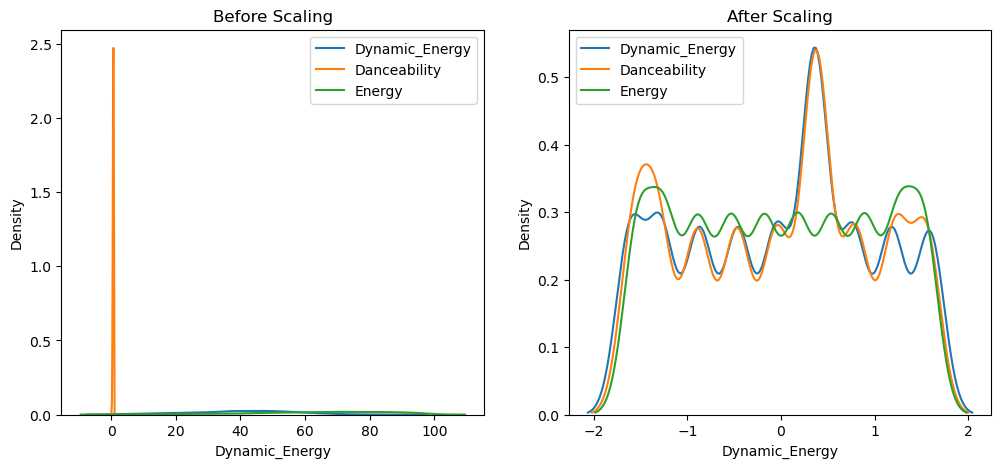

In [214]:
# let's compare the variable distributions before and after scaling

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Dynamic_Energy'], ax=ax1, label ='Dynamic_Energy')
sns.kdeplot(X_train['Danceability'], ax=ax1, label ='Danceability')
sns.kdeplot(X_train['Energy'], ax=ax1, label ='Energy')
ax1.legend()

# after scaling
ax2.set_title('After Scaling')
sns.kdeplot(X_train_scaled['Dynamic_Energy'], ax=ax2, label ='Dynamic_Energy')
sns.kdeplot(X_train_scaled['Danceability'], ax=ax2, label ='Danceability')
sns.kdeplot(X_train_scaled['Energy'], ax=ax2, label ='Energy')
ax2.legend()
plt.show()

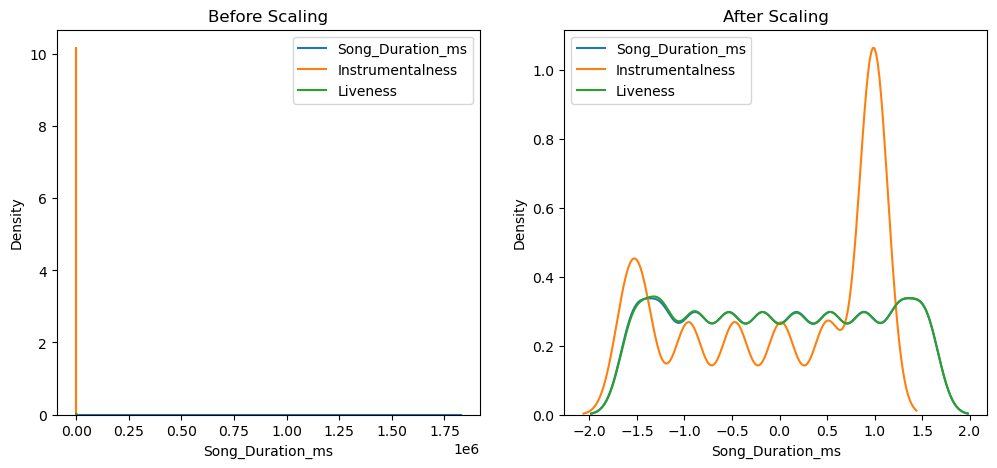

In [215]:
# let's compare the variable distributions before and after scaling

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Song_Duration_ms'], ax=ax1, label ='Song_Duration_ms')
sns.kdeplot(X_train['Instrumentalness'], ax=ax1, label ='Instrumentalness')
sns.kdeplot(X_train['Liveness'], ax=ax1, label ='Liveness')
ax1.legend()

# after scaling
ax2.set_title('After Scaling')
sns.kdeplot(X_train_scaled['Song_Duration_ms'], ax=ax2, label ='Song_Duration_ms')
sns.kdeplot(X_train_scaled['Instrumentalness'], ax=ax2, label ='Instrumentalness')
sns.kdeplot(X_train_scaled['Liveness'], ax=ax2, label ='Liveness')
ax2.legend()
plt.show()

C:\Users\tswr1\AppData\Local\Temp\ipykernel_30124\5874808.py:15: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(X_train_scaled['Audio_mode'], ax=ax2, label ='Audio_mode')


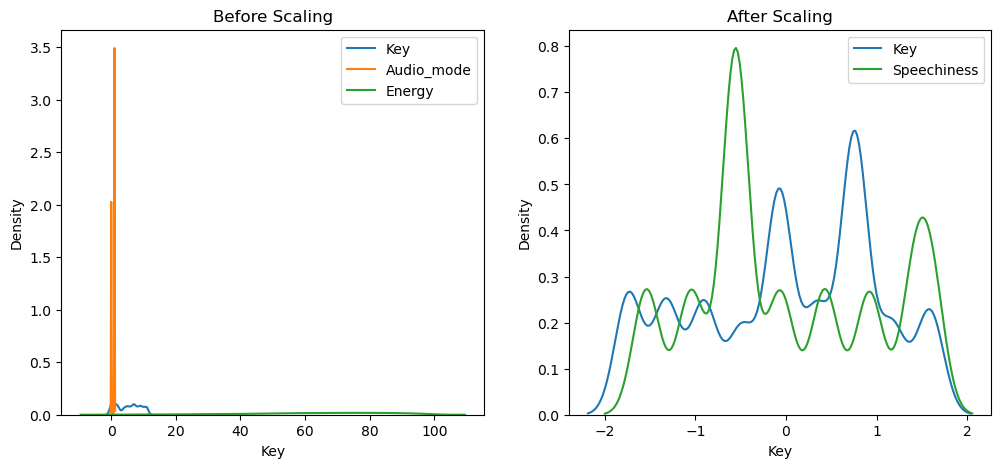

In [216]:
# let's compare the variable distributions before and after scaling

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Key'], ax=ax1, label ='Key')
sns.kdeplot(X_train['Audio_mode'], ax=ax1, label ='Audio_mode')
sns.kdeplot(X_train['Energy'], ax=ax1, label ='Energy')
ax1.legend()

# after scaling
ax2.set_title('After Scaling')
sns.kdeplot(X_train_scaled['Key'], ax=ax2, label ='Key')
sns.kdeplot(X_train_scaled['Audio_mode'], ax=ax2, label ='Audio_mode')
sns.kdeplot(X_train_scaled['Speechiness'], ax=ax2, label ='Speechiness')
ax2.legend()
plt.show()

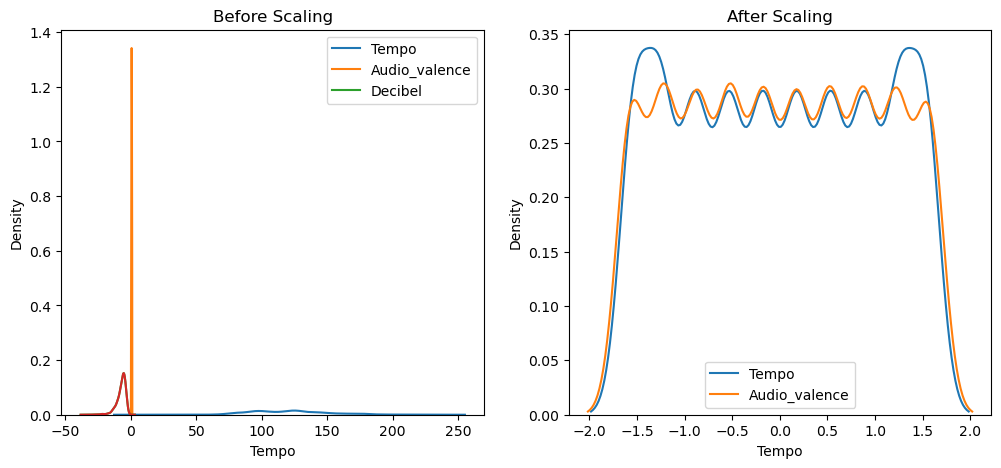

In [217]:
# let's compare the variable distributions before and after scaling

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Tempo'], ax=ax1, label ='Tempo')
sns.kdeplot(X_train['Audio_valence'], ax=ax1, label ='Audio_valence')
sns.kdeplot(X_train['Decibel'], ax=ax1, label ='Decibel')
ax1.legend()

# after scaling
ax2.set_title('After Scaling')
sns.kdeplot(X_train_scaled['Tempo'], ax=ax2, label ='Tempo')
sns.kdeplot(X_train_scaled['Audio_valence'], ax=ax2, label ='Audio_valence')
sns.kdeplot(X_train['Decibel'], ax=ax1, label ='Decibel')
ax2.legend()
plt.show()

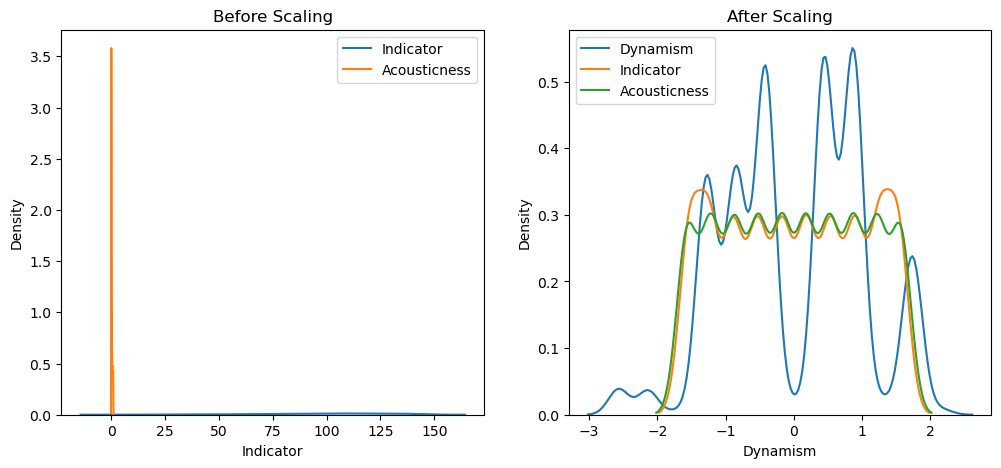

In [218]:
# let's compare the variable distributions before and after scaling

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Indicator'], ax=ax1, label ='Indicator')
sns.kdeplot(X_train['Acousticness'], ax=ax1, label ='Acousticness')
ax1.legend()

# after scaling
ax2.set_title('After Scaling')
sns.kdeplot(X_train_scaled['Dynamism'], ax=ax2, label ='Dynamism')
sns.kdeplot(X_train_scaled['Indicator'], ax=ax2, label ='Indicator')
sns.kdeplot(X_train_scaled['Acousticness'], ax=ax2, label ='Acousticness')
ax2.legend()
plt.show()

In [219]:
# set up the PCA

pca = PCA()

In [220]:
# show shape of X_train_scaled (X_train after StandardScaler)
print(X_train_scaled.shape)

(13184, 20)


In [221]:
# train the PCA
pca.fit(X_train_scaled)

PCA()

In [222]:
# create the principal components

X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [223]:
# show the variance explanation for each Principal Component
print(len(pca.explained_variance_ratio_))
print(pca.explained_variance_ratio_)

20
[2.46215433e-01 8.27123516e-02 6.89605634e-02 6.61746719e-02
 6.12495732e-02 5.86690236e-02 5.33688244e-02 5.15273351e-02
 5.04130938e-02 4.90481198e-02 4.78751358e-02 4.42767873e-02
 4.07149760e-02 3.08298221e-02 1.83664979e-02 1.56613110e-02
 1.08041998e-02 3.13228026e-03 4.18405738e-33 2.86930174e-35]


Text(0, 0.5, 'Percentage of Variance Explained')

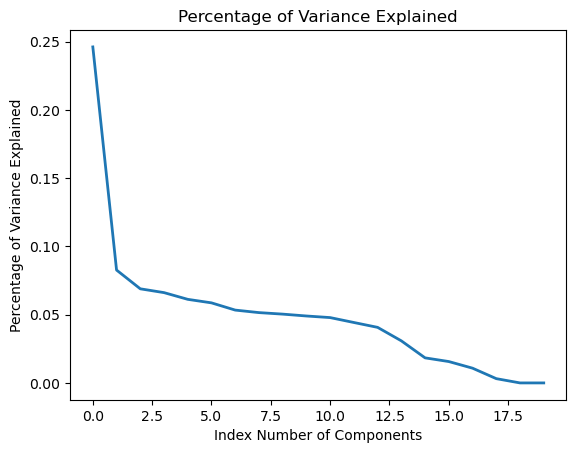

In [224]:
# determine the number of informative components

# the number of components is determined by the change
# in the decay in the percentage of variance explained
# by each component

plt.plot(pca.explained_variance_ratio_, linewidth=2)
plt.title('Percentage of Variance Explained')
plt.xlabel('Index Number of Components')
plt.ylabel('Percentage of Variance Explained')

In [225]:
X_train_scaled

,Song_Duration_ms,Acousticness,Danceability,Energy,Instrumentalness,Key,Liveness,Audio_mode,Speechiness,Tempo,Audio_valence,Dynamism,Decibel,Indicator,Dynamic_Energy,Loudness_Blare,Loudness_Roar,Loudness_Clang,Loudness_Boom,Loudness_Missing
0,1.531704,-0.174460,0.796075,0.180556,0.990310,-0.074045,1.245767,0.0,0.921360,-0.177770,-0.520122,0.871894,-0.177451,0.180556,1.182689,-0.605159,1.900794,-0.390316,-0.345369,-0.33496
1,0.177903,1.218892,0.374443,-0.531362,0.990310,0.757121,1.532264,0.0,1.605946,1.531661,-1.564379,-0.848793,0.889004,-0.531362,0.361804,1.652458,-0.526096,-0.390316,-0.345369,-0.33496
2,-1.531661,-1.219473,-0.047189,-0.887321,-0.956693,-0.905210,-0.534436,0.0,1.413444,-1.244196,-0.172036,-1.278965,-0.888422,-0.887321,-0.869522,-0.605159,-0.526096,2.562025,-0.345369,-0.33496
3,-1.531661,-1.567811,1.552473,-1.531931,-1.613059,-1.736376,-1.531988,0.0,-0.554893,-1.531672,0.872221,-2.139308,-1.531632,-1.531931,-1.611892,-0.605159,-0.526096,-0.390316,-0.345369,-0.33496
4,0.888887,-0.174460,-0.890453,-0.531362,0.990310,0.757121,1.245767,0.0,-0.062809,-1.244196,-0.520122,-0.848793,-0.177451,-0.531362,-0.869522,-0.605159,1.900794,-0.390316,-0.345369,-0.33496
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13179,0.177903,0.522216,1.217707,-0.531362,-0.956693,0.757121,-0.534436,0.0,0.921360,0.533181,0.872221,-0.848793,-1.243907,-0.531362,0.772247,-0.605159,-0.526096,-0.390316,-0.345369,-0.33496
13180,1.244379,-0.174460,0.374443,0.536515,0.990310,-1.736376,-0.178395,0.0,-0.554893,0.533181,-0.520122,0.441722,0.533519,0.536515,0.361804,1.652458,-0.526096,-0.390316,-0.345369,-0.33496
13181,1.531704,-0.174460,1.217707,-0.531362,0.990310,0.757121,1.532264,0.0,0.429276,-1.531672,1.568392,-0.848793,0.889004,-0.531362,0.772247,1.652458,-0.526096,-0.390316,-0.345369,-0.33496
13182,0.177903,0.870554,0.796075,0.180556,-1.613059,-1.736376,-1.531988,0.0,-0.062809,-0.888721,-1.564379,-0.418621,-0.888422,0.180556,0.772247,-0.605159,-0.526096,2.562025,-0.345369,-0.33496


In [226]:
X_train_pca

array([[-1.05090086e+00, -1.53474770e+00,  5.11454699e-03, ...,
        -5.97011988e-02,  1.81289937e-16, -3.17384833e-16],
       [-7.75860925e-01, -5.23483705e-01,  2.52821045e+00, ...,
         2.91707966e-02,  1.10052168e-16,  2.07566497e-16],
       [ 3.01288217e+00,  2.77456105e-02, -1.08350837e+00, ...,
        -5.01870953e-02, -6.98811639e-16,  3.94459937e-16],
       ...,
       [-9.15784031e-01, -1.63200092e+00,  2.10325260e+00, ...,
         3.50160839e-02, -1.89803481e-16,  8.48225751e-18],
       [ 1.09147927e+00, -1.94642990e-01, -8.59537677e-01, ...,
        -7.20942277e-02, -5.13442484e-16,  2.40914402e-16],
       [ 1.67698707e+00,  1.30072274e+00, -5.21813935e-01, ...,
        -6.11904248e-02, -5.99027103e-18, -2.15028972e-16]])

### Step 9: Linear Regression Modelling

Linear regression is defined as a machine learning model in which the model finds the best fit linear line between the independent and dependent variables in which the aim is to find the best fit linear line and the optimal values of intercept and coefficients such that errors are minimized. For the purpose of this analysis, the goal is to use the X variables e.g. columns other than item outlet sales,to predict the item outlet sales (y variable, or target variable).
### Building and Evaluating the Model
In order to evaluate the model performance of a linear regression model, a range of measures can be used, but in this ASG1 we will focus on only 2:

- Mean Square Error (MSE): The MSE is the variance of the residuals, that is, the squared differences between prediction and actual observation. Lower values of MSE indicate better fit and model performance.
- R-Square: R-square represents the percentage of the response variable variation that is explained by a linear model. The closer to 1.0 the value of R-square, the more indicative of a better fit and model performance.

In [227]:
# assign your fully cleaned and transformed data contained within your versions of 
# X_train_student_final_premodel_version, X_test_student_final_premodel_version,
# y_train_student_final_premodel_version and y_test_student_final_premodel_version into
# the prepared variables below, for a simple linear regression model

In [228]:
X_train_final = X_train_pca
X_test_final = X_test_pca

y_train_final = y_train
y_test_final = y_test

In [229]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [230]:
# Build Linear Regression Model
model_linear_regression = LinearRegression()
model_linear_regression.fit(X_train_final, y_train_final)

# Evaluate the Linear Regression Model using Mean Square Error (MSE)
# The lower MSE, the better the model performance
print('train_mse:', mean_squared_error(y_train_final, model_linear_regression.predict(X_train_final)), 
      '\n test_mse:', mean_squared_error(y_test_final, model_linear_regression.predict(X_test_final)))

# Evaluate the Linear Regression Model using R-Square
# The closer the r-square value to 1, the better the model performance
print('train_r-sq:', r2_score(y_train_final, model_linear_regression.predict(X_train_final)), 
      '\n test_r-sq:', r2_score(y_test_final, model_linear_regression.predict(X_test_final)))

train_mse: 115.59562910543201 
 test_mse: 117.63845357922045
train_r-sq: 0.4048103629585814 
 test_r-sq: 0.39810879444808844


### Report Section

#### Introduction with Value Based Problem Statement

In today's music industry, understanding what makes a song popular is crucial. At XYZ Music Records Company, my role as a data analyst revolves around delving deep into song characteristics to uncover their impact on popularity. This analysis isn't just about numbers; it's about empowering our team to predict which songs will resonate most with audiences. My stakeholders, including the marketing and production department teams, rely on these insights to fine-tune our promotional efforts and optimize production strategies, ensuring they're laser-focused on maximizing a song's success. This not only boosts our marketing efficiency but also strengthens our market position and profitability. Ultimately, knowing which attributes drive popularity helps artists and producers craft music that truly connects with listeners, giving us a competitive edge in the industry.

#### Exploratory Data Analysis

##### Insights and Conclusion 

In exploratory data analysis, I used data.shape, data.dtypes, and data.isnull().sum() to check the details of the dataset, including the presence and number of null values and the variables they belong to. Using data.shape, I confirmed the number of rows and columns in the dataset before proceeding with preprocessing, train-test splitting, transformations, and modeling. I also identified the numerical and categorical variables to avoid repeatedly checking data.dtypes or data.info. I created a correlation table and a Pearson correlation features chart to summarize the linear relationships between features. The correlation heatmap visualizes the correlation coefficients among various variables in the dataset, including weather factors, user types renting bikes, and the total number of bikes rented.

Correlation, a statistical measure indicating how two variables change together, ranges from -1 to 1:

1 signifies a perfect positive correlation.
-1 implies a perfect negative correlation.
0 denotes no correlation.
The heatmap represents the strength and direction of correlation relationships through color intensity and values in each cell.

The feature with the strongest correlation with the target feature, song_popularity, has a correlation of 0.51, showing a positive correlation between Decibel and Song_Popularity. This means that as the Decibel value increases, the Song_Popularity value also increases, indicating a linear correlation.

I created multiple histogram distributions for each feature with 30 bins each to provide a top-level overview of the shape and skew of the data. Some plots are symmetrical, while others show right-skewed or left-skewed distributions.


Numerical Data Analysis

Distribution of Song_Popularity:
The histogram shows a bell-shaped distribution of song popularity.
Central Tendency: Most songs have a mid-range popularity.
Spread: The popularity values are symmetrically spread, with fewer songs at the extremes.
This indicates a normal distribution, suggesting that most songs have moderate popularity.
Distribution of Danceability (Box Plot):
Central Value: The data is concentrated around a high danceability score of 0.8.
Variability: Most data points are close to this central value.
This suggests that the analyzed songs are generally highly danceable.

Distribution of Tempo:
First Peak: Around 75 BPM, common for certain music genres.
Second Peak: Just above 125 BPM, indicating a preference for faster tempos in other genres.
Spread: Frequencies taper off from these peaks.
This helps understand common tempos in songs.

Distribution of Energy:
Shape: Bell-shaped, typical of a normal distribution.
Center: Most energy values are around the middle range.
Spread: Fewer occurrences at the low and high ends.
This indicates a symmetrical distribution around the mean.

Distribution of Acousticness:
Highest Frequency: At the lowest range of acousticness (close to 0).
Decreasing Frequency: Fewer tracks with higher acousticness.
This suggests more tracks have electronic or amplified sounds compared to purely acoustic tracks.


Bivariate Analysis

Danceability and Song_Popularity:
Data Distribution: Blue dots represent individual songs.
Danceability Range: 0 to 1.0.
Popularity Range: 0 to 100.
This visualizes the distribution of songs across these metrics and potential trends.

Tempo and Song_Popularity:
Data Distribution: Blue dots represent individual songs.
Tempo Range: 0 to 250 BPM.
Popularity Range: 0 to 100.
No clear trend suggests no strong correlation between tempo and song popularity.

Energy and Song_Popularity:
Data Distribution: Densely clustered points at higher ends of both axes.
Energy Range: 0 to 100.
Popularity Range: 0 to 100.
Clustering suggests a potential correlation between high energy levels and popularity.

Acousticness and Song_Popularity:
Data Distribution: Points scattered in the lower range of acousticness.
Acousticness Range: 0.0 to 1.0.
Popularity Range: 0 to 100.
No clear trend suggests no strong correlation between acousticness and popularity.

Decibel and Song_Popularity:
Data Distribution: Points plotted across the graph with a positive trend line.
Decibel Range: -40 to 0.
Popularity Range: 0 to 100.
The trend line indicates that higher decibel levels are associated with higher popularity.


Trends Analysis

Danceability for Popular vs Unpopular Songs:
Data Distribution: Two overlapping density curves.
Danceability Range: 0.0 to 1.0.
Density Range: 0 to 2.5.
Popular songs tend to have higher danceability scores.

Acousticness for Popular and Unpopular Songs:
Data Distribution: Two overlapping density curves.
Acousticness Range: -0.2 to 1.0.
Density Range: 0 to 5.
Popular songs tend to have higher acousticness scores.

Energy for Popular and Unpopular Songs:
Data Distribution: Two overlapping density curves.
Energy Range: 0 to 100.
Density Range: 0.000 to 0.025.
Popular songs tend to have higher energy levels.

Instrumentalness for Popular and Unpopular Songs:
Data Distribution: Popular songs peak sharply near the lower end of the scale.
Instrumentalness Range: 0.0 to 1.0.
Density Range: 0.0 to 20.0.
Popular songs generally have lower instrumentalness.

Liveness for Popular and Unpopular Songs:
Data Distribution: Popular songs peak sharply near the lower end of the scale.
Liveness Range: 0 to 400.
Density Range: 0.000 to 0.030.
Popular songs generally have lower liveness.

Audio_Mode for Popular and Unpopular Songs:
Data Distribution: Two overlapping density curves.
Audio_Mode Range: -0.2 to 1.2.
Density Range: 0 to 3.5.
Popular songs tend to have lower audio_mode values.

Speechiness for Popular and Unpopular Songs:
Data Distribution: Two overlapping density curves.
Speechiness Range: 0 to 1400.
Density Range: 0 to 0.008.
Popular songs tend to have lower speechiness values.

Audio_Valence for Popular and Unpopular Songs:
Data Distribution: Two overlapping density curves.
Audio_Valence Range: 0.0 to 1.0.
Density Range: 0 to 1.4.
Popular songs tend to have higher audio_valence scores.

Dynamic_Energy for Popular and Unpopular Songs:
Data Distribution: Two overlapping density curves.
Dynamic_Energy Range: 0 to 100.
Density Range: 0 to 0.030.
Popular songs tend to have higher dynamic energy.


Conclusion

Key observations include:
Danceability: Most songs have high danceability scores, indicating they are suitable for dancing.
Energy: There is a positive correlation between a song’s energy level and its popularity.
Acousticness: Popular songs tend to have lower acousticness.
Instrumentalness: Popular songs generally have lower instrumentalness scores.
Liveness: Popular songs tend to have lower liveness.
Speechiness: Popular songs tend to have lower speechiness.
Audio_Valence: Popular songs tend to have higher audio valence scores.
Dynamic_Energy: There is a positive correlation between dynamic energy and popularity.
These trends suggest that certain characteristics, such as high danceability, energy, audio valence, 
and dynamic energy, along with low acousticness, instrumentalness, liveness, and speechiness, are 
more common in popular songs. 

#### Cleanse the Data

##### Missing Data

The dataset was inspected for missing values using data.info() and data.isnull().sum(). This revealed that some features 
had missing values. Before any imputation, I split the dataset into training and testing sets. Here’s a breakdown of what 
the code does:

The target variable is ‘Song_Popularity’. This is what the model will be trained to predict.
The train_test_split function is called with the following arguments:
The features dataset, created by dropping the ‘Song_Popularity’ column from the original dataset.
The target dataset, which is just the ‘Song_Popularity’ column.
The test_size parameter is set to 0.3, meaning that 30% of the data will be used for the test set, and the remaining 70% 
will be used for the training set.
The random_state parameter is set to 0. This is used for reproducibility, ensuring that the train/test split is the same 
every time the code is run.
The function returns four datasets: X_train (the features for the training set), X_test (the features for the test set), 
y_train (the target for the training set), and y_test (the target for the test set).
The shapes of X_train and X_test are printed, showing the number of samples and features in each set.
To address the various types of missing values in this dataset, multiple imputation techniques were employed. 
The ArbitraryNumberImputer was used for features with numerical values, replacing missing values with an arbitrary number. 
The MeanMedianImputer was applied to impute missing values with the mean or median of the respective feature, maintaining 
the central tendency of the data. For categorical variables, the CategoricalImputer was used, filling missing values with 
the most frequent category.

##### Outliers

I created a function called find_boundaries to calculate the upper and lower boundaries for identifying outliers in a dataset. 
This function uses the interquartile range (IQR) method, a common statistical technique for detecting outliers. The IQR is 
the difference between the 75th and 25th percentiles of the data. The code multiplies the IQR by 1.5, subtracts it from the 
25th percentile to find the lower boundary, and adds it to the 75th percentile to find the upper boundary.

Here’s a summary of the process:

Function Definition: find_boundaries takes a dataframe and a variable as arguments.
IQR Calculation: It calculates the IQR for the specified variable, but in this case, I applied it to all the variables.
Boundary Calculation: It computes the lower and upper boundaries based on the IQR.
Outlier Identification: The code flags data points that fall outside these boundaries as outliers.
Outlier Count: It sums up the number of outliers found in all the variables since I applied it to all the variables.
This method is useful in data preprocessing to ensure the quality of the data by removing or analyzing outliers that could 
skew the results of data analysis. The output indicates the number of outliers in each variable.

Outliers were identified using Q-Q plots and a custom function called `diagnostic_plots`, which generated histograms, 
box plots, and probability plots for each feature. The Interquartile Range (IQR) proximity rule was applied to identify 
and flag outliers. For instance, the `find_boundaries` function that is stated above was used to calculate the lower and 
upper boundaries for the 'Song_Duration_ms' variable. Outliers were then flagged using conditions based on these boundaries. 
Identifying and handling outliers is crucial as they can skew the results of the analysis and affect the performance of 
predictive models.

Data cleansing is an essential step to ensure the quality and reliability of the dataset. In this project, data cleansing 
involved handling missing values and addressing outliers.

#### Data Transformation

##### Categorical Data (e.g. One hot encoding, Ordinal label encoding and etc.) 

Data transformation is a critical step that involves converting raw data into a suitable format for analysis. 
This project employed several data transformation techniques for both categorical and numerical data.

For categorical data, the 'Dynamism' variable was analyzed, and a bar plot was created to identify rare categories. 
Categories with less than 5% frequency were considered rare and treated accordingly. Ordinal encoding was chosen for 
'Dynamism' due to its clear and meaningful ranking of categories. This method converts categorical data into numerical 
values while preserving the ordinal relationship, making it suitable for modeling. In contrast, I used one-hot encoding 
with only the top 5 categories for the 'Loudness' variable, as these categories did not have a meaningful order. This 
approach was chosen because the top 5 categories were the most frequent, and the rest were not significant. One-hot encoding 
with only the most popular categories helps control the feature space, especially if there are many categorical features or 
features with high cardinality. By encoding only the most frequent categories, we create binary variables for each, and 
observations with less popular categories will have a 0 in all binary variables.

In conclusion, the data transformation methods used were carefully chosen to convert raw data into a structured format, 
enhancing its suitability for analysis and modeling.

##### Numerical Data (e.g. log transformation, binning)

Data transformation is a critical step that involves converting raw data into a suitable format for analysis. 
This project employed several data transformation techniques for both categorical and numerical data.

Numerical Data:
One of the reasons I chose Yeo-Johnson transformation was its ability to handle both negative and positive values, 
which was necessary since the numerical variables contained both types. Yeo-Johnson transformation was applied to 
stabilize variance and make the data more normally distributed. Additionally, binning was used with equal frequency 
discretization to optimize the spread of values, especially for skewed distributions. This method divides the data 
into bins with an equal number of observations, improving the distribution and making the data more suitable for modeling. 
After discretizing the numerical data, ordinal encoding was applied, simplifying complex relationships between continuous 
variables and the target variable.

Binning:
After transformation and encoding, I implemented the Equal Frequency Discretizer for binning. Equal frequency binning 
is a method where each bin contains approximately the same number of observations.

Handling Outliers: Data might contain outliers that can affect bin ranges in methods like equal width binning, where 
the bin range is the total range divided by the number of bins. With equal frequency binning, outliers are isolated 
into separate bins, reducing their impact.

Skewed Data: Some variables, such as 'Speechiness,' 'Liveness,' and 'Instrumentalness,' show a right-skewed distribution. 
Equal frequency binning can transform these variables to have a more Gaussian-like or uniform distribution, which can 
improve the performance of some machine learning algorithms.

Preserving Information: Equal frequency binning ensures that each bin is information-rich, which can be beneficial for 
variables where low-frequency values carry important information.

#### Feature Engineer

##### Feature Scaling

Standard scaling was applied to the dataset using StandardScaler from sklearn. This method standardizes the features 
by removing the mean and scaling to unit variance. Feature scaling is crucial as it ensures all features contribute 
equally to the analysis, preventing features with larger scales from dominating the model. I opted for Standard Scaler 
due to its ability to handle varying scales across features effectively.

Normalization:
From the charts, it's evident that the dataset features exhibit different scales. For instance, 'Song_Duration_ms' ranges
from 0 to approximately 330,600, whereas 'Acousticness' ranges from 0 to 1. Many machine learning algorithms perform optimally
when numerical input variables are scaled to a standardized range. This adjustment is crucial because features with larger 
values might otherwise overshadow smaller ones, potentially affecting model performance.

Outliers:
Standard Scaler is less influenced by outliers. If outliers exist in the data and are retained for analysis, Standard Scaler
remains a robust choice. Unlike Min-Max Scaler, which compresses values to a specific range and is sensitive to outliers, 
Standard Scaler maintains stability by normalizing without constraining values within predefined bounds.

##### Create new features /Drop features

I have also introduced new features to the dataset. One such feature is Dynamic_Energy, which combines the Danceability 
and Energy columns. I added this feature because both Energy and Danceability have shown significant potential influence
on song popularity.

Creating New Features:
Feature engineering can substantially enhance the predictive power of a model by combining or transforming existing features.
In this instance, Dynamic_Energy captures the combined impact of Energy and Danceability on song popularity. This new feature
may better represent the lively and energetic nature of a song, which is crucial for its popularity.

Dropping Irrelevant Features:
To reduce noise in the data, I removed the variables Code and Song_Name. This simplifies the model and enhances its performance
by eliminating redundant or irrelevant features. These variables couldn't be encoded due to their numerous values and
non-categorical nature.

Feature Engineer Conclusion:
Feature scaling is essential for preparing data for linear regression modeling. Standardizing numerical features ensures 
that each feature contributes equally to the model, preventing features with larger scales from disproportionately influencing
predictions.

#### Linear Regression Model

##### Build and Evaluate the model

The first part of the code was creating an instance of the LinearRegression model and fitting it on the training data.
X_train_final is the training data containing the features, and y_train_final is the training data containing the target
variable. Followed by calculating the Mean Squared Error (MSE) for both the training and testing data. MSE is a common metric
for regression models that calculates the average squared difference between the actual and predicted values. 
The lower the MSE, the better the model’s performance. And lastly, calculating the R-squared (R²) score for both the training
and testing data. The R² score, also known as the coefficient of determination, measures the proportion of the variance in the
dependent variable that is predictable from the independent variables. It ranges from 0 to 1, and a higher R² score indicates
a better fit of the model.

In summary, this code is building a linear regression model, fitting it to the training data, and then evaluating its
performance using MSE and R² score on both the training and testing data.

And for my results for the train_mse and test_mse were close to each other, so there is as little overfitting as possible
but my r-sq scores were not high so the final accuracy result percentage for my model was not high and only at around 40%.

#### Summary and Further Improvements

##### Summarize your findings

The analysis revealed key factors influencing song popularity, such as danceability and energy. Also that songs
with higher danceability and energy levels tend to be more popular. These attributes significantly contribute to the
appeal and success of a song. The linear regression model provided a reasonable prediction accuracy, with moderate
R-squared values and acceptable MSE scores. However, further improvements could be made by exploring more advanced models
like Random Forest which I've researched about and Random Forest might capture nonlinear relationships better.

##### Provide recommendation for further improvements

Production Department Team: Prioritize the production of songs that feature high danceability and energy.
This can involve working with artists and producers known for creating lively, upbeat music.

Marketing Department Team: Develop marketing campaigns that highlight these energetic and danceable tracks,
targeting audiences who favor high-energy music.
Additionally, incorporating more diverse features, such as social media trends or listener demographics,
could enhance the model's predictive power.

The insights gained from this analysis can help music industry stakeholders, specifically the marketing and
production department teams can make informed decisions, optimize marketing and resource allocation strategies,
and produce songs with higher potential for success. And by continuously refining the model and incorporating new
data sources, the predictive power and the usefulness of the analysis can be further enhanced.